<a href="https://colab.research.google.com/github/Babacar2003/ML---Airline-Passenger-Satisfaction/blob/main/Business_and_Data_Analytics_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Final Project Assignment: Building a Machine Learning Model Using Regression as an Additional Feature Selection Metric

Names: Masahito Meguro, Babacar Thiam Ndiaye, Klaudia Shpani, Yuqi Cui.

BAN - A

10/25/2024

Professors - Anusha Vissapragada and Todd Lombardo

#Importing the Libraries

**Initial Information**


Airline Passenger Satisfaction: Customer satisfaction scores from 120,000+ airline passengers, including additional information about each passenger, their flight, and type of travel, as well as their evaluation of different factors like cleanliness, comfort, service, and overall experience.


Link: https://mavenanalytics.io/data-playground?page=8&pageSize=5


**Questions to think of:**


Which percentage of airline passengers are satisfied? Does it vary by customer type? What about type of travel?


What is the customer profile for a repeating airline passenger?


Does flight distance affect customer preferences or flight patterns?


Which factors contribute to customer satisfaction the most? What about dissatisfaction?


These questions will be answered in our analysis.




**Dataset Dictionary**


- ID: Unique passenger identifier
- Gender:	Gender of the passenger (Female/Male)
- Age:	Age of the passenger
- Customer Type:	Type of airline customer (First-time/Returning)
- Type of Travel:	Purpose of the flight (Business/Personal)
- Class: Travel class in the airplane for the passenger seat
- Flight Distance: Flight distance in miles
- Departure Delay:	Flight departure delay in minutes
- Arrival Delay:Flight arrival delay in minutes
- Departure and Arrival Time Convenience:	Satisfaction level with the convenience of the flight departure and arrival times from 1 (lowest) to 5 (highest) - 0 means "not applicable"
- Ease of Online Booking: Satisfaction level with the online booking experience from 1 (lowest) to 5 (highest) - 0 means "not applicable"
- Check-in Service: 	Satisfaction level with the check-in service from 1 (lowest) to 5 (highest) - 0 means "not applicable"
- Online Boarding:	Satisfaction level with the online boarding experience from 1 (lowest) to 5 (highest) - 0 means "not applicable"
- Gate Location:	Satisfaction level with the gate location in the airport from 1 (lowest) to 5 (highest) - 0 means "not applicable"
- On-board Service:	Satisfaction level with the on-boarding service in the airport from 1 (lowest) to 5 (highest) - 0 means "not applicable"
- Seat Comfort:	Satisfaction level with the comfort of the airplane seat from 1 (lowest) to 5 (highest) - 0 means "not applicable"
- Leg Room Service:	Satisfaction level with the leg room of the airplane seat from 1 (lowest) to 5 (highest) - 0 means "not applicable"
- Cleanliness:	Satisfaction level with the cleanliness of the airplane from 1 (lowest) to 5 (highest) - 0 means "not applicable"
- Food and Drink:	Satisfaction level with the food and drinks on the airplane from 1 (lowest) to 5 (highest) - 0 means "not applicable"
- In-flight Service:	Satisfaction level with the in-flight service from 1 (lowest) to 5 (highest) - 0 means "not applicable"
- In-flight Wifi Service:	Satisfaction level with the in-flight Wifi service from 1 (lowest) to 5 (highest) - 0 means "not applicable"
- In-flight Entertainment:	Satisfaction level with the in-flight entertainment from 1 (lowest) to 5 (highest) - 0 means "not applicable"
- Baggage Handling:	Satisfaction level with the baggage handling from the airline from 1 (lowest) to 5 (highest) - 0 means "not applicable"
- Satisfaction (Target):	Overall satisfaction level with the airline (Satisfied/Neutral or unsatisfied)

We are trying to predict the overall satisfation of the airline's customer and suggest potential improvements the airline could utilize.


As we proceed with the modeling, we will download and import the necessary libraries and functions at the start.

In [ ]:
# Importing libraries for the assignment (Categorical Target)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Models for categorical target: Logistic Regression, Decision Tree Classifier, Random Forest Classifier, Gradient Boosting Classifier, KNN Classifier, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Import metrics for classification: accuracy, precision, recall, F1 score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score, auc

# Import KBest and other feature selection techniques
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import PolynomialFeatures

First, we will import the Airline Passenger Satisfaction Dataset.

In [ ]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Specify the path to the CSV file (shared link)
file_path = 'https://drive.google.com/uc?export=download&id=1xTJErk2OnzuRdmrZki8C05x95Y_1EooZ'

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
df.head()



,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


Indeed, we were able to successfully import the data.

#EDA and Data Cleaning

In [ ]:
df.shape

(129880, 24)

The dataset contains 129,880 rows and 24 columns.

In [ ]:
df.columns

Index(['ID', 'Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class',
       'Flight Distance', 'Departure Delay', 'Arrival Delay',
       'Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling', 'Satisfaction'],
      dtype='object')

The column names we have are listed above.





In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

In [ ]:
df.dtypes

,0
ID,int64
Gender,object
Age,int64
Customer Type,object
Type of Travel,object
Class,object
Flight Distance,int64
Departure Delay,int64
Arrival Delay,float64
Departure and Arrival Time Convenience,int64




The data types have been confirmed.

We have object-type data that are not in the appropriate format for the analysis. Therefore, we will convert the 'Gender', 'Customer Type', 'Type of Travel', 'Class', and 'Satisfaction' features into categorical data.

In [ ]:
# Converting specific object columns to category
columns_to_convert = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Satisfaction']
df[columns_to_convert] = df[columns_to_convert].astype('category')

# Check the data types
print(df.dtypes)

ID                                           int64
Gender                                    category
Age                                          int64
Customer Type                             category
Type of Travel                            category
Class                                     category
Flight Distance                              int64
Departure Delay                              int64
Arrival Delay                              float64
Departure and Arrival Time Convenience       int64
Ease of Online Booking                       int64
Check-in Service                             int64
Online Boarding                              int64
Gate Location                                int64
On-board Service                             int64
Seat Comfort                                 int64
Leg Room Service                             int64
Cleanliness                                  int64
Food and Drink                               int64
In-flight Service              

We have successfully confirmed that the five corresponding columns have been converted into categorical data.

Now, let's take a look at the count plot for 'Satisfaction' to get familiar with its distribution.

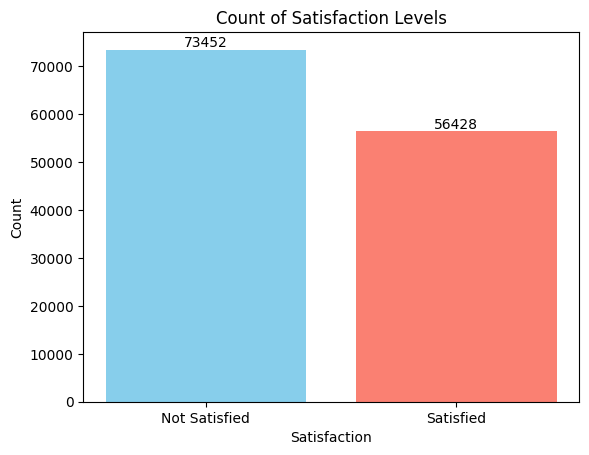

In [ ]:
import matplotlib.pyplot as plt

# Count the number of satisfied and not satisfied
satisfaction_counts = df['Satisfaction'].value_counts()

# Plotting the bar graph
plt.bar(satisfaction_counts.index, satisfaction_counts.values, color=['skyblue', 'salmon'])
plt.xticks([0, 1], ['Not Satisfied', 'Satisfied'])  # Adjust the labels as per our encoding
plt.xlabel('Satisfaction')
plt.ylabel('Count')
plt.title('Count of Satisfaction Levels')

# Adding counts on top of the bars
for index, value in enumerate(satisfaction_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()

<Axes: >

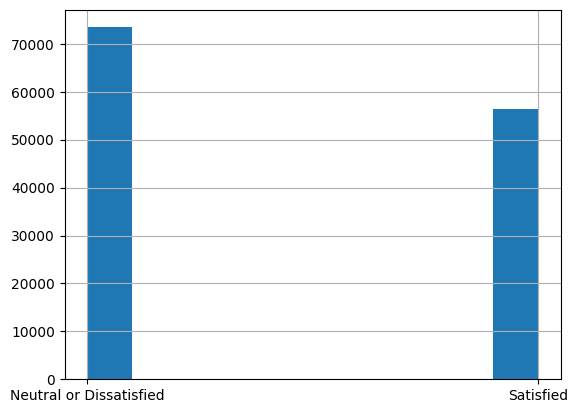

In [ ]:
#plot the histogram of satisfaction
df['Satisfaction'].hist()

We can see that there are fewer satisfied customers compared to those who are neutral or dissatisfied. This indicates that the overall satisfaction level leans more towards neutral or negative experiences.

Now, we are going to check the missing values.

In [ ]:
df.isnull().sum()

,0
ID,0
Gender,0
Age,0
Customer Type,0
Type of Travel,0
Class,0
Flight Distance,0
Departure Delay,0
Arrival Delay,393
Departure and Arrival Time Convenience,0


We can confirm that there are 393 missing values for Arrival Delay. Since the rows containing these missing values make up less than 1% of the total, we will drop these rows.

In [ ]:
df = df.dropna(subset=['Arrival Delay'])
#drop the ID column
df = df.drop('ID', axis=1)

In [ ]:
df.isnull().sum()

,0
Gender,0
Age,0
Customer Type,0
Type of Travel,0
Class,0
Flight Distance,0
Departure Delay,0
Arrival Delay,0
Departure and Arrival Time Convenience,0
Ease of Online Booking,0


Now, we can see that the rows containing missing values have been successfully dropped.

In [ ]:
# Get the describe statistics for numerical columns only
desc = df.describe()

# Calculate the mode for numerical columns
mode = df.mode().iloc[0]  # Get the first mode for each column

# Add the mode to the description DataFrame
desc.loc['mode'] = mode

# Display the result
desc

,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000
mean,39.428761,1190.210662,14.643385,15.091129,3.057349,2.756786,3.306239,3.252720,2.976909,3.383204,3.441589,3.351078,3.286222,3.204685,3.642373,2.728544,3.358067,3.631886
std,15.117597,997.560954,37.932867,38.465650,1.526787,1.401662,1.266146,1.350651,1.278506,1.287032,1.319168,1.316132,1.313624,1.329905,1.176614,1.329235,1.334149,1.180082
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,27.000000,414.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,40.000000,844.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,51.000000,1744.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,85.000000,4983.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mode,39.000000,337.000000,0.000000,0.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,2.000000,4.000000,4.000000


The average age of passengers is 39.43 years, with a range from 7 to 85, indicating a diverse traveler demographic. Additionally, passengers travel an average distance of 1190.21 kilometers, with a wide range from 31 to 4983 kilometers, suggesting that both short-haul and long-haul flights are represented. The mode of 337 kilometers highlights that many flights tend to be relatively short.

When examining delays, the average departure delay is 14.64 minutes, while the average arrival delay is slightly higher at 15.09 minutes. The maximum delays recorded are significant, reaching 1592 minutes for departures and 1584 minutes for arrivals. However, the mode for both types of delays is 0 minutes, indicating that a considerable number of flights were on time.

The overall ratings for convenience and services range from 2.73 to 3.64 on a 5-point scale. Notably, the ease of online booking scores low at 2.76, and the in-flight wifi service averages 2.73, reflecting areas that require improvement. The mode for online booking service is 3, suggesting that many passengers rated their experience as slightly better than average.

In terms of onboard services, ratings for aspects such as seat comfort and cleanliness range from 3.3 to 3.6, indicating moderate passenger satisfaction. However, specific areas like leg room service and food quality show potential for enhancement.

##Histograms

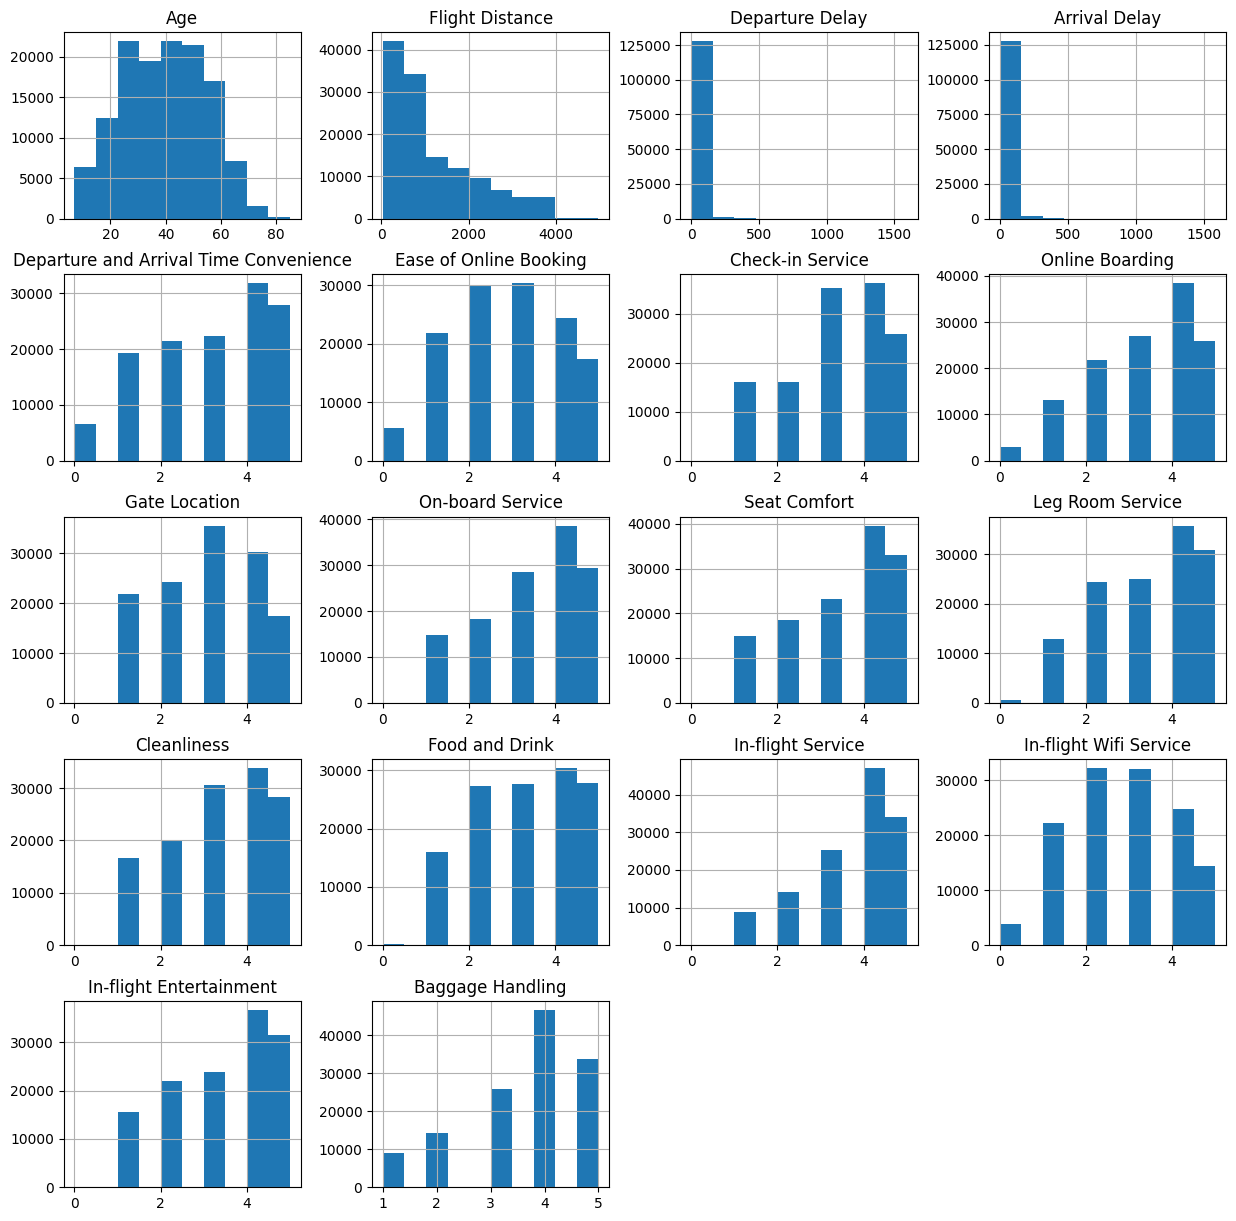

In [ ]:
df.hist(figsize=(15,15))
plt.show()

1. Age

Distribution: Bell-shaped

Context: This suggests that the majority of passengers are middle-aged, likely reflecting a demographic that travels frequently for both business and personal.
2. Flight Distance

Distribution: Right-skewed, with most passengers traveling shorter distances.

Context: Shorter flights are typically more common as they are more affordable and convenient for most travelers, possibly representing domestic travel within a country.
3. Departure Delay

Distribution: Right-skewed - Most flights leave with little to no delay, with a few significant delays.

Context: This reflects efficient airport operations and scheduling, where most flights depart close to their scheduled time.
4. Arrival Delay

Distribution: Right-skewed - Similar to departure delays, most flights arrive on time with occasional delays.

Context: This suggests effective flight operations and control, minimizing the impact of delays on passengers.

5. Departure and Arrival Time Convenience

Distribution: Left-skewed - Most ratings are high, indicating satisfaction with the timing of flights.

Context: Airlines likely schedule flights at times that are preferred by the majority, possibly optimized based on booking trends.

6. Ease of Online Booking

Distribution: Multimodal - Different peaks suggest varying experiences among passengers.

Context: This indicates that while many passengers find the online booking process user-friendly, there is room for improvement.

7. Check-in Service

Distribution: Slightly left-skewed - Generally good experiences with some variability.

Context: Efficient check-in processes contribute to passenger satisfaction, but experiences can vary by airport and staff.

8. Online Boarding
Distribution: Slightly left skewed - Indicates mixed experiences, likely depending on the digital tools' effectiveness.

Context: Online boarding convenience might depend on the digital savviness of passengers and the usability of the airline's app or website.

9. Gate Location

Distribution: Approximately Bell-Curved with a few outliers - Ratings are spread differently across the scale, suggesting varying satisfaction levels.

Context: Gate locations affecting passenger experience could be influenced by the size and layout of the airport.

10. On-board Service

Distribution: Left-skewed - Most passengers are satisfied with on-board service, with fewer lower ratings.

Context: Reflects the quality of service provided by flight attendants, crucial for passenger satisfaction.

11. Seat Comfort

Distribution: Slightly left skewed - Indicates distinct groups of satisfaction and dissatisfaction among passengers with more satisfied passengers in terms of seat comfort.

Context: Indicates variability in comfort, which can significantly affect passenger experience, especially on longer flights.

12. Leg Room Service

Distribution: Slightly left skewed - Reflects a divide in passenger satisfaction regarding leg room.

Context: Adequate legroom is a significant factor in comfort, especially for taller passengers or longer flights.

13. Cleanliness

Distribution: Left-skewed - High cleanliness ratings dominate, with some variability.

Context: High cleanliness standards are crucial for a good passenger experience and can impact repeat bookings.

14. Food and Drink

Distribution: Approximately Uniform - Spread of ratings suggests a varied perception of food and drink quality.

Context: Food and drink quality can vary widely and is crucial for overall satisfaction, especially on longer flights.

15. In-flight Service

Distribution: Left-skewed - Majority are satisfied, with fewer lower ratings.

Context: Good service options are important for long flights and can significantly enhance passenger experience.

16. Baggage Handling

Distribution: Slightly left skewed - Indicates varied experiences in how baggage is handled with more satisfied customers.

Context: Reflects how well an airline manages luggage, crucial for passenger trust and satisfaction.

17. In-flight Entertainment

Distribution: Left-skewed - Indicates high satisfaction with in-flight entertainments among most passengers.

Context: Encompasses aspects like responsiveness and courtesy of the crew, impacting overall satisfaction.

18. In-flight WiFi Service

Distribution: Normal - The digital experience varies among different groups of customers.

Context: Indicates varying quality of WiFi service aboard, a growing factor for passenger satisfaction as connectivity becomes increasingly important.





##Plot of Categories

<ipython-input-16-8b0c3d8f7ee0>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='pastel')


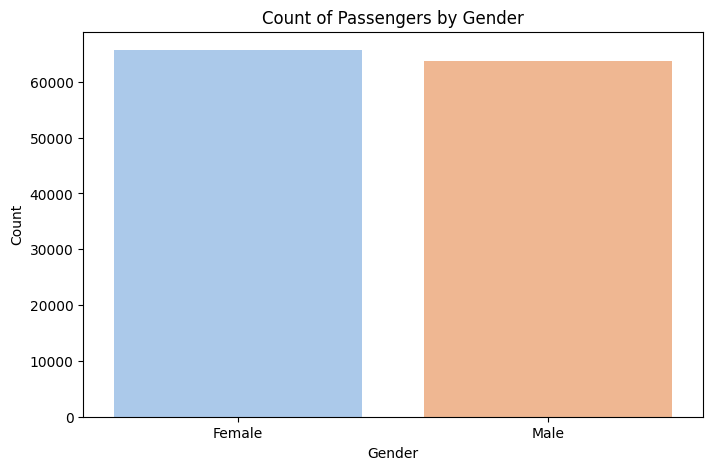

<ipython-input-16-8b0c3d8f7ee0>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Customer Type', palette='pastel')


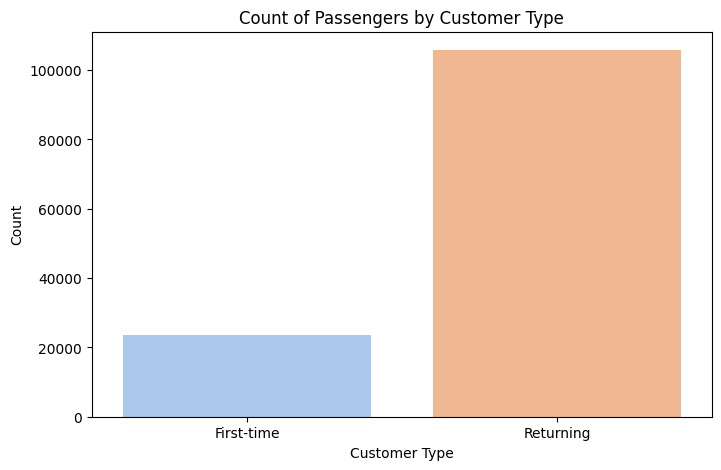

<ipython-input-16-8b0c3d8f7ee0>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Type of Travel', palette='pastel')


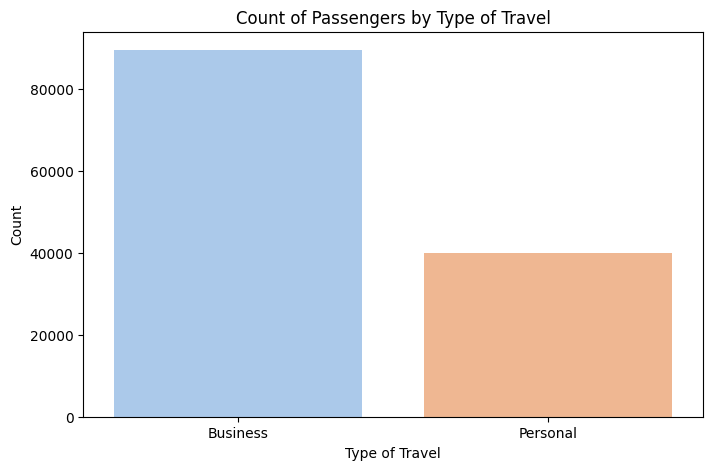

<ipython-input-16-8b0c3d8f7ee0>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette='pastel')


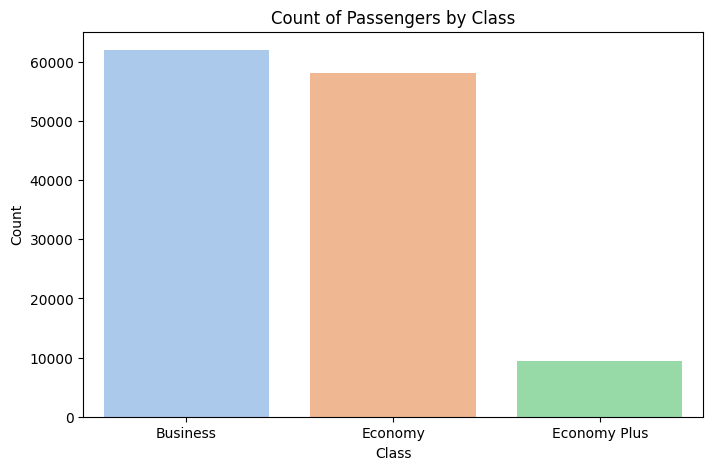

<ipython-input-16-8b0c3d8f7ee0>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Satisfaction', palette='pastel')


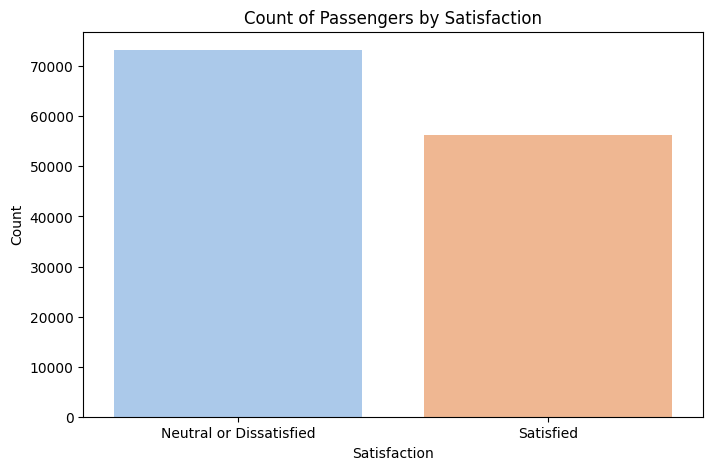

In [ ]:
# 1. Countplot for Gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Gender', palette='pastel')
plt.title('Count of Passengers by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# 2. Countplot for Customer Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Customer Type', palette='pastel')
plt.title('Count of Passengers by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.show()

# 3. Countplot for Type of Travel
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Type of Travel', palette='pastel')
plt.title('Count of Passengers by Type of Travel')
plt.xlabel('Type of Travel')
plt.ylabel('Count')
plt.show()

# 4. Countplot for Class
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Class', palette='pastel')
plt.title('Count of Passengers by Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# 5. Countplot for Satisfaction
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Satisfaction', palette='pastel')
plt.title('Count of Passengers by Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Count')
plt.show()

1. Gender

The gender breakdown shows that the number of female and male passengers is almost equal. This balance indicates that there is no significant variation in the gender distribution of air travel in our data set.
Understanding the gender distribution can help tailor marketing and service offerings to ensure they are inclusive and effectively meet the needs of all passengers.

2. Customer type

The statistics show that there are more returning customers than first-time flyers.
This indicates a high customer retention rate, which is crucial for the profitability of an airline. It may also indicate that the airline has successfully maintained customer loyalty through its services or loyalty programs.

3. Type of travel

Business travelers outnumber personal travelers by a wide margin.
This dominance of business travelers can influence flight schedules, in-flight amenities and the design of loyalty programs, which are often designed to attract more business customers.

4. Class

As can be seen in the graph, the number of business class passengers is the highest, followed closely by the number of economy class passengers. The number of economy class passengers is slightly lower.
The unusual distribution of the data set, with the highest number of business class passengers, indicates that our data set may be biased towards a specific type of traveler. This could be due to the fact that the data was collected on a route with the highest usage of business travelers, or collected through an airline that focuses on high-end services. This can affect service provision, as airlines may prioritize improvements and services in business class to meet the needs of their largest customer base.

5. Satisfaction level

As can be seen in the graph, the number of passengers who feel neutral or dissatisfied with the service exceeds the number of satisfied passengers. This indicates that a significant proportion of passengers are not completely satisfied with their travel experience.
This distribution is worrying, as it indicates that there is much room for improvement in the airline's service. High levels of dissatisfaction can affect customer loyalty and have a negative impact on the airline's reputation.


##Boxplot

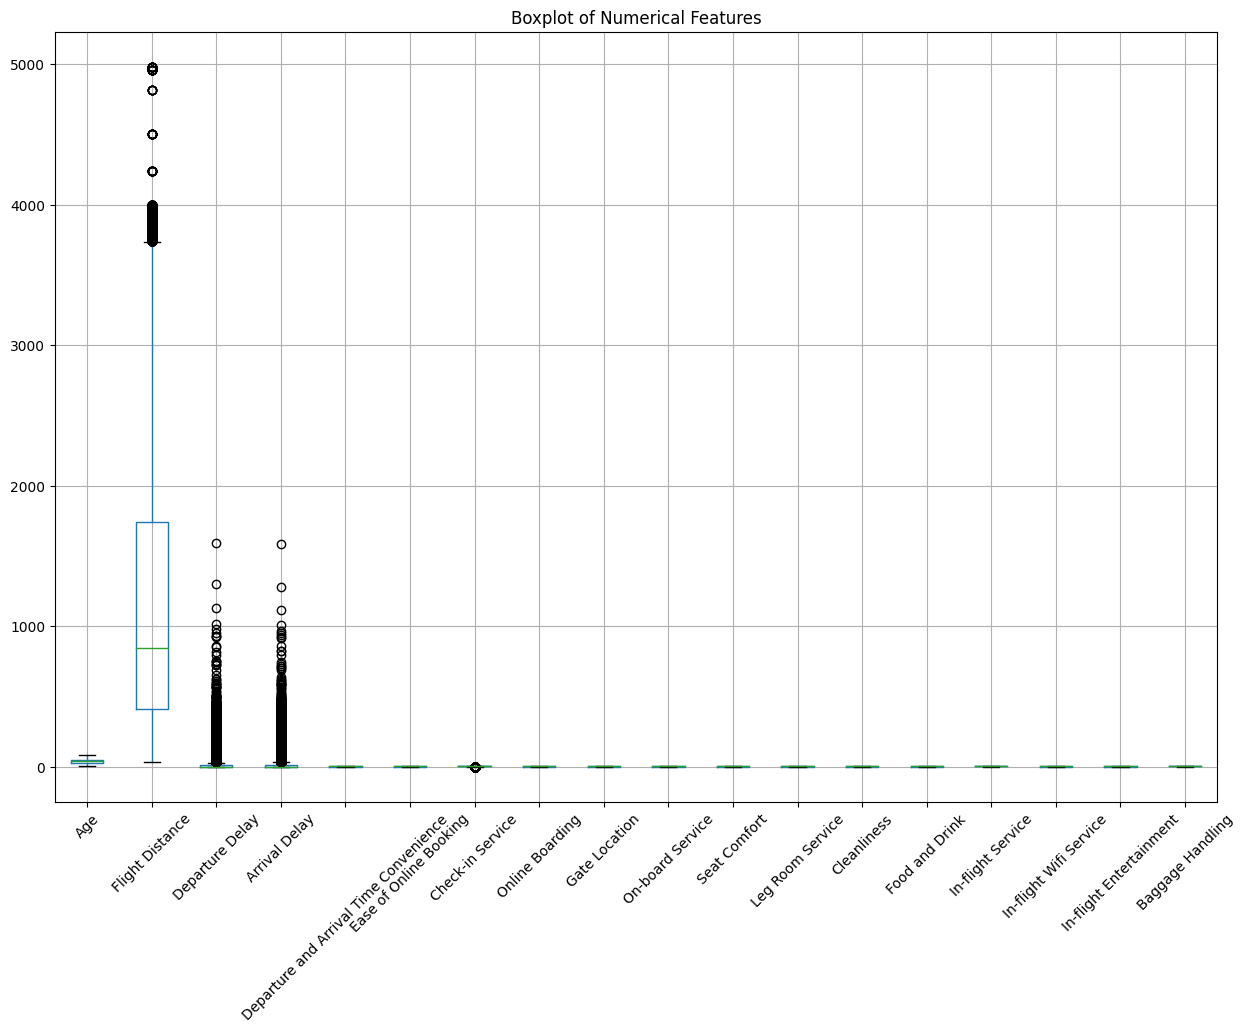

In [ ]:
df.boxplot(figsize=(15,10))
plt.xticks(rotation=45)
plt.title('Boxplot of Numerical Features')
plt.show()  # Show the boxplots

Age

- The distribution for age shows a narrow range with a fairly symmetrical spread, suggesting a diverse passenger base in terms of age.The interquartile range is tightly packed, indicating that most passengers fall within a central age range, likely encompassing working adults.

Flight Distance

- The distribution of flight distances shows a larger spread and a long tail of high values, indicating some long-haul flights but mostly shorter or medium-haul flights.

Departure Delay and Arrival Delay

- Both features show a concentration of data near zero with numerous outliers, suggesting that while most flights are on time, delays (both departure and arrival) can sometimes be significant.

Ease of Service Features (Online Booking, Check-in Service, Gate Location, etc.)

- These service-related features generally show few outliers and are tightly grouped, indicating consistent performance in these areas. High consistency in these service areas is good as they directly influence customer satisfaction.

Onboard Services (Onboard Service, Seat Comfort, Leg Room Service, Food and Drink, Cleanliness, In-flight Entertainment)

- The onboard service features generally show good consistency with few extreme outliers, indicating that passengers typically find these services acceptable to good.

Baggage Handling

- Baggage handling shows a tight distribution with very few outliers, suggesting high efficiency and few issues in this area.



#Bivariate Analysis

Let's first start by building a correlation matrix to evaluate any specific trends that might be interesting in our satisfaction prediction!

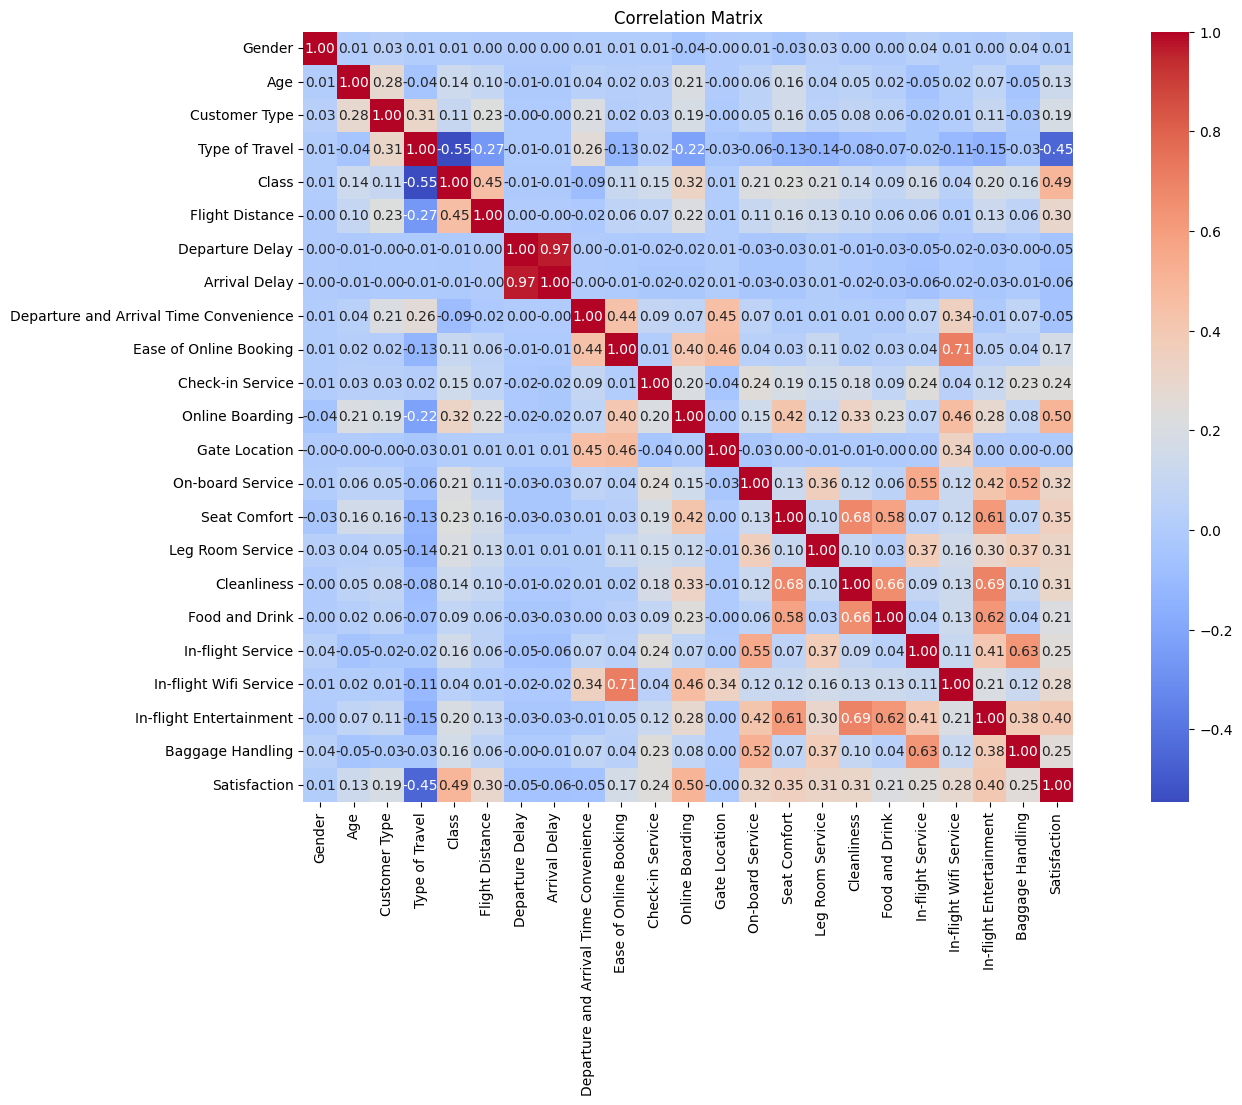

In [ ]:
# Encoding the categorical columns using the specified mappings

# Gender: Female (0), Male (1)
gender_mapping = {
    'Female': 0,
    'Male': 1
}
df['Gender'] = df['Gender'].map(gender_mapping)

# Customer Type: First-Time (0), Returning (1)
customer_type_mapping = {
    'First-time': 0,
    'Returning': 1
}
df['Customer Type'] = df['Customer Type'].map(customer_type_mapping)

# Type of Travel: Business (0), Personal (1)
type_of_travel_mapping = {
    'Business': 0,
    'Personal': 1
}
df['Type of Travel'] = df['Type of Travel'].map(type_of_travel_mapping)

# Class: Economy (0), Economy Plus (1), Business (2)
class_mapping = {
    'Economy': 0,
    'Economy Plus': 1,
    'Business': 2
}
df['Class'] = df['Class'].map(class_mapping)

# Satisfaction: Neutral (0), Dissatisfied (0), Satisfied (1)
satisfaction_mapping = {
    'Neutral or Dissatisfied': 0,
    'Satisfied': 1
}
df['Satisfaction'] = df['Satisfaction'].map(satisfaction_mapping)

# Calculate the correlation matrix for numerical and encoded categorical columns
correlation_matrix = df.corr()

# Plot the correlation matrix
plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

When analyzing features that influence passenger satisfaction, it's essential to consider how real-life factors align with the correlations observed in the data. These correlations not only reflect statistical relationships but also give insight into how passengers perceive their travel experience.

For instance, the correlation between Class and Satisfaction (0.49) makes sense in real-life terms. Passengers flying in business or first class often experience better services—such as more comfortable seating, better food, and personalized attention—leading to higher levels of satisfaction compared to economy class, where amenities are more basic. Thus, the higher the class of service, the more likely a passenger is to report being satisfied.

Similarly, the correlation between Online Boarding and Satisfaction (0.50) is another real-world reflection of convenience. Online boarding offers travelers the ease of checking in from home, selecting seats, and avoiding long check-in lines. This convenience is highly valued by passengers, and thus, higher usage or positive experiences with online boarding tend to correlate with higher satisfaction levels.

When we see a strong correlation like Seat Comfort and Cleanliness (68%), it reflects the common-sense relationship between a clean environment and passenger comfort. Passengers are likely to feel more comfortable in a clean seat, as hygiene directly impacts their overall comfort. This underscores how basic cleanliness can significantly improve perceived comfort and, subsequently, satisfaction.

When we see the negative correlation of 45% between Type of Travel and Satisfaction, it means that as we move from one type of travel (likely business or personal/economy) to another, satisfaction tends to decrease. This suggests that passengers traveling for one purpose may generally report lower satisfaction compared to those traveling for another purpose.

For example, business travelers might experience more stress or dissatisfaction due to time constraints, tight schedules, and higher service expectations. Business travel often comes with added pressure, such as meeting deadlines or attending meetings immediately after landing, which can reduce overall satisfaction. On the other hand, economy travelers typically have a more relaxed attitude, with fewer time constraints and lower expectations, resulting in higher satisfaction levels with similar services. This highlights the fact that travel purpose plays a significant role in how passengers perceive and rate their experience.

The strong correlation (0.71) between online booking ease and in-flight wifi services suggests these digital touchpoints might be managed by similar systems or reflect the airline's overall digital infrastructure quality.

In essence, the correlations reflect how various service attributes—like class of service, ease of boarding, cleanliness, and comfort—are interwoven with passenger satisfaction. These features are critical touchpoints in the overall travel experience, and improvements in any of these areas are likely to enhance a passenger's sense of satisfaction, making them key metrics for predicting customer satisfaction in the travel industry.

###Scatterplots

Now, let's visualize some of these findings!!

Correlation between Type of Travel and Satisfaction: -0.45


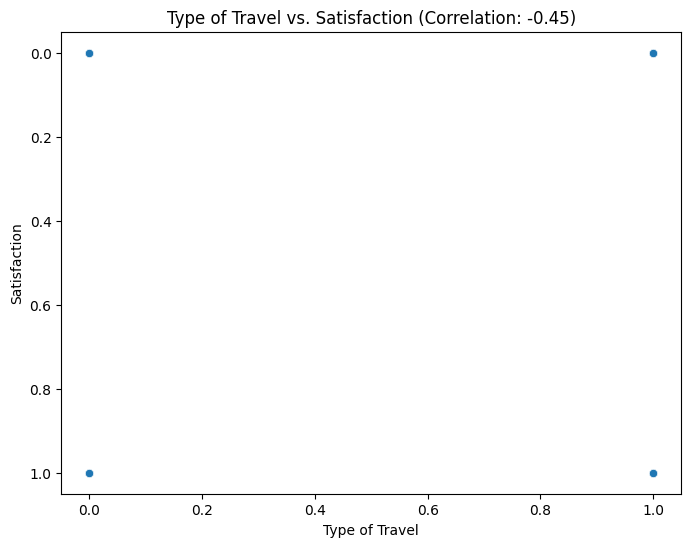

Correlation between Class and Satisfaction: 0.49


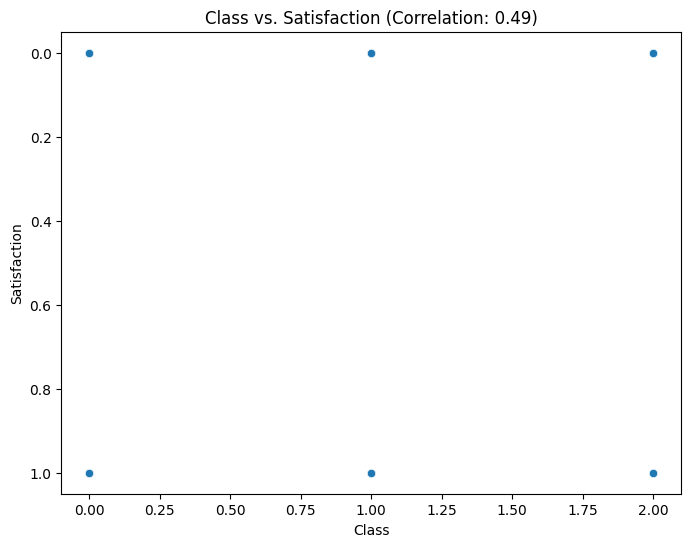

Correlation between Online Boarding and Satisfaction: 0.50


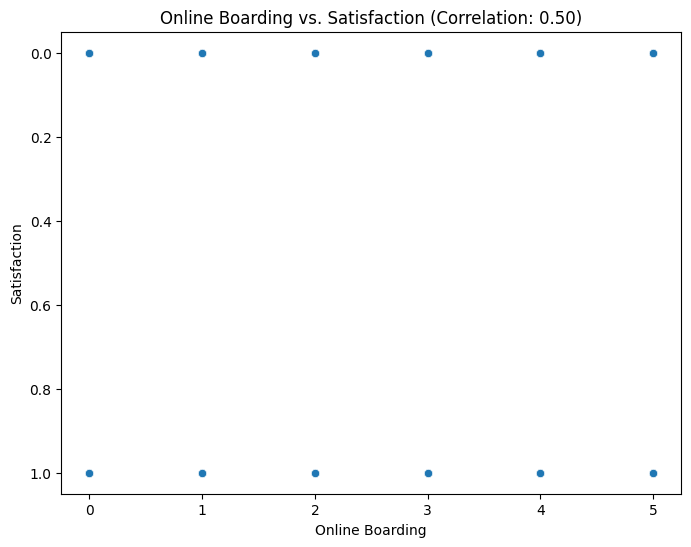

Correlation between Type of Travel and Class: -0.55


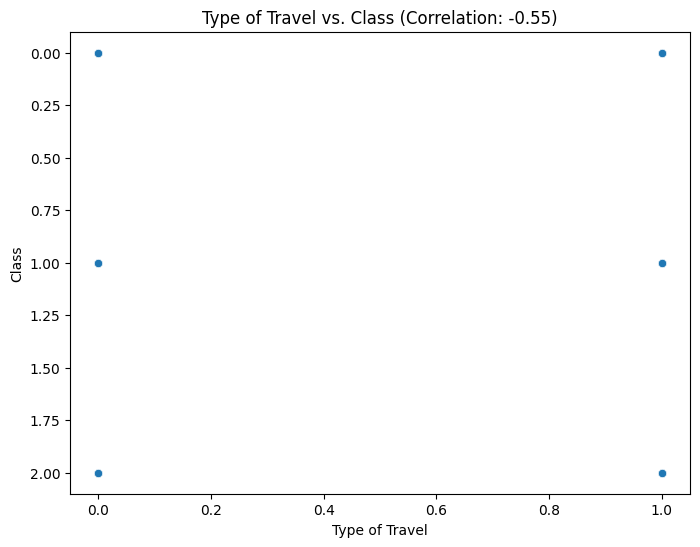

Correlation between Seat Comfort and Cleanliness: 0.68


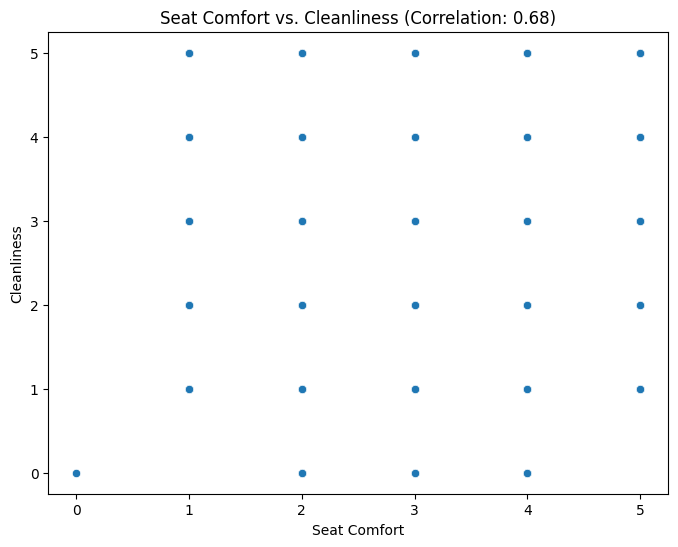

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame

# Function to create a scatterplot and print the correlation
def create_scatterplot(x_col, y_col, df):
    correlation = df[x_col].corr(df[y_col])
    print(f"Correlation between {x_col} and {y_col}: {correlation:.2f}")

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=x_col, y=y_col, data=df)
    plt.title(f'{x_col} vs. {y_col} (Correlation: {correlation:.2f})')
    plt.show()

# Scatterplot: Type of Travel vs. Satisfaction
create_scatterplot('Type of Travel', 'Satisfaction', df)

# Scatterplot: Class vs. Satisfaction
create_scatterplot('Class', 'Satisfaction', df)

# Scatterplot: Online Boarding vs. Satisfaction
create_scatterplot('Online Boarding', 'Satisfaction', df)

# Scatterplot: Type of Travel vs. Class
create_scatterplot('Type of Travel', 'Class', df)

# Scatterplot: Seat Comfort vs. Cleanliness
create_scatterplot('Seat Comfort', 'Cleanliness', df)

The scatterplots we plotted above involving categorical or ordinal variables, such as "Type of Travel" and "Class," provide limited insights due to the restricted range of values (typically 0 to 5) used to represent satisfaction and other features.

These plots tend to display points clustered in a few distinct categories, making it challenging to observe any meaningful trends or correlations. Since scatter plots are most effective for continuous numerical data that can demonstrate gradual variation, we cannot really see clearly the linear trends identified in our correlation matrix analysis.

We will build a few multivariate plots to cater to this issue!

#Multivariate analysis

Let's first set a few hypothesis from our initial correlation matrix.

##Hypothesis

Hypothesis 1: When passengers travel in higher class (Business), experience good seat comfort, they are significantly more likely to report high satisfaction levels.

Hypothesis 2: Passengers who experience high cleanliness standards, efficient online boarding, find satisfaction as these factors represent consistent service quality across different aspects of the journey.

Hypothesis 3: Passengers who experience high ease of online booking and good in-flight WiFi service are likely to report high satisfaction, as this represents a seamless digital journey from pre-flight to in-flight experience.

##Visualization of the Hypothesis

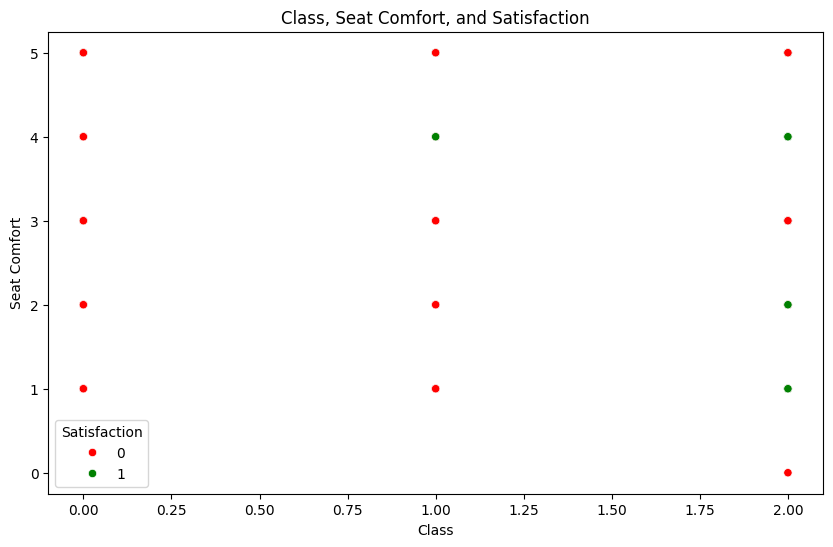

In [ ]:
# Class and seat comfort and class colored by satisfaction

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Class', y='Seat Comfort', hue='Satisfaction', data=df, palette=['red', 'green'])
plt.title('Class, Seat Comfort, and Satisfaction')
plt.xlabel('Class')
plt.ylabel('Seat Comfort')
plt.show()

Our first hypothesis entitled : "When passengers travel in higher class (Business), experience good seat comfort, they are significantly more likely to report high satisfaction levels" appears to be somewhat true. As mentioned earlier, our non-continuous values do not really help much in evaluating our visualizations. However, we are able to notice that the overall satisfaction is greater (green dots) with Class 2 Passengers (Business Passengers).

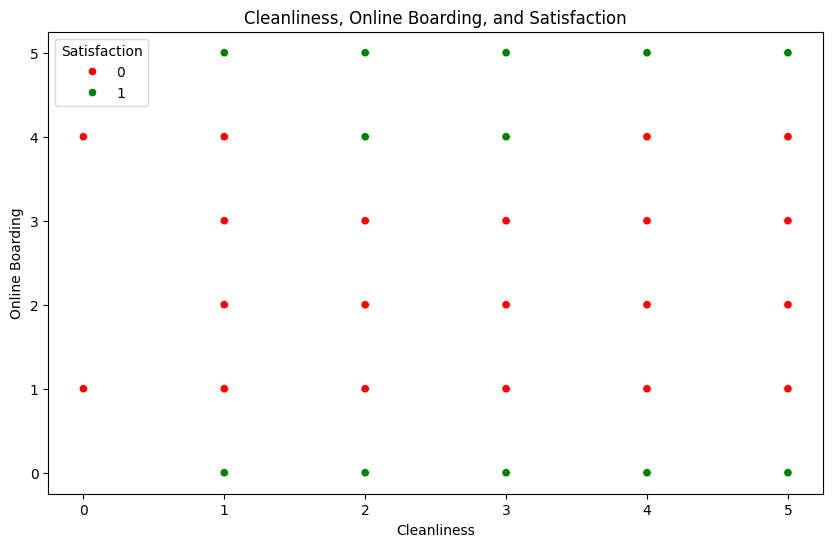

In [ ]:
# Cleanliness and Online Boarding colored by Satisfaction
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Cleanliness', y='Online Boarding', hue='Satisfaction', data=df, palette=['red', 'green'])
plt.title('Cleanliness, Online Boarding, and Satisfaction')
plt.xlabel('Cleanliness')
plt.ylabel('Online Boarding')
plt.show()

Our second hypothesis entitled : "Passengers who experience high cleanliness standards, efficient online boarding, find satisfaction as these factors represent consistent service quality across different aspects of the journey". In this case, our hypothesis appears to be some what true. We, however, have scattered satisfaction ratings. we can note that cleanliness is not highly correlated to online boarding. Nevertheless, high cleanliness and high online boarding might be associated and lead to general satisfaction!

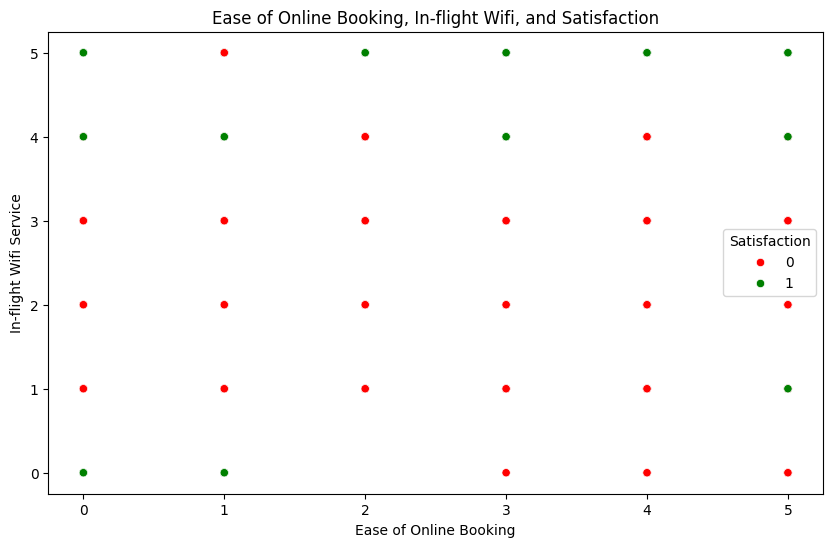

In [ ]:
#Ease of Online Booking and In-flight Wifi service colored by Satisfaction
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Ease of Online Booking', y='In-flight Wifi Service', hue='Satisfaction', data=df, palette=['red', 'green'])
plt.title('Ease of Online Booking, In-flight Wifi, and Satisfaction')
plt.xlabel('Ease of Online Booking')
plt.ylabel('In-flight Wifi Service')
plt.show()

Our third hypothesis entitled : "Passengers who experience high ease of online booking AND good in-flight WiFi service are likely to report high satisfaction, as this represents a seamless digital journey from pre-flight to in-flight experience". This hypothesis appears to be some what true. We note that the higher the ease to online booking utilization, leads to high overall satisfaction when high In-flight wifi service is considered!

#Baseline models

##Logistic Regression

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.86
Precision: 0.84
Recall: 0.85
F1 Score: 0.84


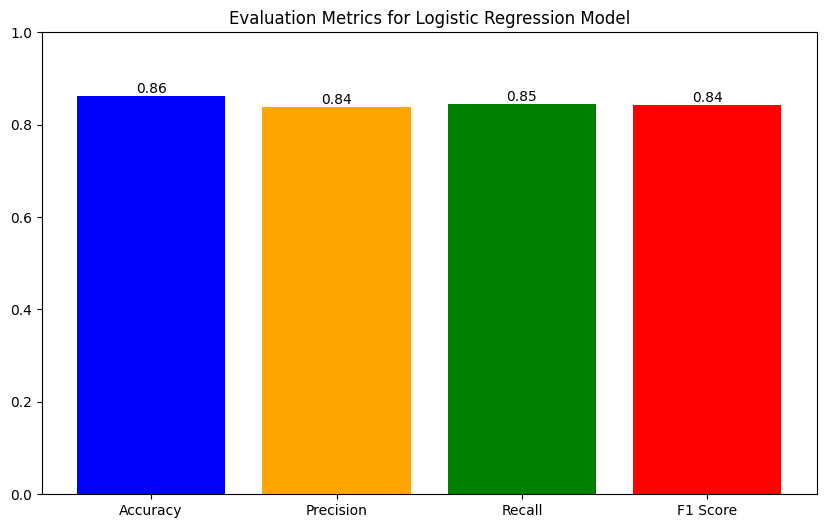

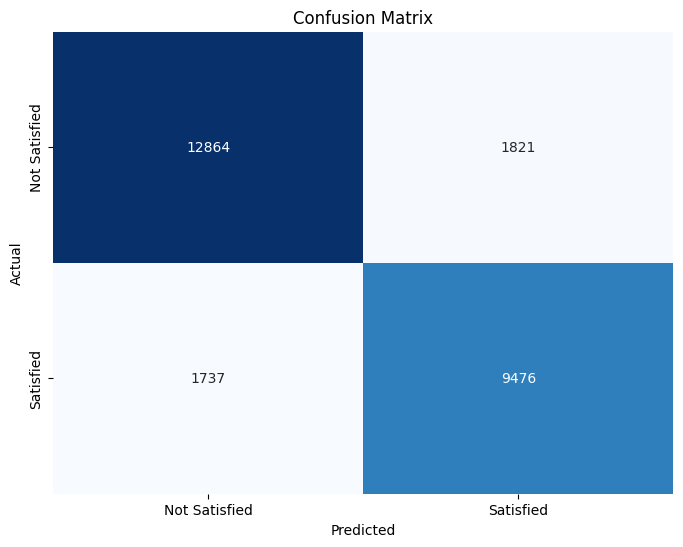

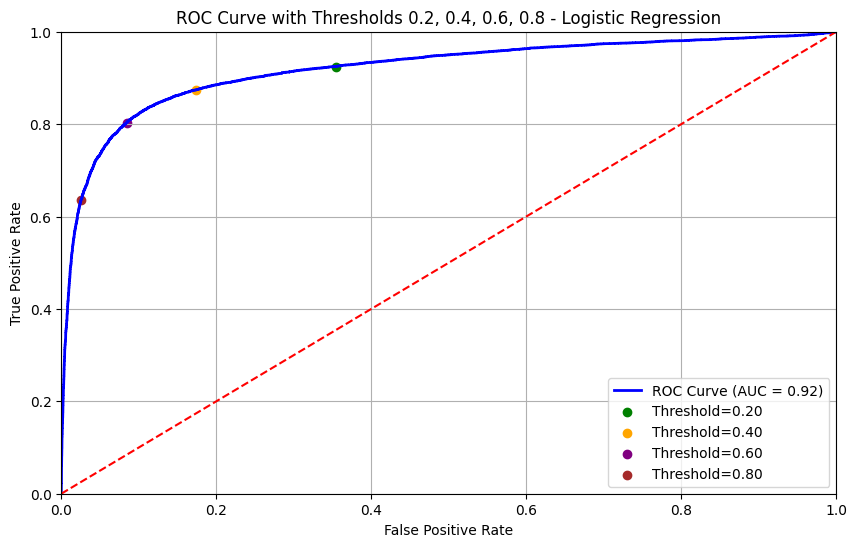

Threshold=0.20, FPR=0.35, TPR=0.92
Threshold=0.40, FPR=0.17, TPR=0.87
Threshold=0.60, FPR=0.08, TPR=0.80
Threshold=0.80, FPR=0.03, TPR=0.63


In [ ]:
# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the logistic regression model
logistic_model = LogisticRegression(max_iter=1000)  # Increase max_iter for convergence
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.title('Evaluation Metrics for Logistic Regression Model')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Logistic Regression')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Accuracy: 0.86

- The model correctly predicts passenger satisfaction 86% of the time. This is a strong overall accuracy rate, indicating a good fit for the dataset.

Precision: 0.84
- Of the passengers predicted as satisfied, 84% actually were, suggesting that the model is quite reliable in its positive predictions.

Recall: 0.85
- The model successfully identifies 85% of all actually satisfied passengers, indicating a strong ability to detect positive instances.

F1 Score: 0.84
- The F1 score, which balances precision and recall, is also at 0.84, confirming that the model is robust in terms of both precision and recall.

Confusion Matrix:
- True Negative (TN) = 12,864: Passengers correctly identified as not satisfied.
- False Positive (FP) = 1,821: Passengers incorrectly predicted as satisfied.
- False Negative (FN) = 1,737: Satisfied passengers incorrectly predicted as not satisfied.
- True Positive (TP) = 9,476: Passengers correctly identified as satisfied.

ROC Curve and AUC:
- AUC: 0.92
- The AUC value of 0.92 is very good and indicates a high separability between satisfied and dissatisfied passengers.


ROC Curve Threshold Analysis:

At Threshold = 0.20:
- FPR (False Positive Rate): 0.35 - Higher risk of falsely predicting satisfaction.
- TPR (True Positive Rate) or Recall: 0.92 - Catches most of the satisfied passengers.

At Threshold = 0.40:
- FPR: 0.17
- TPR: 0.87 - Still high but reduces false positives.
At Threshold = 0.60:

- FPR: 0.08
- TPR: 0.80 - Balances false positives against not missing too many true positives.

At Threshold = 0.80:
- FPR: 0.03
- TPR: 0.63 - Conservative, minimizing false positives but missing more true positives.

##Decision Tree classifier

Accuracy: 0.95
Precision: 0.93
Recall: 0.94
F1 Score: 0.94


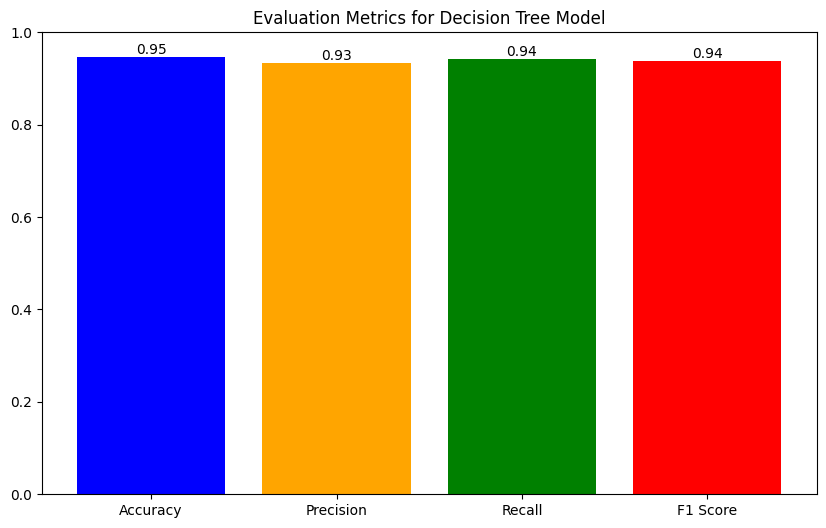

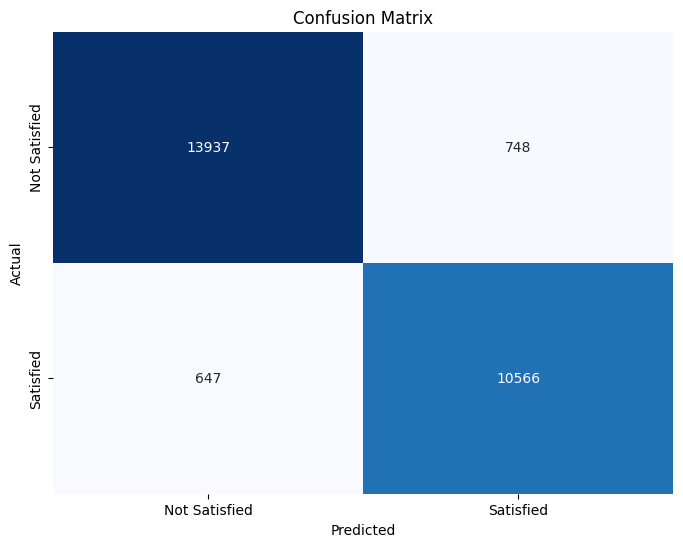

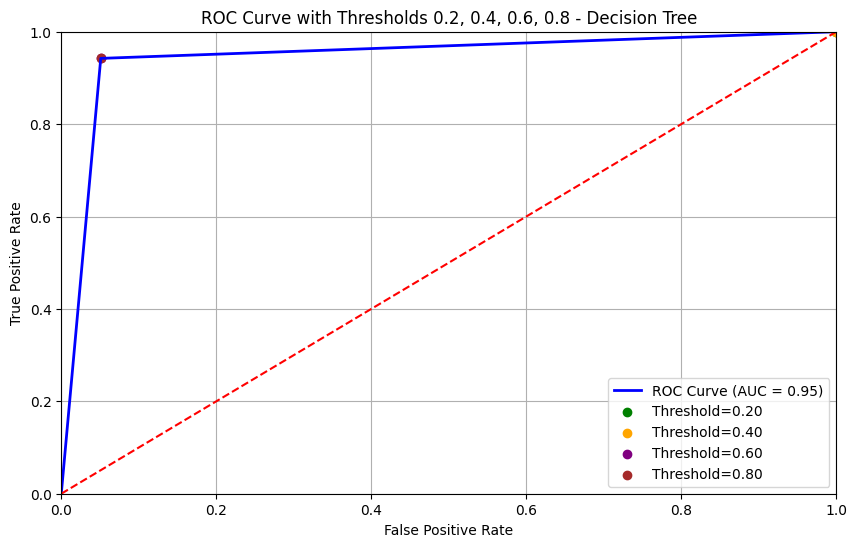

Threshold=0.20, FPR=1.00, TPR=1.00
Threshold=0.40, FPR=1.00, TPR=1.00
Threshold=0.60, FPR=0.05, TPR=0.94
Threshold=0.80, FPR=0.05, TPR=0.94


In [ ]:
# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.title('Evaluation Metrics for Decision Tree Model')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tree)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Decision Tree')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Accuracy: 0.95

- This is a very high accuracy rate, indicating that the Decision Tree model is effective in classifying the majority of cases correctly.

Precision: 0.93

- The precision score is also quite high. This suggests that when the Decision Tree predicts a class, it is correct about 93% of the time.

Recall: 0.94

- The recall of 0.94 indicates that the model successfully identifies 94% of all relevant cases. The number of satisfied customers predicted as satisfied in this case.

F1 Score: 0.94

- The F1 score, which balances precision and recall, is also high at 0.94, indicating a balanced and robust performance between the precision and recall, which is ideal in most practical scenarios.


Confusion Matrix Analysis:
- True Negatives (TN) = 13,937: Passengers who were not satisfied and were correctly identified as such.
- False Positives (FP) = 748: Passengers who were not satisfied but incorrectly predicted as satisfied.
- False Negatives (FN) = 647: Satisfied passengers that were incorrectly predicted as not satisfied.
- True Positives (TP) = 10,566: Satisfied passengers correctly predicted as such.


ROC Curve and AUC:
- AUC (Area Under Curve) = 0.95: This is a very good score, which shows that the decision tree model has a high degree of discrimination and can distinguish between satisfied and dissatisfied passengers.

Threshold Analysis on the ROC Curve:

Threshold 0.20:

- FPR (False Positive Rate) = 1.00, TPR (True Positive Rate) = 1.00: This setting captures all satisfied customers but also incorrectly labels all unsatisfied customers as satisfied, rendering the classifier ineffective—similar to predicting all outcomes as the majority class.

Threshold 0.40:
- FPR = 1.00, TPR = 1.00: Similar to a threshold of 0.20, this setting does not provide any discriminative ability.

Threshold 0.60:
- FPR = 0.05, TPR = 0.94: A significant improvement, this threshold setting sharply reduces false positives while maintaining a high true positive rate. It's a practical setting if reducing the burden of false positives is important.

Threshold 0.80:
- FPR = 0.05, TPR = 0.94: Maintains the gains achieved at 0.60, continuing to balance minimizing false positives while capturing most of the actual positives.


##Random Forest Classifier

Accuracy: 0.96
Precision: 0.97
Recall: 0.94
F1 Score: 0.96


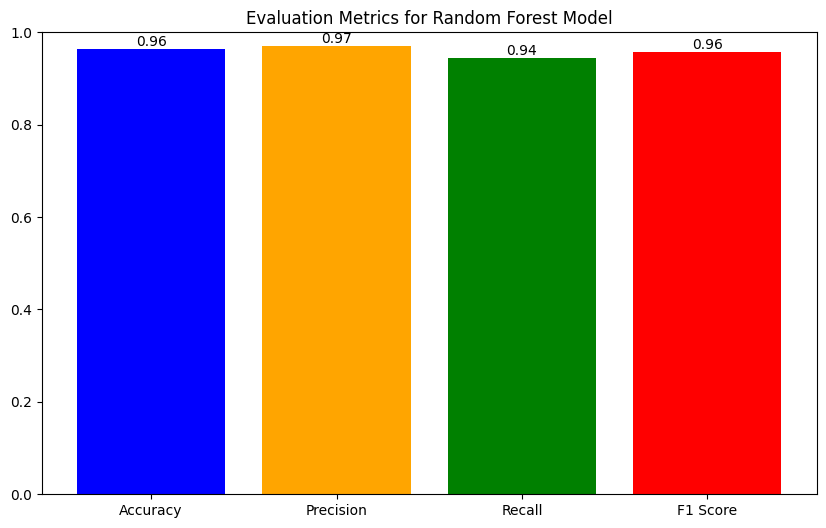

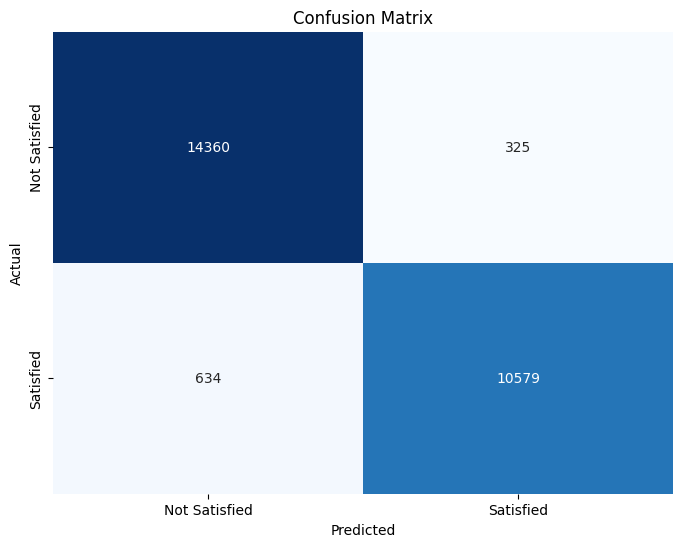

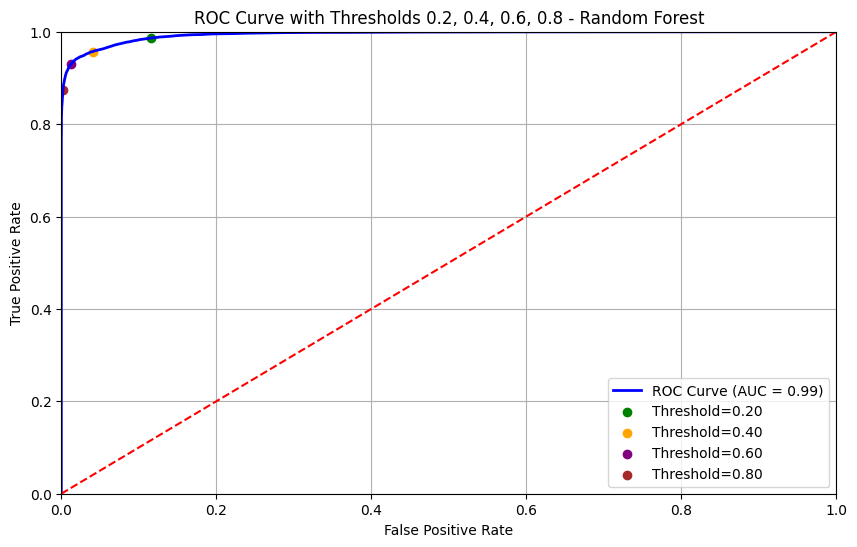

Threshold=0.20, FPR=0.12, TPR=0.99
Threshold=0.40, FPR=0.04, TPR=0.96
Threshold=0.60, FPR=0.01, TPR=0.93
Threshold=0.80, FPR=0.00, TPR=0.87


In [ ]:
# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Random Forest model
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred = random_forest_model.predict(X_test)
y_prob_forest = random_forest_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.title('Evaluation Metrics for Random Forest Model')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_forest)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Random Forest')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Our random forest appears to be one of our best baseline models.
With very strong metric results (96% accuracy and F1 score, 97% precision, and 94% recall), our model is very robust and portrays strong predictive power.

Moreover, its false positives (number of dissatisfied passengers predicted as satisfied) is very low compared to our other models. This situation shows itself to be good in understanding and anticipating what might passengers dislike.

It is also important to note the commendable area under the curve of 99%. This shows us how well our model does predicting true positves and false positives.

A suggested threshold is 0.6 where we are minizing false positives and maximizing true positives.

Overall from what we've seen, our random forest is our best model in terms of accuracy and number of false positives!

##Gradient Boosting Classifier

In [ ]:
df.dtypes

,0
Gender,category
Age,int64
Customer Type,category
Type of Travel,category
Class,category
Flight Distance,int64
Departure Delay,int64
Arrival Delay,float64
Departure and Arrival Time Convenience,int64
Ease of Online Booking,int64


Accuracy: 0.94
Precision: 0.94
Recall: 0.92
F1 Score: 0.93


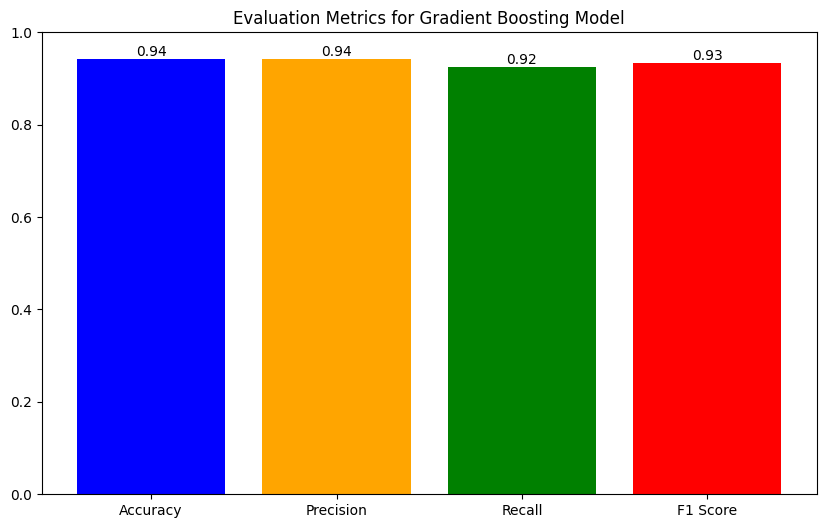

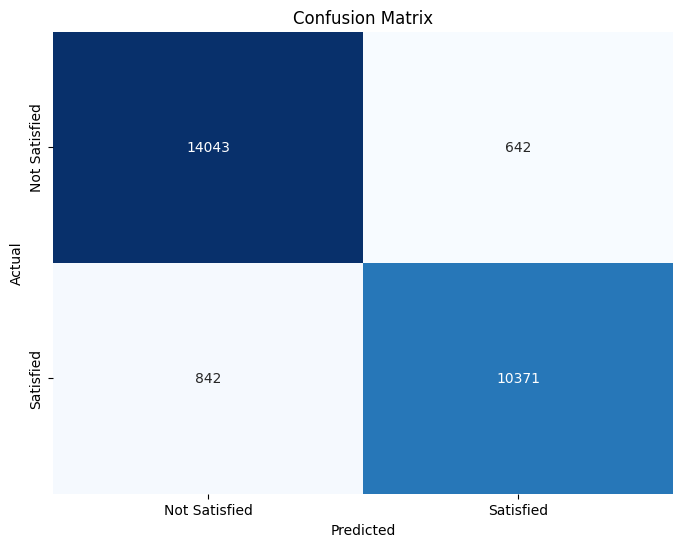

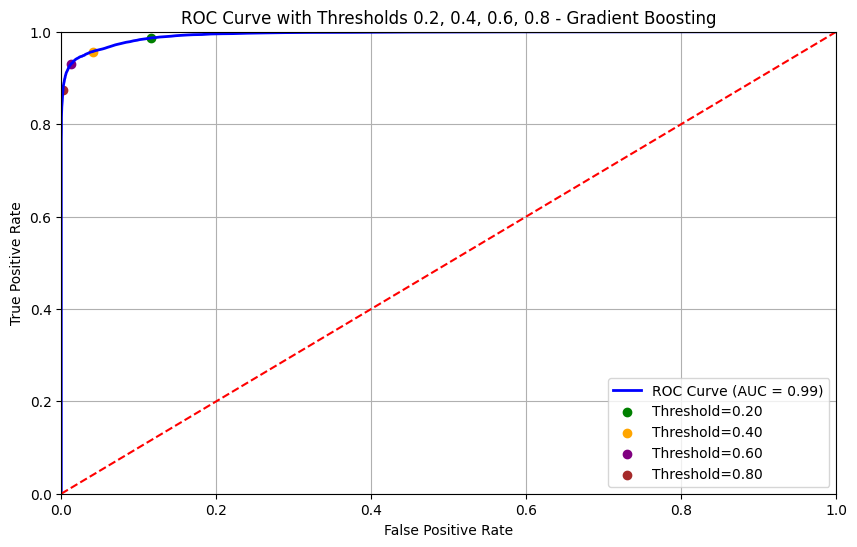

Threshold=0.20, FPR=0.12, TPR=0.99
Threshold=0.40, FPR=0.04, TPR=0.96
Threshold=0.60, FPR=0.01, TPR=0.93
Threshold=0.80, FPR=0.00, TPR=0.87


In [ ]:
# Replace 'target_column' with your actual target column name
X = df.drop('Satisfaction', axis=1)
y = df['Satisfaction']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Gradient Boosting Classifier
gbc = GradientBoostingClassifier()

# Fit the model to the training data
gbc.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gbc.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.title('Evaluation Metrics for Gradient Boosting Model')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_forest)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Gradient Boosting')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Accuracy: 0.94
- The model has a high success rate, being able to accurately predict passenger satisfaction in 94% of cases, indicating excellent overall performance.

Precision: 0.94
- Of all the predictions regarding passenger satisfaction, the actual satisfaction was 94%. The high accuracy indicates that the model is very effective in reducing false positives, which is important for targeted interventions based on model predictions.

Recall: 0.92
- The model identified 92% of the actual satisfied passengers, showing a high recall rate. This indicator is crucial to ensuring that the most satisfied customers are correctly identified, and helps to effectively maintain customer satisfaction and loyalty programs.

F1 Score: 0.93
- The F1 score is close to 0.93, indicating that the model has achieved a good balance between accuracy and recall, which is very suitable for ensuring the reliability of maintaining positive predictions and the coverage of actual positive examples.


Confusion Matrix Analysis:
- True Negatives (TN) = 14,043: Passengers correctly identified as not satisfied.
- False Positives (FP) = 642: Passengers who were not satisfied but incorrectly predicted as satisfied.
- False Negatives (FN) = 842: Satisfied passengers that were incorrectly predicted as not satisfied.
- True Positives (TP) = 10,371: Satisfied passengers correctly predicted as such.

This confusion matrix reflects the model's high efficiency in correctly distinguishing between satisfied and dissatisfied passengers, with a relatively balanced number of false positives and false negatives.


ROC Curve and AUC:
- AUC (Area Under Curve) = 0.99: This value is very high, indicating that the gradient boosting model is excellent at distinguishing between satisfied and dissatisfied passengers. The AUC is close to 1.0, indicating that the model can correctly rank predictions with a high degree of confidence.

ROC Curve Threshold Analysis:

Threshold 0.20:
- FPR = 0.12, TPR = 0.99: Opting for maximum sensitivity, capturing nearly all true positives but at a cost of a higher false positive rate.

Threshold 0.40:
- FPR = 0.04, TPR = 0.96: Significantly reduces false positives while maintaining a high true positive rate, offering a balanced approach.

Threshold 0.60:
- FPR = 0.01, TPR = 0.93: Further reduction in false positives, suitable for scenarios where false alarms are more costly.

Threshold 0.80:
- FPR = 0.00, TPR = 0.87: Minimizes false positives to nearly zero, prioritizing precision over recall.

##K-Nearest Neighbors

In [ ]:
df.shape

(129487, 23)

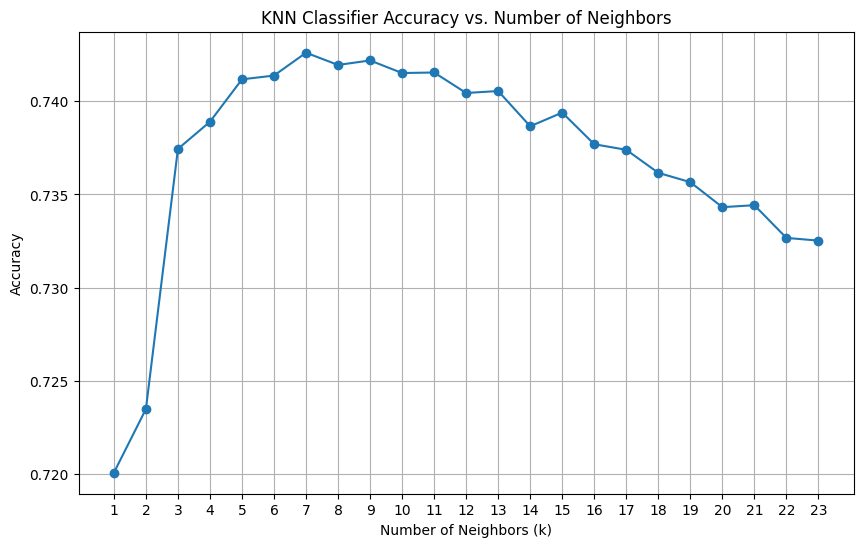

The best number of neighbors (k) is: 7


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

# Assuming your DataFrame is named df and the target variable is 'Satisfaction'
X = df.drop('Satisfaction', axis=1)
y = df['Satisfaction']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define function to process k values in batches
def batch_k_processing(X_train, y_train, k_values_batch, batch_size=5):
    accuracies_batch = []
    for k in k_values_batch:
        knn = KNeighborsClassifier(n_neighbors=k)
        # Perform cross-validation using n_jobs=-1 to use all available cores
        cv_scores = cross_val_score(knn, X_train, y_train, cv=3, n_jobs=-1)
        accuracies_batch.append(cv_scores.mean())  # Store accuracy for this k
    return accuracies_batch

# Range of k values to test
k_values = range(1, 24)  # Testing k from 1 to 23
accuracies = []
batch_size = 5  # Number of k values to process in one batch

# Split k values into smaller batches
k_batches = np.array_split(list(k_values), len(k_values) // batch_size)

# Loop through each batch of k values
for k_values_batch in k_batches:
    accuracies += batch_k_processing(X_train, y_train, k_values_batch)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('KNN Classifier Accuracy vs. Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid()
plt.show()

# Find the best k
best_k = k_values[accuracies.index(max(accuracies))]
print(f'The best number of neighbors (k) is: {best_k}')

The highest accuracy is achieved when k=7. This is the optimal balance between overfitting and underfitting. At this point, the model is general enough to correctly classify new samples based on the majority vote of neighboring points.

When k>7, the accuracy gradually decreases as k is further increased. The reason for the decrease may be that the model begins to consider too broad a neighborhood, which contains points that are less similar to the query point, thus introducing bias into the prediction.

The lower the value of k, the more sensitive the model is to noise in the training data. The higher the value of k, the less sensitive to noise it is, but it may make the model too simple, resulting in insufficient fitting.

For this dataset, selecting k=7 seems to effectively balance model complexity and generalization ability.


Accuracy: 0.76
Precision: 0.75
Recall: 0.68
F1 Score: 0.71


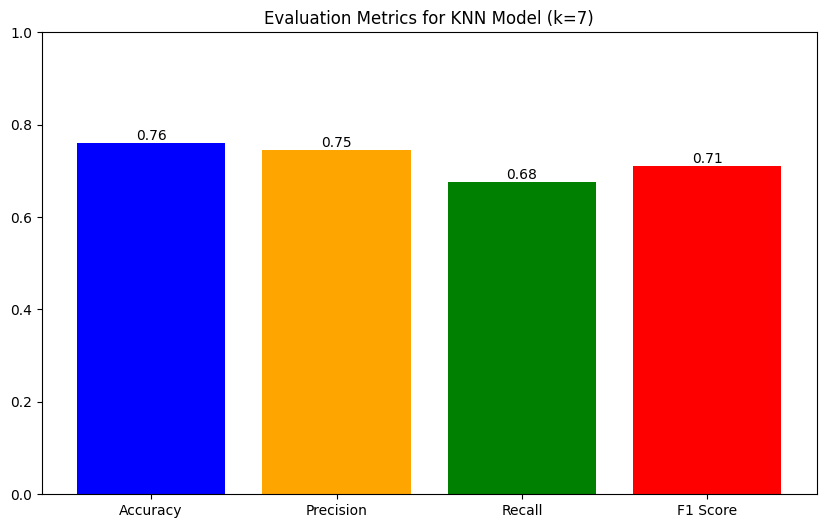

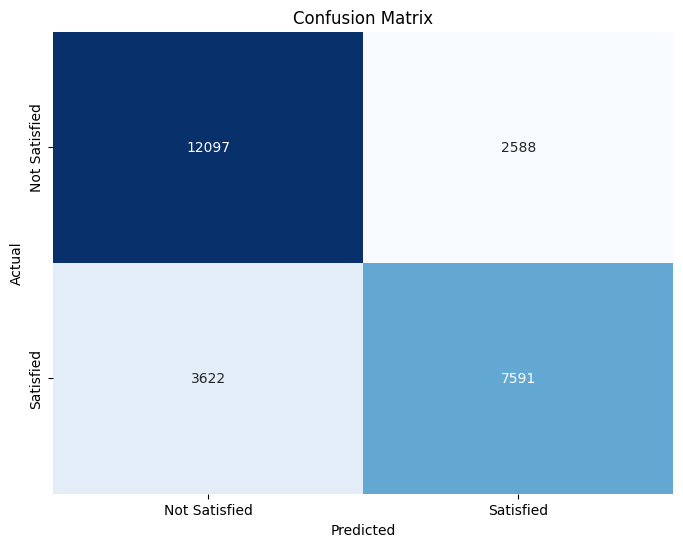

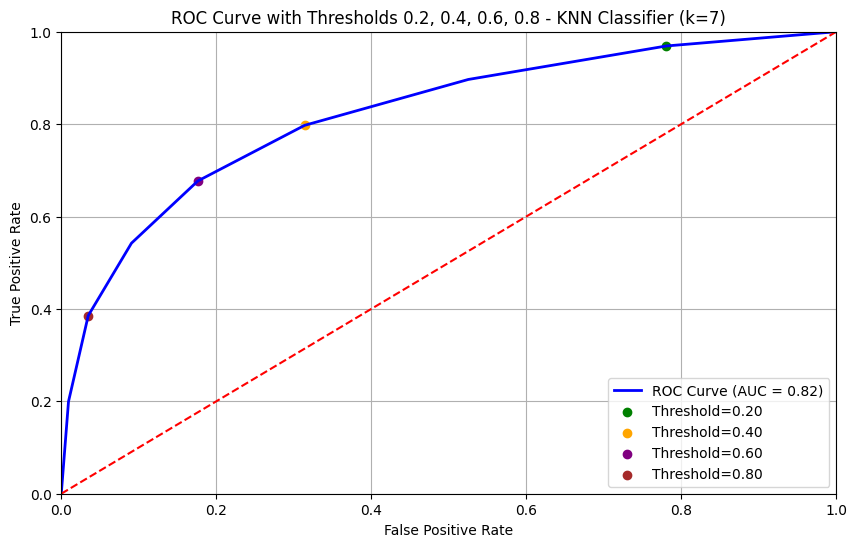

Threshold=0.20, FPR=0.78, TPR=0.97
Threshold=0.40, FPR=0.31, TPR=0.80
Threshold=0.60, FPR=0.18, TPR=0.68
Threshold=0.80, FPR=0.03, TPR=0.39


In [ ]:
# Replace 'target_column' with your actual target column name
X = df.drop('Satisfaction', axis=1)
y = df['Satisfaction']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the KNN Classifier with k=7
knn = KNeighborsClassifier(n_neighbors=7)

# Fit the model to the training data
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.title('Evaluation Metrics for KNN Model (k=7)')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC curve and AUC
y_prob_knn = knn.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - KNN Classifier (k=7)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")


- Accuracy: 0.76
- Precision: 0.75
- Recall: 0.68
- F1 Score: 0.71

These indicators show that the model performs adequately but not outstandingly. The accuracy is adequate, indicating that the model correctly predicts 76% of the instances. The precision is also quite good, indicating that when the model predicts passenger satisfaction, the correct rate is about 75%. However, the recall rate is slightly lower, indicating that the model identifies 68% of the actual satisfied cases. The F1 score (balancing accuracy and recall) is 0.71, indicating that the accuracy and recall are at a medium level.


Confusion Matrix:

- The matrix shows that this model correctly predicted 12,097 instances as “Not Satisfied'” and 7,591 instances as “Satisfied”.
- However, the number of false positives and false negatives is also considerable, with 2,588 instances incorrectly predicted as “Satisfied” and 3,622 instances not identified as “Satisfied”.


ROC Curve:

- The ROC curve for k=7 shows an AUC (Area Under Curve) of 0.82, which is good and suggests the model has a good measure of separability between the classes.

- The curve and associated thresholds demonstrate how varying the threshold affects the trade-off between the True Positive Rate (TPR) and False Positive Rate (FPR):
1. Threshold = 0.20: High sensitivity (TPR=0.97) but very high FPR (0.78).
2. Threshold = 0.40: Balance of sensitivity and FPR (TPR=0.80, FPR=0.31).
3. Threshold = 0.60: Decreased sensitivity and FPR (TPR=0.68, FPR=0.18).
4. Threshold = 0.80: Much lower sensitivity (TPR=0.39) with minimal FPR (0.03).

This shows that although the model performs well enough on multiple metrics, the choice of k and threshold can significantly affect its performance, especially in terms of balancing the number of false positives and false negatives. Choosing k=7 seems to be a compromise that can optimize the overall accuracy and F1 score, but specific adjustments may be needed based on the cost of false positives and false negatives in real-world applications. In this case, our airline company.


##Support Vector Classifier

As the code, took considerable time to run, Professional Professor Anusha advised us to drop this model.

##Naive Bayes

Accuracy: 0.8616
Precision: 0.8614
Recall: 0.8616
F1 Score: 0.8612


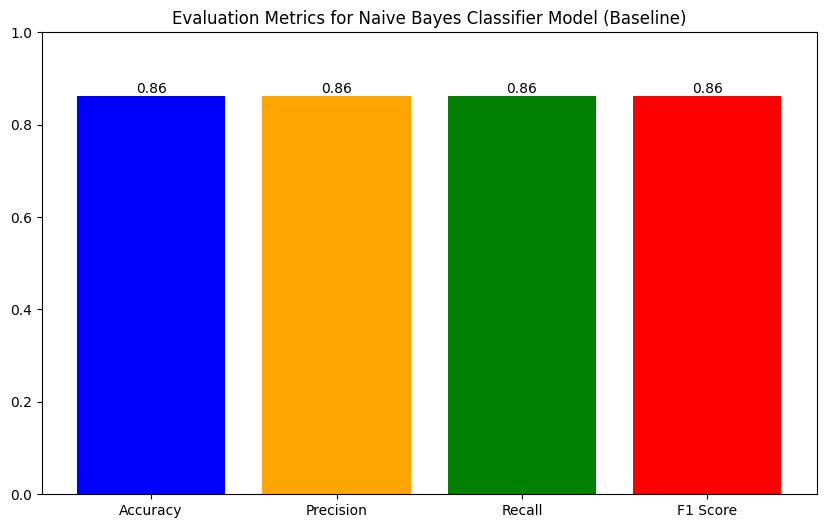

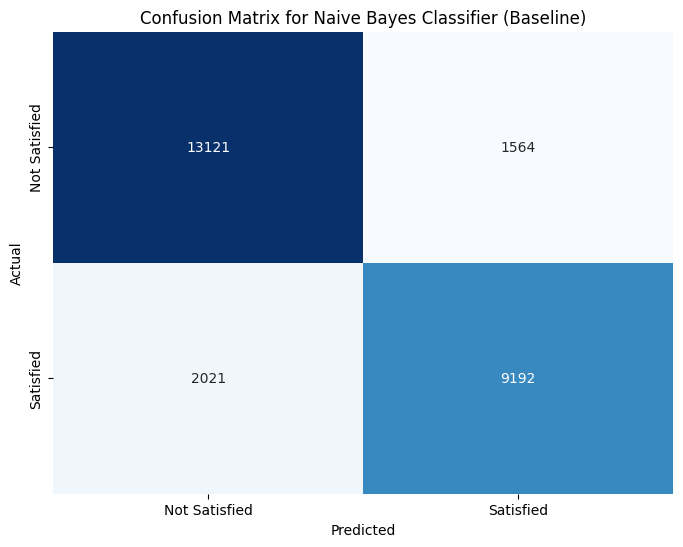

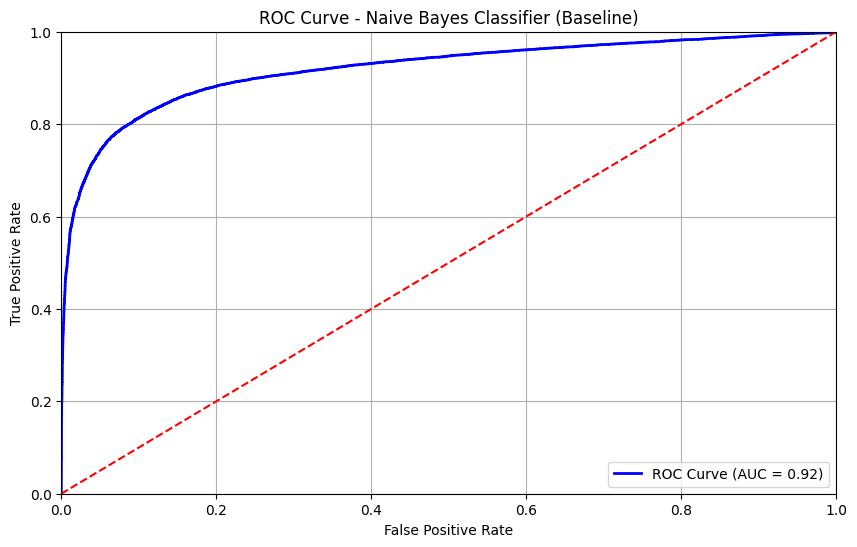

In [ ]:
# Features and target variable
X = df.drop(columns=['Satisfaction'])  # Use all features except the target
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Naive Bayes model
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train, y_train)

# Make predictions
y_pred = naive_bayes_model.predict(X_test)
y_prob_nb = naive_bayes_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}", ha='center', va='bottom')

plt.title('Evaluation Metrics for Naive Bayes Classifier Model (Baseline)')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive Bayes Classifier (Baseline)')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes Classifier (Baseline)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

Performance Metrics
- Accuracy: 0.8616

The model correctly predicted the outcome for 86.16% of the cases.

- Precision: 0.8614

Out of all predicted satisfied cases, 86.14% were actually satisfied.

- Recall: 0.8616

The model correctly identified 86.16% of all actual satisfied cases.

- F1 Score: 0.8612

The F1 score, a balance between precision and recall, is also high at 86.12%.


Confusion Matrix Analysis
- True Negatives (Not Satisfied, Predicted Not Satisfied): 13,121
- False Positives (Not Satisfied, Predicted Satisfied): 1,564
- False Negatives (Satisfied, Predicted Not Satisfied): 2,021
- True Positives (Satisfied, Predicted Satisfied): 9,192

This model performed relatively well in terms of accuracy and recall. However, it did have a large number of false positives and false negatives, which indicates that there is still room for improvement in the sensitivity and specificity of the model.



ROC Curve Analysis

- Area Under the Curve (AUC): 0.92

The AUC value is very high, indicating that the distinguishability between the grades is very high. This shows that although there are some classification errors in the confusion matrix, the model generally performs well in distinguishing between satisfied and dissatisfied customers.


##Comparison of Baseline models

Here’s how each model performed in practical terms:

Random Forest:

Real-world implication: This model is the top performer, correctly identifying satisfied and unsatisfied customers 96% of the time. This means it's highly reliable for tailoring customer service strategies and directing resources where they are most needed without excessive misdirection.

K-Nearest Neighbors (KNN):

Real-world implication: This model shows the lowest accuracy (76%). It struggles to consistently identify customer satisfaction correctly, leading to potential missed opportunities in customer engagement and service enhancement.

Recall Analysis:

Random Forest and Decision Tree: Both excel in recognizing nearly all cases where customers are satisfied (94% recall rate). This is crucial in maintaining a high customer retention rate as almost all satisfied customers are correctly identified and not mistakenly targeted for dissatisfaction remedies.

KNN: It misses a significant portion of satisfied customers (only 68% recall), which could lead to dissatisfaction if their needs are not addressed thinking they are already satisfied.

Precision Analysis:

Random Forest and Gradient Boosting: These models are precise in their predictions (97% and 94% precision respectively), meaning when they predict customer satisfaction, they are usually right. This reduces the risk of incorrectly allocating resources to customers who are already satisfied.

KNN: Lower precision (74%) indicates a higher rate of false positives, suggesting that it might waste resources on customers who do not actually require attention.

F1 Score:

Random Forest: Best balance between precision and recall (F1 score of 0.96), making it ideal for ensuring that customer engagement efforts are neither excessive nor insufficient.

KNN: Lower F1 score (0.71) indicates it is not as balanced or effective in its predictive performance, which could lead to inefficient use of customer service resources.

ROC AUC Analysis:

Random Forest: Shows the highest capability to distinguish between satisfied and unsatisfied customers across all possible threshold levels (AUC of 0.99). This model is the most robust in varying scenarios, adaptable to different levels of risk tolerance in customer satisfaction strategies.

KNN: With the lowest AUC (0.82), it shows limited flexibility in adapting to different thresholds for classification, which could hinder performance in more complex or nuanced customer satisfaction scenarios.

Conclusion:

For a company focused on maximizing customer satisfaction and efficiently allocating resources towards improving customer experiences, the Random Forest model emerges as the most effective tool. It offers a high degree of reliability in its predictions, ensuring that efforts to enhance customer satisfaction are well-directed and likely to yield positive results. The KNN model, while useful in some respects, falls short in comparison and may not be ideal unless combined with other approaches or specific, limited applications.

#Feature Selection and Models

After building our baseline models, we found out that our best model in terms of accuracy, precision, recall, and F1-score was our random forest. This model outperformed all other models with slightly higher results.

This suggests that the random forest model was able to capture complex patterns in the data more effectively than other models, likely due to its ability to reduce overfitting while handling non-linear relationships. Its use of multiple decision trees and aggregation (bagging) likely contributed to its superior performance across accuracy, precision, recall, and F1-score, as it can balance bias and variance better than simpler models.

Although our results performed excellently well, we will perform several feature selection and engineering methods to attempt improving our models.

Join us in this adventure!



#Kbest

KBest is a feature selection method used to select the top k features based on a scoring function. It ranks all the features in the dataset according to their relevance to the target variable and then selects the k best features that contribute most to the prediction.

In this section, we will first:

- Select the best k.
- Build different categorical models based on the best K.
- Compare the different models.
- Improve the best model by changing hyperparameters.

###Selecting the best K


For k=1, Accuracy: 0.6634
Selected Features: ['Flight Distance']

For k=2, Accuracy: 0.6656
Selected Features: ['Flight Distance', 'Arrival Delay']

For k=3, Accuracy: 0.6656
Selected Features: ['Flight Distance', 'Departure Delay', 'Arrival Delay']

For k=4, Accuracy: 0.7481
Selected Features: ['Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay']

For k=5, Accuracy: 0.7864
Selected Features: ['Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Online Boarding']

For k=6, Accuracy: 0.8142
Selected Features: ['Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Online Boarding']

For k=7, Accuracy: 0.8144
Selected Features: ['Age', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Online Boarding']

For k=8, Accuracy: 0.8379
Selected Features: ['Age', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Online Boarding', 'In-flight Entertainment']

For k=9, Accuracy: 0.8

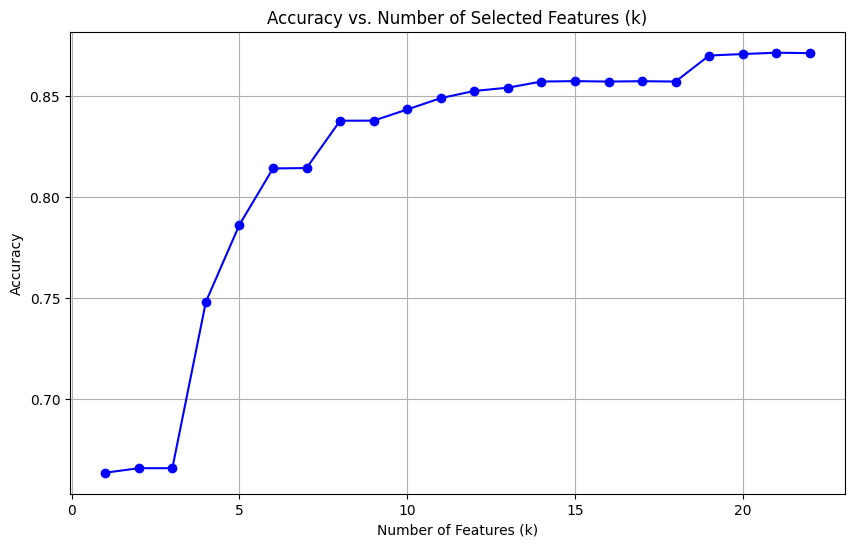

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, chi2

# Replace 'target_column' with your actual target column name
X = df.drop('Satisfaction', axis=1)
y = df['Satisfaction']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize lists to store accuracies, selected features, and k values
accuracies = []
selected_features_list = []
k_values = []

# Total number of features
n_features = X_train.shape[1]

# Iterate over different values of k (1 to total number of features)
for k in range(1, n_features + 1):
    # Apply SelectKBest with chi-squared test
    selector = SelectKBest(chi2, k=k)
    X_train_kbest = selector.fit_transform(X_train, y_train)
    X_test_kbest = selector.transform(X_test)

    # Initialize the logistic regression model
    logistic_model = LogisticRegression(max_iter=5000, random_state=42)

    # Train the model on the selected features
    logistic_model.fit(X_train_kbest, y_train)

    # Make predictions on the test set
    y_pred = logistic_model.predict(X_test_kbest)

    # Evaluate the model's accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    k_values.append(k)

    # Get the mask of selected features and store their names
    selected_features = X.columns[selector.get_support()]
    selected_features_list.append(selected_features)

    # Print the accuracy and selected features for this k
    print(f"\nFor k={k}, Accuracy: {accuracy:.4f}")
    print(f"Selected Features: {list(selected_features)}")

# Plotting the accuracy for each k
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.title('Accuracy vs. Number of Selected Features (k)')
plt.xlabel('Number of Features (k)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, chi2

# Replace 'target_column' with your actual target column name
X = df.drop('Satisfaction', axis=1)
y = df['Satisfaction']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize lists to store accuracies and selected features
accuracies = []
selected_features_list = []

# Total number of features
n_features = X_train.shape[1]

# Iterate over different values of k (1 to total number of features)
for k in range(1, n_features + 1):
    # Apply SelectKBest with chi-squared test
    selector = SelectKBest(chi2, k=k)
    X_train_kbest = selector.fit_transform(X_train, y_train)
    X_test_kbest = selector.transform(X_test)

    # Initialize the logistic regression model
    logistic_model = LogisticRegression(max_iter=5000, random_state=42)

    # Train the model on the selected features
    logistic_model.fit(X_train_kbest, y_train)

    # Make predictions on the test set
    y_pred = logistic_model.predict(X_test_kbest)

    # Evaluate the model's accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    # Get the mask of selected features and store their names
    selected_features = X.columns[selector.get_support()]
    selected_features_list.append(selected_features)

    # Print the accuracy and selected features for this k
    print(f"\nFor k={k}, Accuracy: {accuracy:.4f}")
    print(f"Selected Features: {list(selected_features)}")


For k=1, Accuracy: 0.6634
Selected Features: ['Flight Distance']

For k=2, Accuracy: 0.6656
Selected Features: ['Flight Distance', 'Arrival Delay']

For k=3, Accuracy: 0.6656
Selected Features: ['Flight Distance', 'Departure Delay', 'Arrival Delay']

For k=4, Accuracy: 0.7481
Selected Features: ['Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay']

For k=5, Accuracy: 0.7864
Selected Features: ['Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Online Boarding']

For k=6, Accuracy: 0.8142
Selected Features: ['Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Online Boarding']

For k=7, Accuracy: 0.8144
Selected Features: ['Age', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Online Boarding']

For k=8, Accuracy: 0.8379
Selected Features: ['Age', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Online Boarding', 'In-flight Entertainment']

For k=9, Accuracy: 0.8

After running our KBest, we discovered that with 19 of our best features, we acquire a logistic regression accuracy of 87%.

This means that utilizing 19 of our best features will yield to an overall accuracy of 87%.

From the logistic regression baseline, we see a 1% increase in accuracy (86% to 87%) leading us to conclude that our logistic regression model slightly improved.

Now, let's evaluate our different models based on the best features and begin our in-depth analysis!





###Building Models based on Best K (19)

Before starting our analysis, let's answer this following question:

Why such features have been chosen to predict satisfaction?

1. Age:
Different age groups may have varying preferences and expectations. Older passengers might value comfort and in-flight services more, while younger passengers might prioritize digital services like online booking or Wi-Fi. Age can influence how passengers perceive their experience.
2. Customer Type:
Dividing passengers by type (e.g., frequent flyers, one-time customers) helps capture differences in expectations. Frequent flyers are likely more familiar with services and may expect higher standards, while one-time passengers might have a different benchmark for satisfaction.
3. Type of Travel:
Whether a passenger is traveling business or personal, it can heavily influence their satisfaction. Business travelers might focus on punctuality, convenience, and productivity, whereas personal travelers may prioritize comfort and entertainment.
4. Class:
The class (e.g., economy, business) directly impacts the level of service passengers receive. Higher classes offer better legroom, seat comfort, and services, which generally lead to higher satisfaction levels. Therefore, the class of service is a significant predictor of overall satisfaction.
5. Flight Distance:
Longer flights may create higher expectations for comfort, food, and in-flight services. On short flights, passengers may tolerate lower service levels, but on longer flights, elements like seat comfort and entertainment become more critical.
6. Departure delays can set a negative tone for the entire travel experience. When a flight is delayed at the beginning of the journey, passengers may feel frustrated, anxious, or inconvenienced, especially if they have connecting flights or time-sensitive commitments. A longer delay can significantly impact their overall satisfaction as it disrupts their plans and may cause stress or dissatisfaction even before the flight starts.
7. Arrival delays, on the other hand, affect passengers at the end of their journey. After a long flight, passengers are usually eager to reach their destination, and a delayed arrival can lead to missed connections, wasted time, or frustration from waiting. For passengers with tight schedules or those arriving for important events, an arrival delay can significantly reduce their satisfaction as it may impact their post-flight activities.
8. Ease of Online Booking:
The process of booking a flight is often the first interaction a customer has with an airline. If this process is smooth and user-friendly, it can contribute positively to satisfaction, as it sets the tone for the rest of the experience.
9. Check-in Service:
A smooth check-in process is essential for reducing stress and improving the overall travel experience. Long wait times or inefficient service during check-in can negatively affect satisfaction before the flight even begins.
10. Online Boarding:
Many passengers now prioritize convenience and the ability to handle aspects of their journey digitally. Features like mobile boarding passes and online check-ins simplify the process, which enhances customer satisfaction.
11. On-board Service:
The service passengers receive during the flight (e.g., from flight attendants) directly impacts their satisfaction. Friendly, attentive, and helpful staff can make a big difference in how enjoyable the flight is.
12. Seat Comfort:
Especially on long-haul flights, comfort is a critical factor for satisfaction. Uncomfortable seating can make long flights unpleasant, which will likely result in lower satisfaction ratings.
13. Leg Room Service:
Similar to seat comfort, the amount of legroom can directly impact comfort, especially for taller passengers or those on longer flights. More legroom generally leads to higher satisfaction.
14. Cleanliness:
Cleanliness of the seat and cabin is essential for passengers' well-being and comfort. A clean environment leads to a more pleasant experience, while an unclean cabin can be a major source of dissatisfaction.
15. Food and Drink:
The availability and quality of food and drink services, especially on longer flights, can greatly impact satisfaction. Poor quality or limited options can result in negative reviews, while high-quality food and drink services often lead to higher ratings.
16. In-flight Service:
This captures the overall service experience during the flight, including attention from the crew and responsiveness to passengers' needs. Good in-flight service enhances the travel experience, contributing to higher satisfaction.
17. In-flight Wi-Fi Service:
With many passengers expecting to stay connected while flying, in-flight Wi-Fi is a key factor. The availability and quality of this service can greatly influence satisfaction, particularly for business travelers or those who wish to remain productive.
18. In-flight Entertainment:
Entertainment options are critical for keeping passengers occupied, especially on long-haul flights. A well-curated selection of movies, shows, and games can significantly enhance the travel experience.
19. Baggage Handling:
The efficiency and care with which baggage is handled (e.g., timely delivery, no damage) are important factors for satisfaction. Poor baggage handling can create a negative lasting impression even after a positive in-flight experience.

##Logistic Regression

Accuracy: 0.8702
Precision: 0.8700
Recall: 0.8702
F1 Score: 0.8699


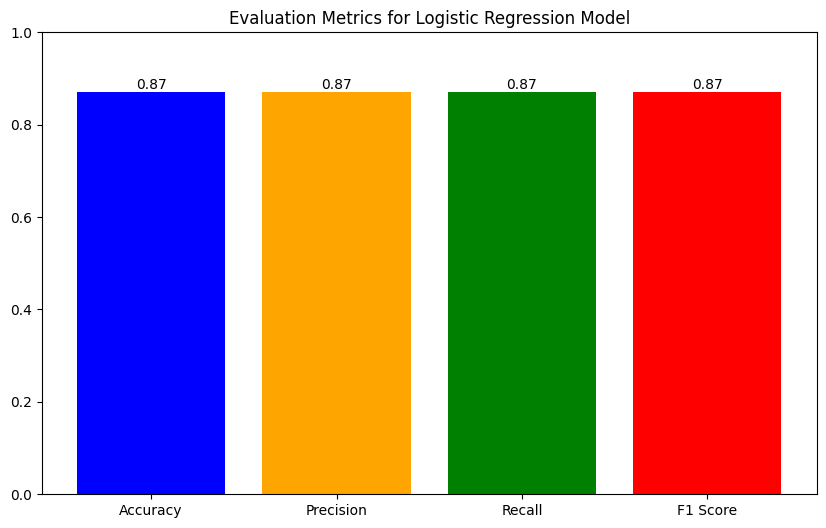

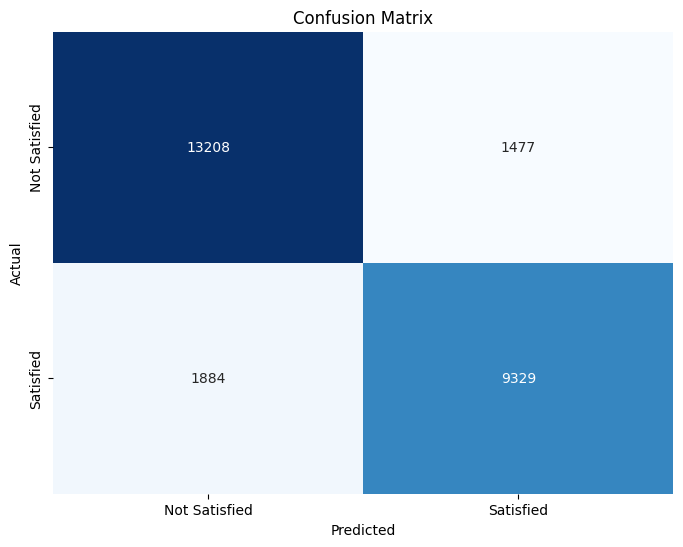

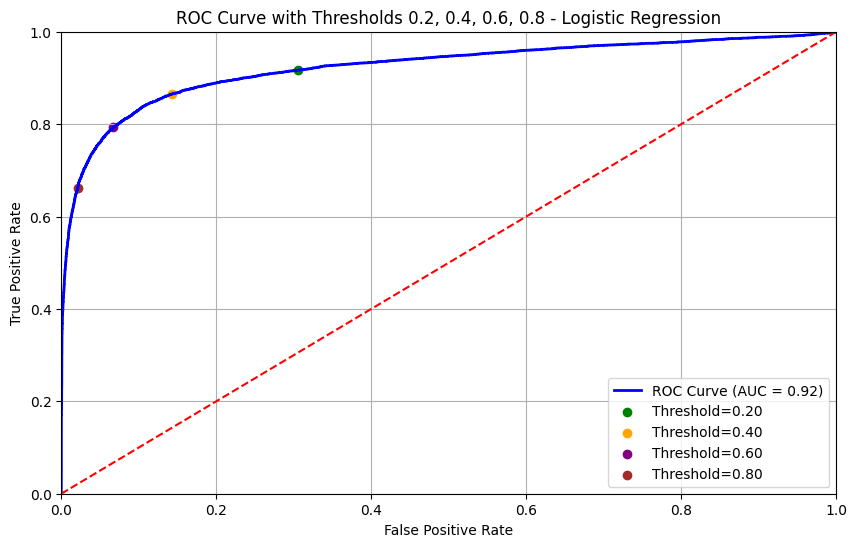

Threshold=0.20, FPR=0.31, TPR=0.92
Threshold=0.40, FPR=0.14, TPR=0.87
Threshold=0.60, FPR=0.07, TPR=0.79
Threshold=0.80, FPR=0.02, TPR=0.66


In [ ]:
# Features and target variable
selected_features = [
    'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance',
    'Departure Delay', 'Arrival Delay', 'Ease of Online Booking', 'Check-in Service',
    'Online Boarding', 'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
    'In-flight Entertainment', 'Baggage Handling'
]
X = df[selected_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the logistic regression model
logistic_model = LogisticRegression(max_iter=5000)  # Increase max_iter for convergence
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}", ha='center', va='bottom')

plt.title('Evaluation Metrics for Logistic Regression Model')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Logistic Regression')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

A reminder that our initial baseline model achieved an accuracy of 86%, a precision of 84%, a recall of 85%, and an F1 score of 84%.

When comparing our initial baseline model with our newly built model with 19 of the most optimal features that influence satisfaction, we see an increase in our results as they all score 87% respectively.

This means that our newly built model, which leverages the 19 most optimal features influencing satisfaction, provides a slight but notable improvement in performance compared to the baseline model. Specifically:

- Accuracy increased from 86% to 87%, indicating that the model now correctly predicts satisfaction for 87% of the instances.
- Precision improved from 84% to 87%, meaning the model is more precise in identifying satisfied customers without misclassifying as many unsatisfied ones.
- Recall increased from 85% to 87%, suggesting the model better captures the proportion of actual satisfied customers.
- F1 Score, which balances precision and recall, also rose from 84% to 87%, demonstrating a well-rounded improvement.

In terms of the confusion matrices, we note an increase in the correctly predicted non-satisfied customers and a notable decrease in the number of falsely predicted non-satisfied customers as satisfied. It is better to predict a satisfied customer as non-satisfied then a non-satisfied customer as satisfied. This will help improve the business's measure to improve their overall satisfaction.

Our model then also improved in reducing the number of falsely non-satisfied customers.

In terms of the ROC curve that helps us evaluate the rate of true positives to false positives, our suggested threshold is 0.4 as it minimizes false positives (14% rate) while maximizing true positives (87% rate). As the AUC stayed the same (92%), the FPR nevertheless decreased.

These overall findings tell us that the improved KBest logistic regression is the best.



##Decision Tree Classifier

Accuracy: 0.9447
Precision: 0.9448
Recall: 0.9447
F1 Score: 0.9448


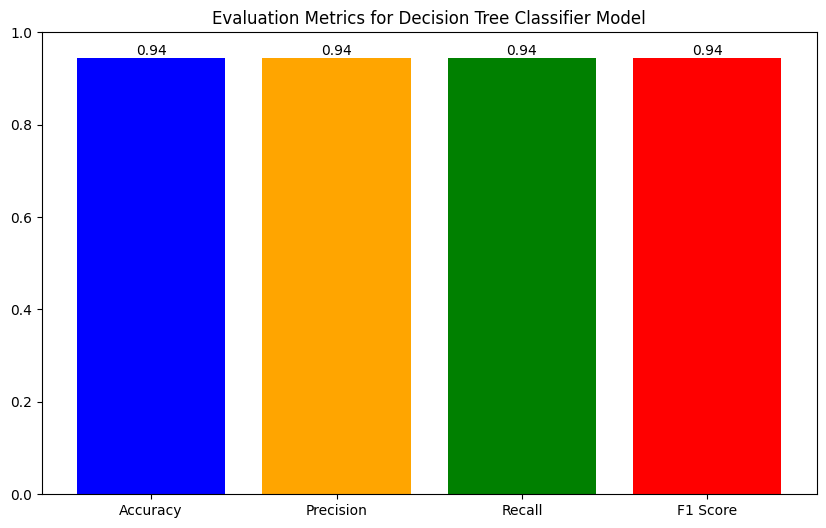

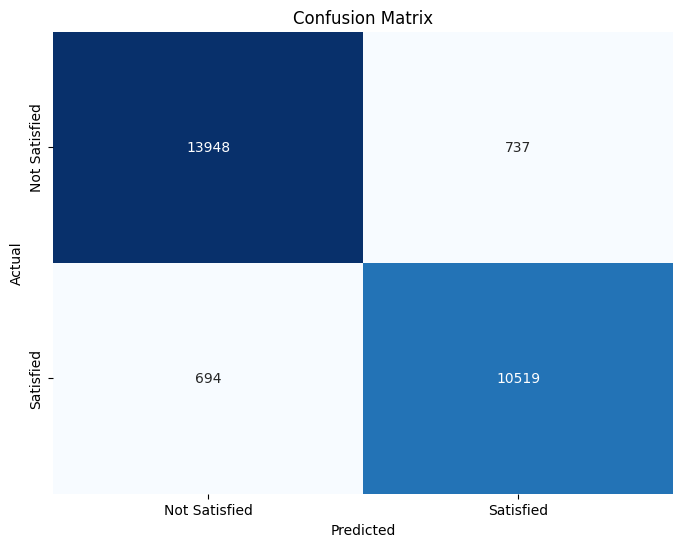

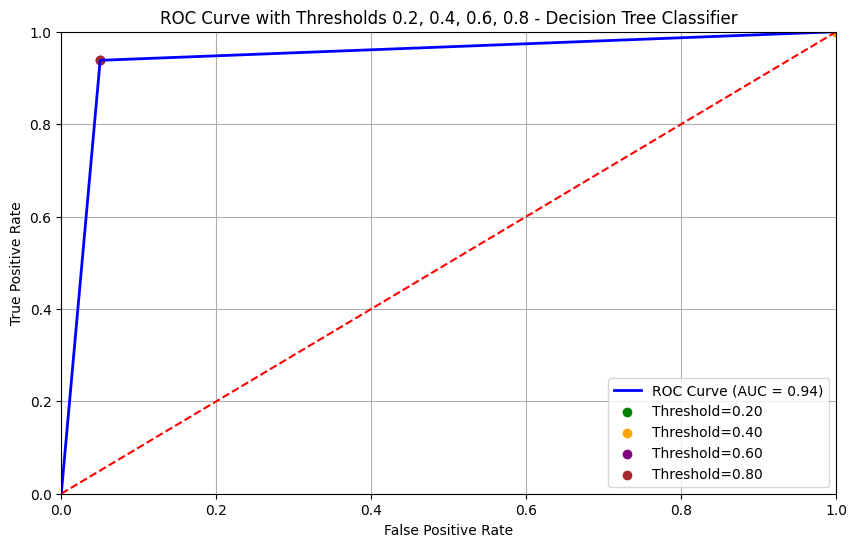

Threshold=0.20, FPR=1.00, TPR=1.00
Threshold=0.40, FPR=1.00, TPR=1.00
Threshold=0.60, FPR=0.05, TPR=0.94
Threshold=0.80, FPR=0.05, TPR=0.94


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)

# Replace with your DataFrame
# df = pd.read_csv('your_dataset.csv')

# Features and target variable
selected_features = [
    'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance',
    'Departure Delay', 'Arrival Delay', 'Ease of Online Booking', 'Check-in Service',
    'Online Boarding', 'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
    'In-flight Entertainment', 'Baggage Handling'
]
X = df[selected_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Decision Tree Classifier model
decision_tree_model = DecisionTreeClassifier(random_state=42)  # You can specify other parameters if needed
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}", ha='center', va='bottom')

plt.title('Evaluation Metrics for Decision Tree Classifier Model')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tree)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Decision Tree Classifier')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

A reminder that our initial baseline model achieved an accuracy of 95%, a precision of 93%, a recall of 94%, and an F1 score of 94%.

When comparing our initial baseline model with our newly DT built model using 19 of the most optimal features that influence satisfaction, we observe a slight decrease in our results as they all score 94% respectively.

This means that our newly built model, which leverages the 19 most optimal features influencing satisfaction, shows consistent performance compared to the baseline DT model. Specifically:

- Accuracy decreased from 95% to 94%, indicating that the model now correctly predicts satisfaction for 94% of the instances.
- Precision slighlty improves from 93% to 94%, which reflects the model's ability to correctly identify satisfied customers without misclassifying unsatisfied ones has remained stable.
- Recall stays constant (94%), suggesting that the model maintains its ability to capture the proportion of actual satisfied customers effectively.
- F1 Score, which balances precision and recall, stayed the same at 94%, indicating a well-rounded performance.

In terms of the confusion matrices, we note an increase in the correctly predicted non-satisfied customers (True Negatives increased from 13,937 to 13,948) but a slight decrease in the number of satisfied customers predicted correctly (True Positives decreased from 10,566 to 10,519). This suggests that while our model improved in identifying non-satisfied customers, it has slightly struggled to maintain the same level of identification for satisfied customers.

It is preferable to predict a satisfied customer as non-satisfied than to misclassify a non-satisfied customer as satisfied, as this can enhance the business's measures to improve overall satisfaction.

Our model then also maintained a similar performance in reducing the number of falsely identified non-satisfied customers. It, however, improves slightly as the False Positive rate is lower (748 to 737).

In terms of the ROC curve, which helps us evaluate the rate of true positives to false positives, our suggested threshold remains at 0.6, which yields a true positive rate of 94% and a false positive rate of 5%. The AUC slightly dropped  at 94%, reflecting stable performance.

These overall findings indicate that the optimized decision tree model using KBest features provides robust performance, remaining comparable to the initial baseline model.

Our suggested model between these two remains the initial baseline model as the change of False Positive Rate is not really high while the DT baseline maintains better accuracy standing.

##Random Forest Classifier

Accuracy: 0.9622
Precision: 0.9625
Recall: 0.9622
F1 Score: 0.9622


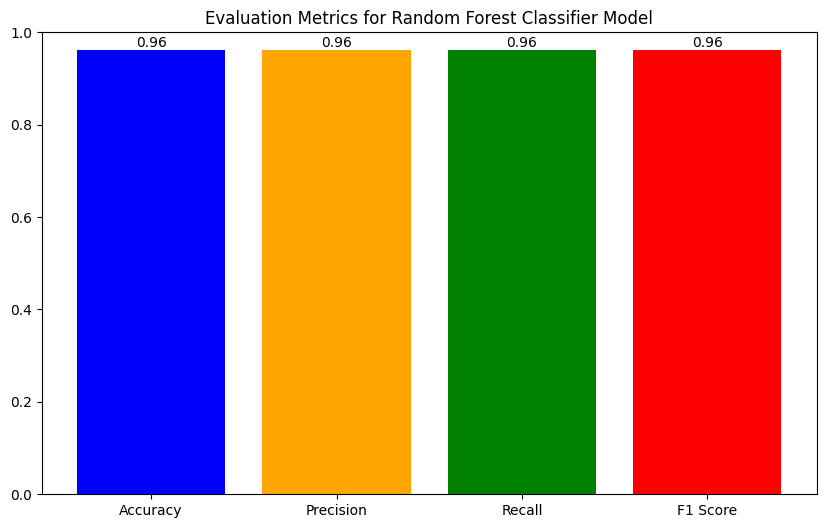

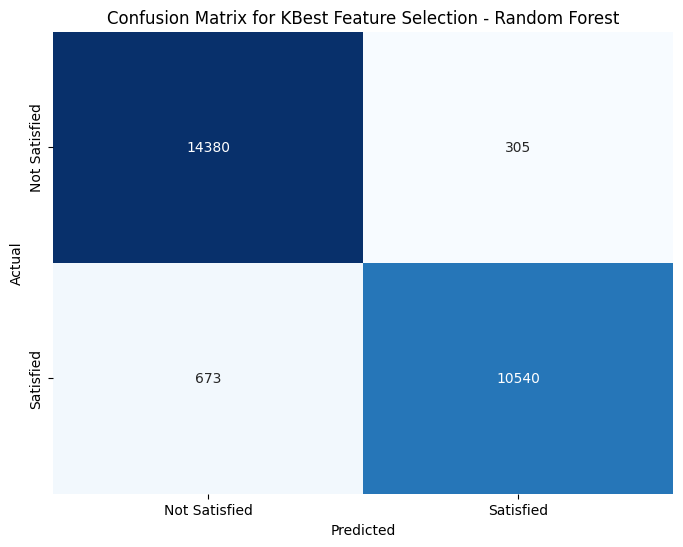

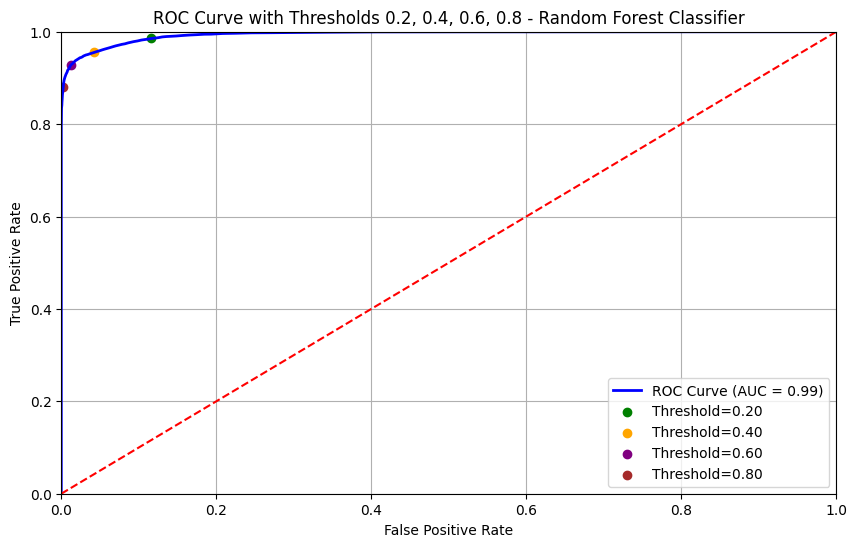

Threshold=0.20, FPR=0.12, TPR=0.99
Threshold=0.40, FPR=0.04, TPR=0.96
Threshold=0.60, FPR=0.01, TPR=0.93
Threshold=0.80, FPR=0.00, TPR=0.88


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)

# Replace with our DataFrame
# df = pd.read_csv('your_dataset.csv')

# Features and target variable
selected_features = [
    'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance',
    'Departure Delay', 'Arrival Delay', 'Ease of Online Booking', 'Check-in Service',
    'Online Boarding', 'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
    'In-flight Entertainment', 'Baggage Handling'
]
X = df[selected_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Random Forest Classifier model
random_forest_model = RandomForestClassifier(random_state=42)  # We can specify other parameters if needed
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}", ha='center', va='bottom')

plt.title('Evaluation Metrics for Random Forest Classifier Model')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for KBest Feature Selection - Random Forest')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Random Forest Classifier')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Our random forest was our best baseline models. Now, let's compare it with its improved version using the best 19 features.

A reminder that our initial random forest baseline model achieved an accuracy of 96%, a precision of 97%, a recall of 94%, and an F1 score of 96%.

When comparing our initial random forest baseline model with our newly built Random Forest model that utilizes KBest feature selection, we observe that all metrics remain stable at 96%. This consistency indicates that the model's performance is robust across both configurations, suggesting that the selected features did not significantly alter the predictive power of the model.

Specifically:

- Accuracy remained at 96%, indicating that the model accurately predicts satisfaction for 96% of the instances.

- Precision dropped by a little 1% (97% to 96%), meaning the model still maintains a high level of precision in identifying satisfied customers without misclassifying unsatisfied ones.

- Recall increased from 94% to 96%, suggesting that the model is effective in capturing the proportion of actual satisfied customers.

- F1 Score, which balances precision and recall, was stable at 96%, demonstrating well-rounded performance.

In terms of the confusion matrices, we note a slight increase in the correctly predicted non-satisfied customers (True Negatives) from 14,360 to 14,380, as well as a reduction in the number of falsely predicted non-satisfied customers as satisfied (False Positives) from 325 to 305. It is generally better to predict a satisfied customer as non-satisfied than to misclassify a non-satisfied customer as satisfied, as the latter can negatively impact customer satisfaction metrics.

Both models also exhibited identical performance in terms of the ROC curve, with an AUC of 99%. The threshold of 0.4 was determined to be optimal, maintaining a True Positive Rate (TPR) of 96% and a False Positive Rate (FPR) of 0.04.

These overall findings indicate that the KBest Random Forest model retains the performance of the baseline model while potentially offering insights into feature importance.

Overall from what we've seen, our random forest is our best model in terms of accuracy and number of false positives!

##Gradient Boosting Classifier

Accuracy: 0.9420
Precision: 0.9420
Recall: 0.9420
F1 Score: 0.9420


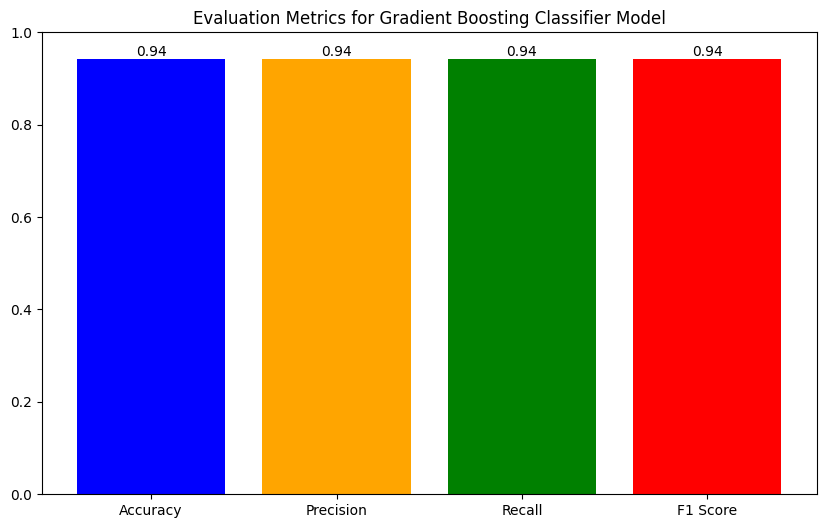

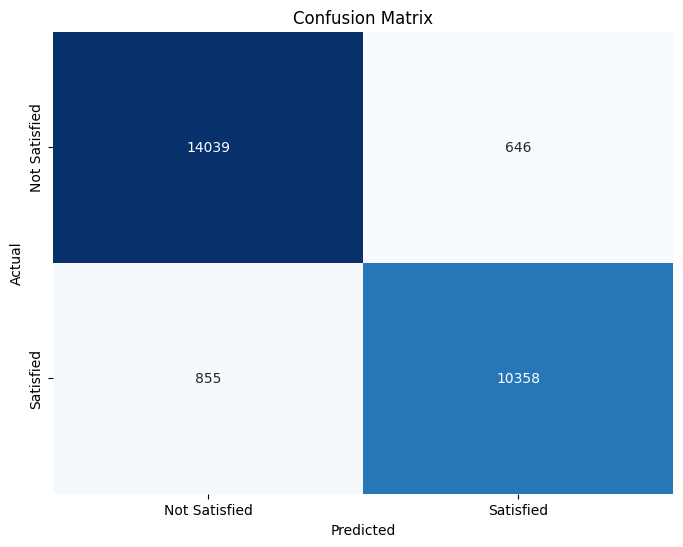

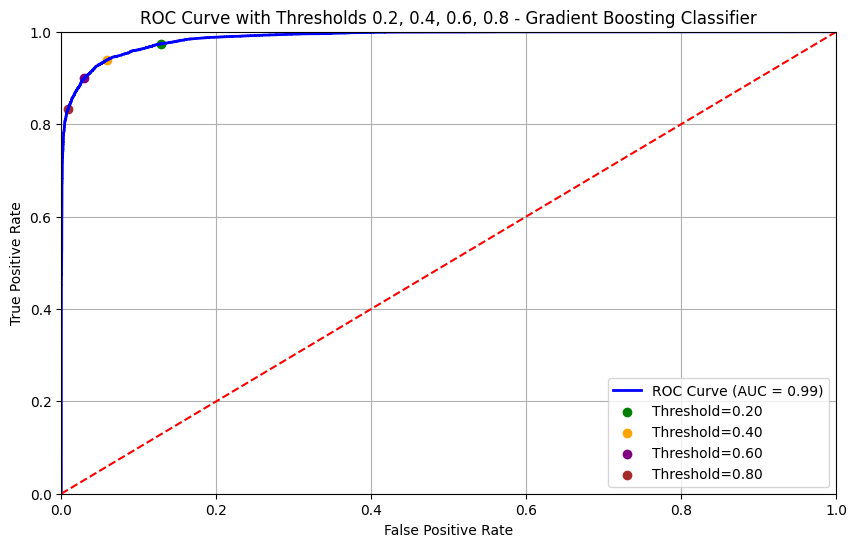

Threshold=0.20, FPR=0.13, TPR=0.97
Threshold=0.40, FPR=0.06, TPR=0.94
Threshold=0.60, FPR=0.03, TPR=0.90
Threshold=0.80, FPR=0.01, TPR=0.83


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)

# Replace with your DataFrame
# df = pd.read_csv('your_dataset.csv')

# Features and target variable
selected_features = [
    'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance',
    'Departure Delay', 'Arrival Delay', 'Ease of Online Booking', 'Check-in Service',
    'Online Boarding', 'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
    'In-flight Entertainment', 'Baggage Handling'
]
X = df[selected_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Gradient Boosting Classifier model
gradient_boosting_model = GradientBoostingClassifier(random_state=42)  # You can specify other parameters if needed
gradient_boosting_model.fit(X_train, y_train)

# Make predictions
y_pred = gradient_boosting_model.predict(X_test)
y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}", ha='center', va='bottom')

plt.title('Evaluation Metrics for Gradient Boosting Classifier Model')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gb)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Gradient Boosting Classifier')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Let's now compare our Gradient Boosting baseline to its enhanced version utilizing the best 19 features.

Accuracy and Precision remained consistent between both models at 94%, indicating that there was no significant difference in overall performance in these metrics after selecting the 19 most optimal features.

However, the recall and the F1 score see a slight increase in their predictive power suggesting improvements in our model.

In terms of the confusion matrix, we see a slight increase in false negatives (from 842 to 855) and a very small increase in false positives (from 642 to 646). This indicates a slight trade-off in identifying satisfied customers correctly.

ROC Analysis shows that both models have an AUC of 99%, which is excellent. However, the KBest model has a slightly lower True Positive Rate (94%) and a higher False Positive Rate (0.06) compared to the baseline model, which maintains a TPR of 96% and an FPR of 0.04 at the same threshold of 0.4.

The suggested model between the baseline and the improved KBest model is the initial baseline model as less false positives are misclassified and the performance metrics are not distant from each other.

##K-Nearest Neighbor

Accuracy: 0.7577
Precision: 0.7568
Recall: 0.7577
F1 Score: 0.7558


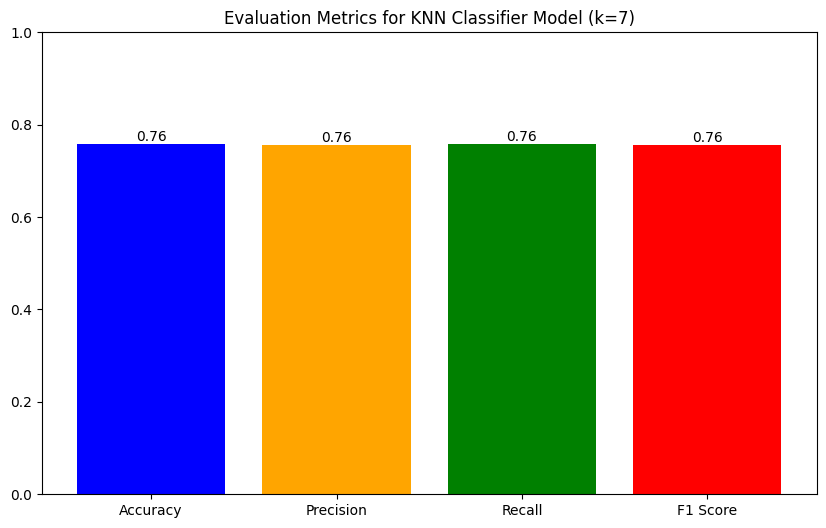

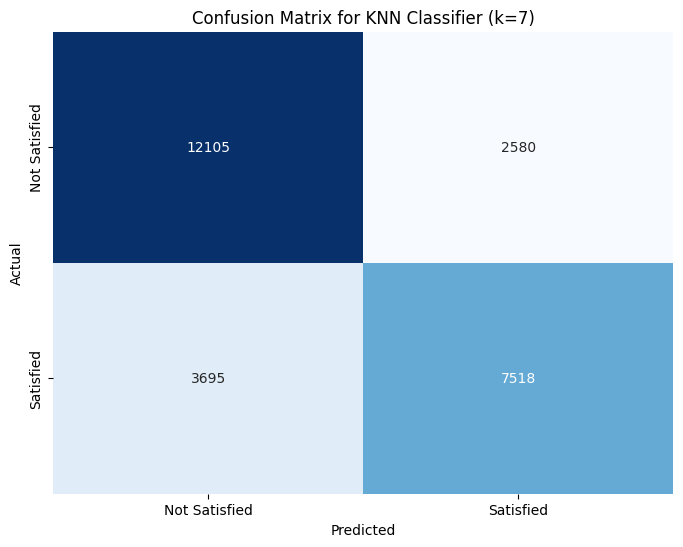

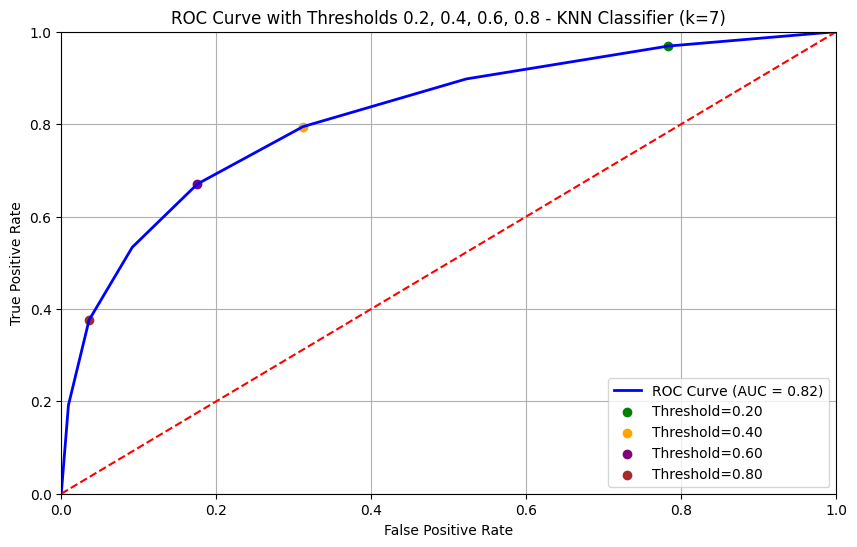

Threshold=0.20, FPR=0.78, TPR=0.97
Threshold=0.40, FPR=0.31, TPR=0.79
Threshold=0.60, FPR=0.18, TPR=0.67
Threshold=0.80, FPR=0.04, TPR=0.38


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)

# Features and target variable
selected_features = [
    'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance',
    'Departure Delay', 'Arrival Delay', 'Ease of Online Booking', 'Check-in Service',
    'Online Boarding', 'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
    'In-flight Entertainment', 'Baggage Handling'
]
X = df[selected_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the KNN model
k_neighbors = 7
knn_model = KNeighborsClassifier(n_neighbors=k_neighbors)
knn_model.fit(X_train, y_train)

# Make predictions
y_pred = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}", ha='center', va='bottom')

plt.title('Evaluation Metrics for KNN Classifier Model (k=7)')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for KNN Classifier (k=7)')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - KNN Classifier (k=7)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")


From our baseline models, our worse performing model was our KNN model with 76% accuracy, 75% precision, 68% recall, and 71% as an F1 score.

Moreover, its false positives were very high (2588) suggesting that a lot of our non-satisfied passengers have been predicted as satisfied. Earlier, we mentioned that wronging the non-satisfied passengers' predictions can be detrimental for the airline company as a lot of wrong information will be used to improve their customers' satisfaction.

As the K-Nearest Neighbor was improved using the best 19 features contributing to satisfaction, we see overall increases in predictive capacity. However, the results still remain poor.

With an ideal 19 number of features, we believe that the best threshold to utilize amounts to 0.4 with a false positive rate of 0.31 and a true positive rate of 0.79. Although these numbers are far from perfect, they balance the ratio of false positives to true positives well.

As compared to the other areas under the curve, the K-Nearest Neighbor remains the worse.

The dataset contains numerous features (19 in the KBest selection). KNN struggles in high-dimensional spaces because of the curse of dimensionality. In higher dimensions, data points become sparse, and the notion of "closeness" in terms of Euclidean distance becomes less meaningful. This makes it harder for KNN to find true neighbors that are actually similar explaining why it is scoring worse than the others.

##Naive Bayes

Accuracy: 0.8606
Precision: 0.8604
Recall: 0.8606
F1 Score: 0.8602


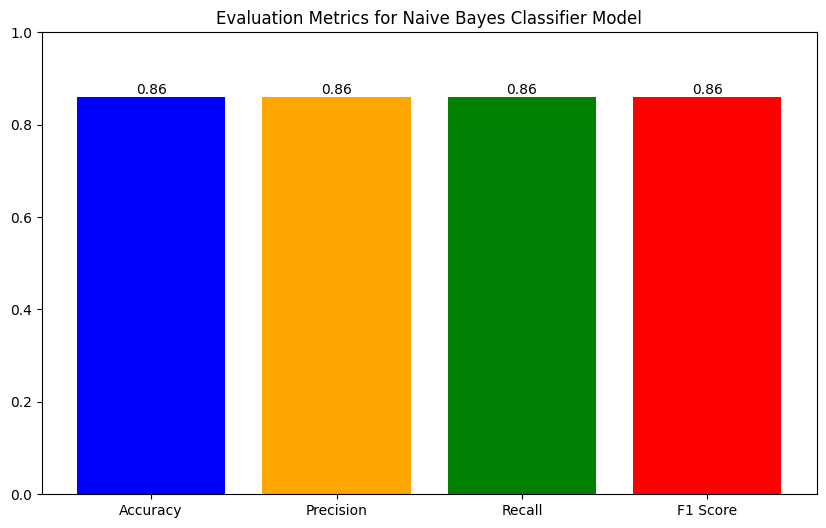

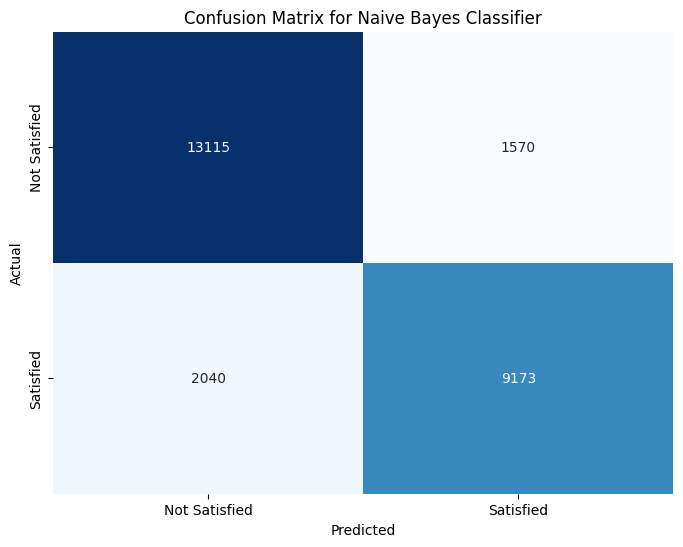

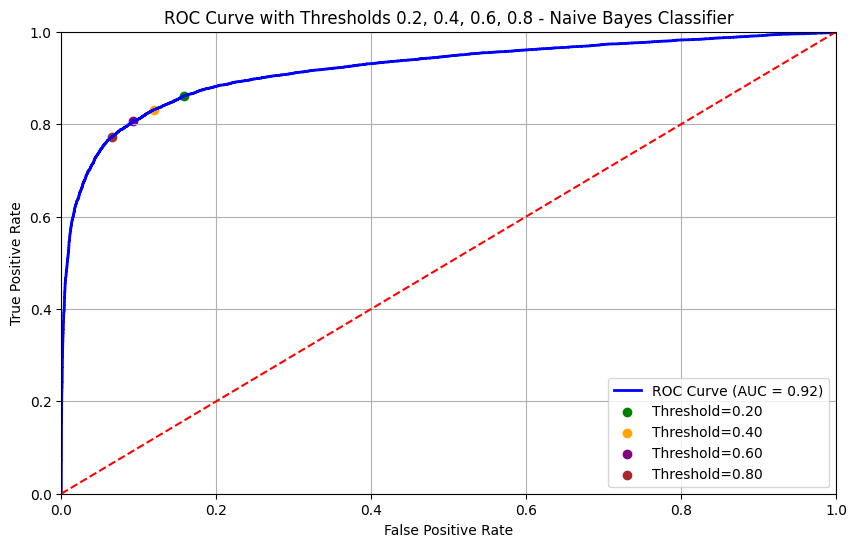

Threshold=0.20, FPR=0.16, TPR=0.86
Threshold=0.40, FPR=0.12, TPR=0.83
Threshold=0.60, FPR=0.09, TPR=0.81
Threshold=0.80, FPR=0.07, TPR=0.77


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)

# Replace with your DataFrame
# df = pd.read_csv('your_dataset.csv')

# Features and target variable
selected_features = [
    'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance',
    'Departure Delay', 'Arrival Delay', 'Ease of Online Booking', 'Check-in Service',
    'Online Boarding', 'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
    'In-flight Entertainment', 'Baggage Handling'
]
X = df[selected_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Naive Bayes model
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train, y_train)

# Make predictions
y_pred = naive_bayes_model.predict(X_test)
y_prob_nb = naive_bayes_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}", ha='center', va='bottom')

plt.title('Evaluation Metrics for Naive Bayes Classifier Model')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive Bayes Classifier')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Naive Bayes Classifier')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

In the beginning, we were able to compare our different baseline models and found out what our worse model was.

Nevertheless, our second to worse model was the Naive Bayes. This statement appears to be true even with the best 19 features taken into account.

With a fairly good area under the curve of 92%, at a threshold of 0.4, our model provides an FPR of 0.12 and a TPR of 0.83.

Although, false positives are minimized with an increase in true positives, our predictions still appear to be wrong.

The reason why this model does not perform outstandingly well lies in the strong independence assumption it makes between features. Naive Bayes assumes that all features are independent of each other, meaning it considers each feature's contribution to the prediction separately.

In this customer satisfaction dataset, this assumption rarely holds true. Many features are likely correlated or interact with each other (e.g., flight distance and type of airline). When these dependencies are ignored, the model’s predictions can become less accurate.

##Comparison of Kbest Models

Model Comparison Overview:

Baseline Models: Served as initial benchmarks for performance comparison.
KBest Selection: Improved some models slightly by selecting 19 most relevant features, but not all models saw significant performance gains.

Performance of Individual Models:

- Logistic Regression:
Initial Baseline: Accuracy 86%, Precision 84%, Recall 85%, F1 Score 84%.
Improved KBest Model: Accuracy, Precision, Recall, and F1 Score all improved to 87%.

The model improved in correctly predicting non-satisfied customers and reducing false positives, making it a better choice for minimizing business impact from false satisfaction predictions.

- Decision Tree:
Initial Baseline: Accuracy 95%, Precision 93%, Recall 94%, F1 Score 94%.
KBest Model: Slight decrease in accuracy to 94% but maintained Precision, F1 score, and Recall at 94%.

Increased ability to predict non-satisfied customers but showed a trade-off in predicting satisfied ones.
The baseline model was preferred due to overall stability.

- Gradient Boosting:
Both baseline and KBest models had stable Accuracy (94%) and Precision.
Minor improvements in Recall and F1 score for KBest but a slight increase in false negatives and positives.

The baseline model was selected due to better balance between true and false positives.

- K-Nearest Neighbors (KNN):
Baseline performed the worst, with an Accuracy of 76%, Precision 75%, Recall 68%, and F1 Score 71%.

KBest improved the model but still performed poorly due to KNN’s struggle in high-dimensional spaces, known as the curse of dimensionality.

- Naive Bayes:
Baseline Accuracy was 86%, with KBest maintaining recall and F1 score, it still faced challenges due to the independence assumption between features.

The model did not account for feature interactions, making it less effective despite good accuracy.

- Random Forest:

Baseline Model: Accuracy 96%, Precision 97%, Recall 94%, F1 Score 96%.
KBest Model: Maintained stability across all metrics, showing robustness.
Slight 1% drop in precision (from 97% to 96%), but the model remains highly accurate.

The random forest model was the most successful, even after feature reduction.

- Conclusion & Best Model:
Best Performing Model: The Random Forest model with or without KBest performed consistently well across all metrics, making it the best choice for customer satisfaction prediction.

KBest Feature Selection: Helped improve logistic regression and stabilize performance in most models, but the overall impact was minimal in models like random forest.

Business Impact: Models that minimize false positives (misclassifying unsatisfied customers as satisfied) are preferred to help airlines focus on actual areas for improvement.

#LASSO

Now, we are moving on to LASSO(Least Absolute Shrinkage and Selection Operator).

LASSO feature selection is a method for identifying important factors in data. By automatically reducing the impact of less important factors to zero(Regularization Effect), LASSO simplifies the analysis and allows the model to focus on key elements.

This reduction is controlled by a parameter called alpha—a higher alpha results in more aggressive elimination of less significant factors. Each feature is assigned a coefficient that reflects its importance; larger absolute values indicate greater impact on predictions. LASSO shrinks some coefficients to zero, effectively removing those features from the model.

Additionally, LASSO introduces a penalty to the loss function, proportional to the absolute values of the coefficients. A higher alpha increases this penalty, leading to more coefficients being shrunk to zero. This helps retain only the most significant features, preventing overfitting and enhancing the model's ability to generalize to new data.

We would like to proceed with LASSO as follows;

 - Setting Alpha and Comparing Accuracy
 - Selecting the Optimal Alpha
 - Model Construction
 - Comparing Evaluation Metrics
 - Interpreting the Results

##Selecting the alpha

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.697e+03, tolerance: 2.546e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

Alpha: 0.00, Accuracy: 0.8685, Selected Features: ['Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling']
Alpha: 0.10, Accuracy: 0.8320, Selected Features: ['Type of Travel', 'Class', 'Online Boarding', 'On-board Service', 'Leg Room Service', 'In-flight Entertainment']
Alpha: 0.20, Accuracy: 0.6981, Selected Features: ['Class', 'Online Boarding']
Alpha: 0.30, Accuracy: 0.5670, Selected Features: []
Alpha: 0.40, Accuracy: 0.5670, Selected Features: []
Alpha: 0.50, Accuracy: 0.5670, Selected Features: []
Alpha: 0.60, Accuracy: 0.5670, Selected Features: []
Alpha: 0.70, Accuracy: 0.5670, Selected Features: []
Alpha: 0.80, Accur

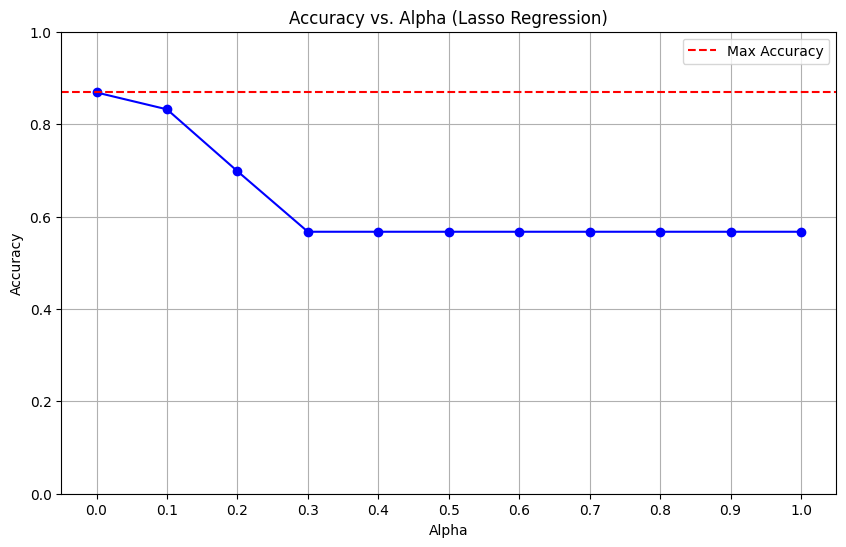

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Replace with your DataFrame
# df = pd.read_csv('your_dataset.csv')

# Features and target variable
X = df.drop(columns=['Satisfaction'])  # Use all features except the target
y = df['Satisfaction']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

alpha_values = np.linspace(0.0, 1.0, num=11)  # Alpha from 0.0 to 1.0
accuracies = []
selected_features_list = []

for alpha in alpha_values:
    # Build and train the Lasso model
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(X_train, y_train)

    # Make predictions
    y_pred = np.round(lasso_model.predict(X_test)).astype(int)  # Convert to binary predictions

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    # Get selected features
    selected_features = X.columns[lasso_model.coef_ != 0].tolist()
    selected_features_list.append(selected_features)

    print(f'Alpha: {alpha:.2f}, Accuracy: {accuracy:.4f}, Selected Features: {selected_features}')

# Plot the accuracy for each alpha value
plt.figure(figsize=(10, 6))
plt.plot(alpha_values, accuracies, marker='o', color='b')
plt.title('Accuracy vs. Alpha (Lasso Regression)')
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xticks(alpha_values)
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.axhline(y=max(accuracies), color='r', linestyle='--', label='Max Accuracy')
plt.legend()
plt.show()

The results we're observing from our Lasso regression analysis indicate the impact of different alpha values on model performance and feature selection. Here's a breakdown of what and why we're seeing such results:

 **Explanation of Results:**
By creating a line graph for each alpha value from 0.0 to 1.0, we can easily identify which alpha demonstrates the best performance at a glance. When alpha is 0.0, it shows the maximum accuracy, and there is a decreasing trend as alpha approaches 0.3; after 0.3, the accuracy remains flat. Let's take a deeper look at each alpha.



1. **Alpha = 0.00:**

 - **Accuracy**: 0.8685 (highest accuracy)
 - **Selected Features:** All features are included when alpha is 0. This leads to the highest accuracy because all available information is utilized. In other words, even if modeling is done based on the results of this feature selection, the results will be the same as those of the baseline models for each modeling.

2. **Alpha = 0.10 to 0.20:**

 - **Decreased Accuracy:** As we increase alpha, the model starts to penalize the coefficients more strongly. This regularization reduces the complexity of the model but can lead to a loss of important features, hence the drop in accuracy.

 - **Selected Features:** Fewer features are selected as the model penalizes more coefficients to be zero. This means it's trying to simplify the model by reducing overfitting but may also exclude useful information.

3. **Alpha = 0.30 to 1.00:**

 - **Accuracy:** The accuracy drops significantly (down to 0.5670) as alpha increases past 0.20.

 - **Selected Features:** The model ends up with no selected features (coefficients are driven to zero). This happens because Lasso’s nature is to shrink coefficients, and with high alpha values, it forces them all to be zero, leading to a model that cannot predict anything (similar to a random guess).


 Given that we are setting alpha to 0.0, the modeling will utilize all available features, resulting in the same feature set as the baseline models. This means that the performance metrics obtained from our LASSO model will be identical to those of the baseline models. Therefore, there is no need to perform the modeling process again in this section, as it would not yield any new insights or improvements over the baseline results.



#Decision Tree Feature Selection

##Important Features

Most Important Features:
                                   Feature  Importance
11                         Online Boarding    0.362076
19                  In-flight Wifi Service    0.178579
3                           Type of Travel    0.148121
20                 In-flight Entertainment    0.046977
2                            Customer Type    0.040719
10                        Check-in Service    0.028476
5                          Flight Distance    0.026226
4                                    Class    0.021559
1                                      Age    0.020694
12                           Gate Location    0.020281
21                        Baggage Handling    0.017444
14                            Seat Comfort    0.015706
18                       In-flight Service    0.014357
16                             Cleanliness    0.009579
13                        On-board Service    0.008915
7                            Arrival Delay    0.008832
15                        Leg Room Servi

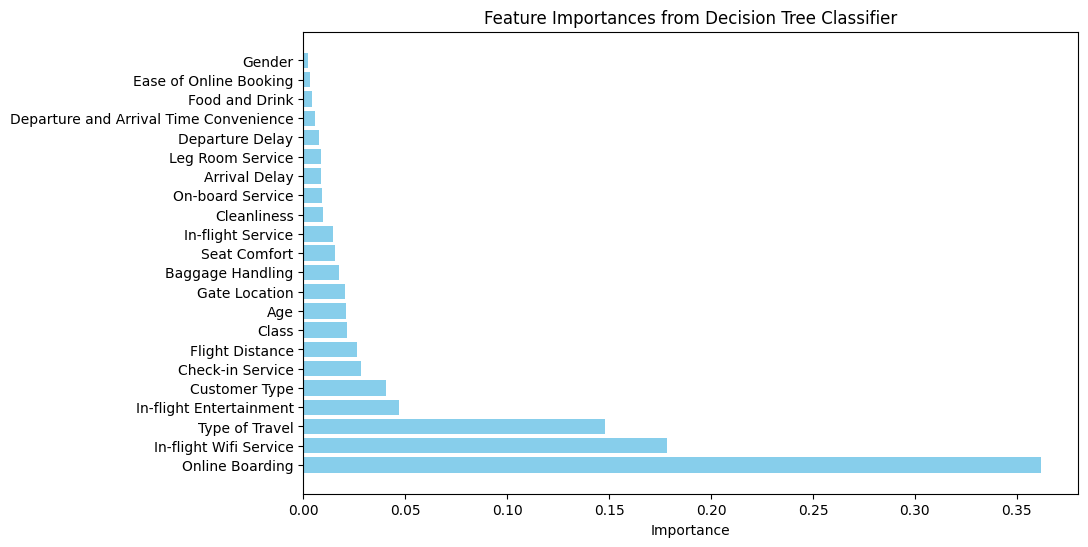

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Get feature importances
importances = decision_tree_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Sort the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the most important features
print("Most Important Features:")
print(feature_importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importances from Decision Tree Classifier')
plt.show()

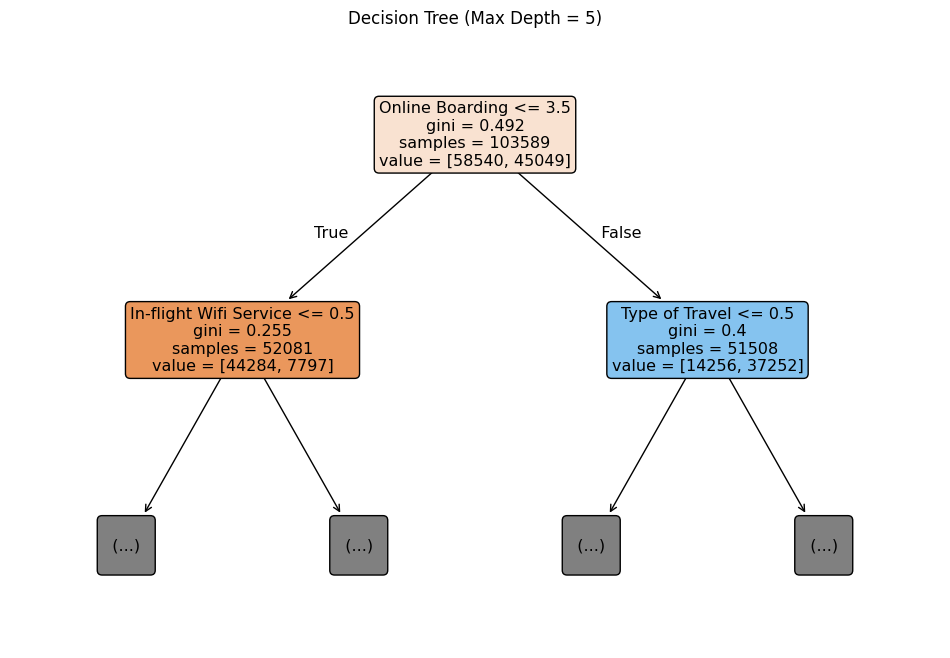

In [ ]:
# Plot the decision tree up to level 5
plt.figure(figsize=(12, 8))
plot_tree(decision_tree_model,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          max_depth=1)
plt.title('Decision Tree (Max Depth = 5)')
plt.show()

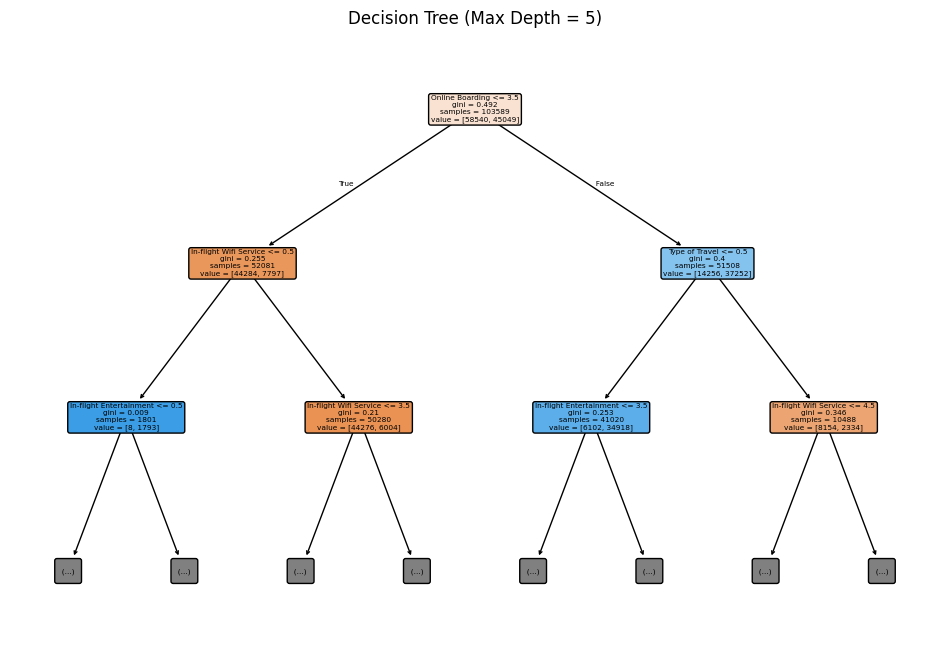

In [ ]:
# Plot the decision tree up to level 5
plt.figure(figsize=(12, 8))
plot_tree(decision_tree_model,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          max_depth=2)
plt.title('Decision Tree (Max Depth = 5)')
plt.show()

Feature importance extraction:
- The process first trains a decision tree model with the satisfaction column as the target variable.
- After training, the feature importance is extracted to measure the amount of information each feature provides in predicting the target variable (satisfaction).

Most influential features:
- The model identifies “online check-in” as the most important feature, with an importance of about 0.36, indicating that the quality or efficiency of the online check-in process has a significant impact on customer satisfaction.
- The importance of “in-flight Wifi service” is about 0.18, indicating that in-flight internet connection is an important factor affecting passenger satisfaction.
- The importance of “type of travel” (business or personal) is about 0.15, which also shows its important influence.

Features with less influence:
- The importance scores of features such as “gender” and “ease of online booking” are very low (about 0.002 and 0.003, respectively), which indicates that their impact on overall customer satisfaction is minimal in the context of other evaluated features.

Decision tree visualization:
- The decision tree diagram depicts the branches starting from “online check-in” and shows that satisfaction depends primarily on this feature before other factors such as “in-flight Wifi service” and “type of travel” are considered.
- The tree structure shows us how different features interact and influence the prediction. For example, the level of satisfaction depends primarily on online check-in before other services such as in-flight Wifi come into play.


##Models- Decision Tree FS

##Logistic Regression

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.87
Precision: 0.85
Recall: 0.84
F1 Score: 0.84


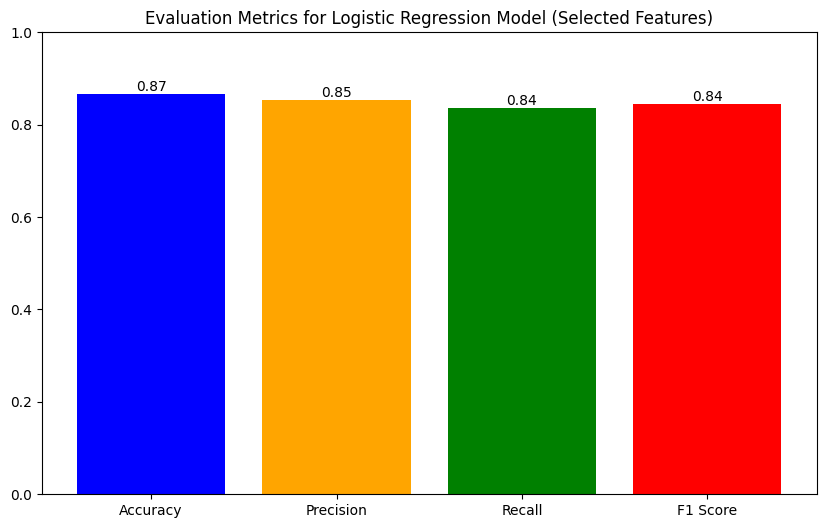

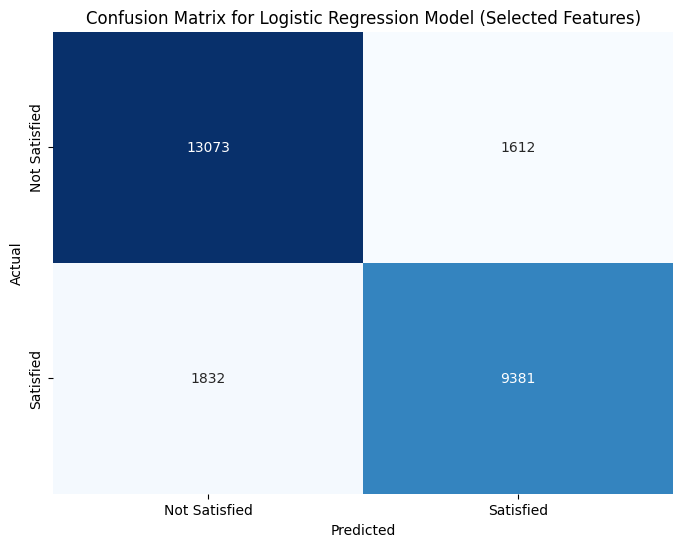

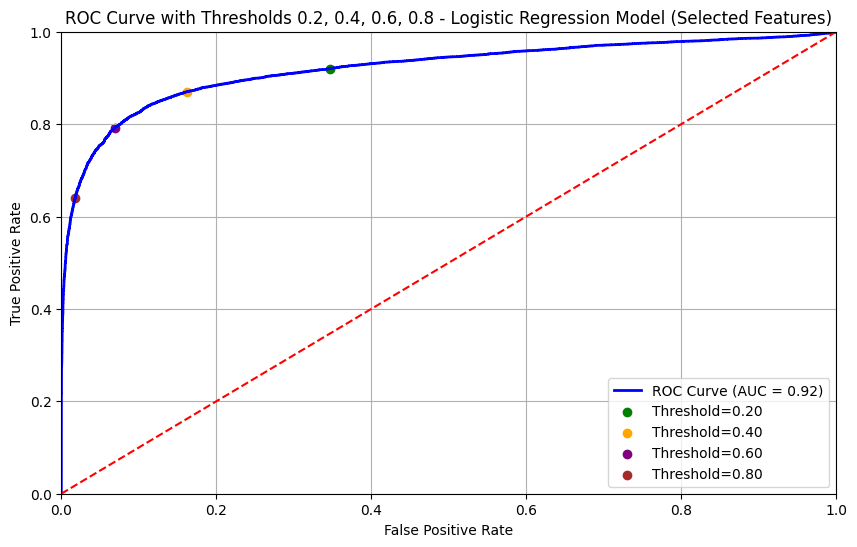

Threshold=0.20, FPR=0.35, TPR=0.92
Threshold=0.40, FPR=0.16, TPR=0.87
Threshold=0.60, FPR=0.07, TPR=0.79
Threshold=0.80, FPR=0.02, TPR=0.64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select the most important features based on the decision tree feature importance
important_features = ['Online Boarding', 'In-flight Wifi Service', 'Type of Travel',
                      'In-flight Entertainment', 'Customer Type', 'Check-in Service',
                      'Flight Distance', 'Class', 'Age', 'Gate Location',
                      'Baggage Handling', 'Seat Comfort', 'In-flight Service',
                      'Cleanliness', 'On-board Service']  # Adjust this list based on your results

# Features and target variable
X = df[important_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.title('Evaluation Metrics for Logistic Regression Model (Selected Features)')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression Model (Selected Features)')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Logistic Regression Model (Selected Features)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Accuracy: 0.87
- The model performed well, correctly predicting satisfaction 87% of the time, but there is still room for improvement, especially when compared to other models such as random forests or gradient boosting, which can achieve higher accuracy.

Precision: 0.85
- The accuracy indicates that the model is correct up to 85% of the time when predicting customer satisfaction. This is a very high value and indicates that the model is very reliable in terms of positive classification.

Recall: 0.84
- The recall rate is 0.84, indicating that the model can identify 84% of the actual satisfied customers. This balance between accuracy and recall rate indicates that the model is not heavily biased towards one type of error.

F1 Score: 0.84
- The F1 score, which takes into account both precision and recall, is also 0.84, indicating a good balance between precision and recall, but also that improving either indicator can help improve the score.


Confusion Matrix Analysis:

- The confusion matrix shows that the model correctly identified 13,073 “unsatisfied” predictions and 9,381 “satisfied” predictions.
- However, it incorrectly predicted 1,612 “unsatisfied” predictions as “satisfied” and 1,832 “satisfied” predictions as “unsatisfied”. This area, in particular, can have serious consequences for misjudgments, as the failure to identify satisfied customers can have an impact on business.


ROC Curve and AUC:
- The ROC curve shows an area under the curve (AUC) score of 0.92, indicating that the model performs well in distinguishing between satisfied and dissatisfied customers. This is consistent with a strong classifier that maintains a good balance between true positive rate and false positive rate.
- The threshold setting shows the trade-off between the true positive rate (recall) and the false positive rate. For example, lowering the threshold can increase the true positive rate, but it can also increase the false positive rate, depending on the importance of capturing all potentially satisfied customers, even at the risk of increasing false positives.


##Decision Tree Classifier

Accuracy: 0.94
Precision: 0.93
Recall: 0.94
F1 Score: 0.94


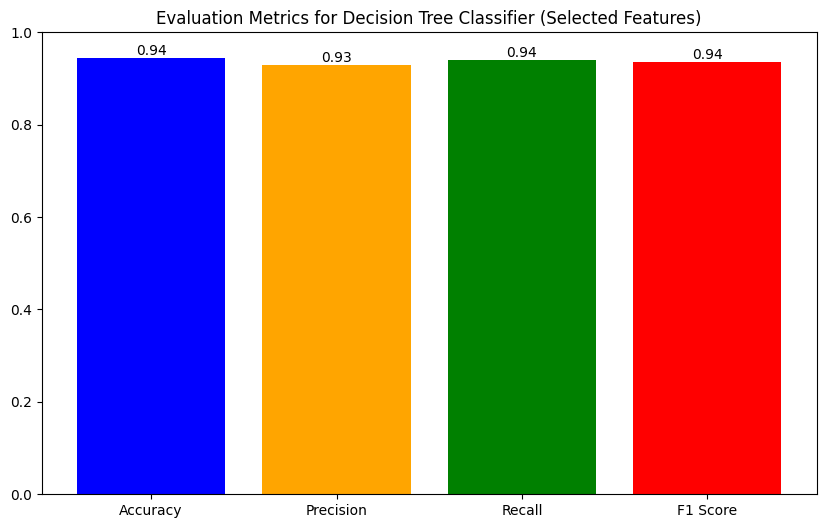

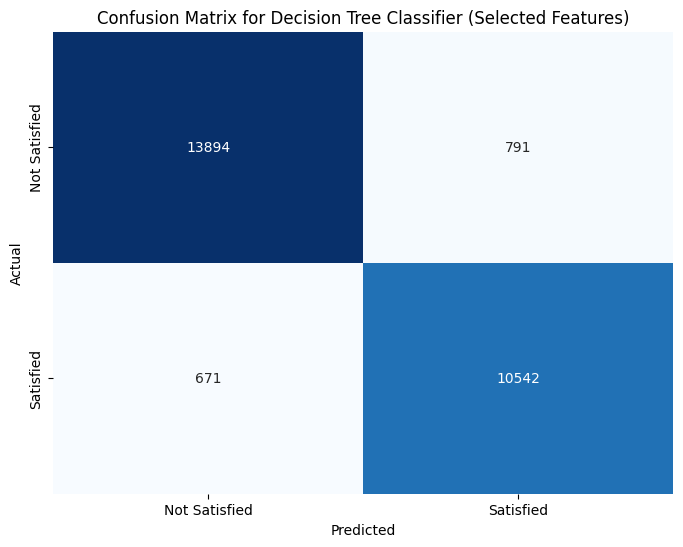

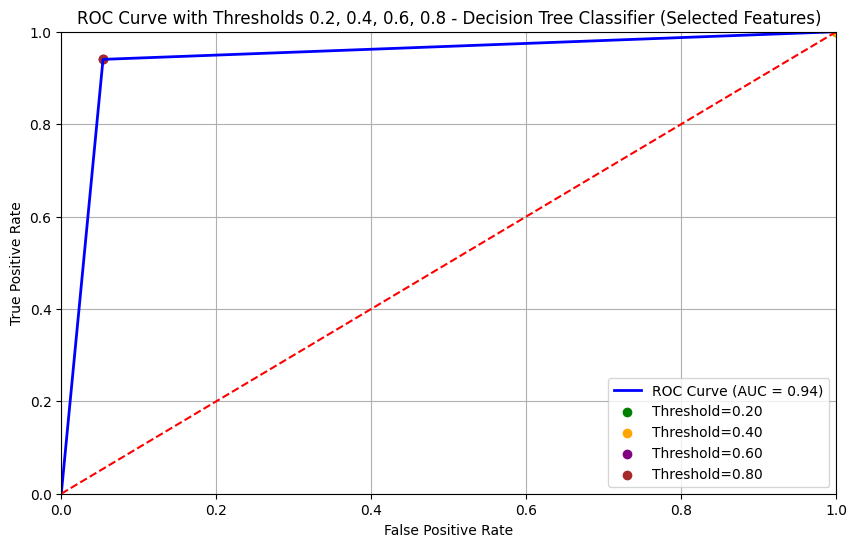

Threshold=0.20, FPR=1.00, TPR=1.00
Threshold=0.40, FPR=1.00, TPR=1.00
Threshold=0.60, FPR=0.05, TPR=0.94
Threshold=0.80, FPR=0.05, TPR=0.94


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select the most important features based on the decision tree feature importance
important_features = ['Online Boarding', 'In-flight Wifi Service', 'Type of Travel',
                      'In-flight Entertainment', 'Customer Type', 'Check-in Service',
                      'Flight Distance', 'Class', 'Age', 'Gate Location',
                      'Baggage Handling', 'Seat Comfort', 'In-flight Service',
                      'Cleanliness', 'On-board Service']  # Adjust this list based on your results

# Features and target variable
X = df[important_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Decision Tree Classifier model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.title('Evaluation Metrics for Decision Tree Classifier (Selected Features)')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Decision Tree Classifier (Selected Features)')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tree)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Decision Tree Classifier (Selected Features)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

1. Accuracy: The model achieves an accuracy of 0.94, indicating that it correctly predicts the outcome 94% of the time.

2. Precision: At 0.93, the precision suggests that when the model predicts a class (satisfied or not satisfied), it is correct 93% of the time.

3. Recall: The recall, also at 0.94, means the model successfully captures 94% of the actual instances of the classes.

4. F1 Score: The F1 score, which balances precision and recall, is also at 0.94, indicating a very effective model at both retrieving relevant instances and being accurate.


The confusion matrix further supports this, showing that the model successfully distinguishes between the satisfied and not satisfied classes with high accuracy, with relatively few misclassifications:
- True Negatives (Not Satisfied, Predicted Correctly): 13,894
- False Positives (Not Satisfied, Predicted as Satisfied): 791
- False Negatives (Satisfied, Predicted as Not Satisfied): 671
- True Positives (Satisfied, Predicted Correctly): 10,542


The ROC Curve demonstrates a high AUC (Area Under Curve) of 0.94, which reflects the model's excellent ability to differentiate between the two classes at various threshold settings. This high AUC value indicates that the model performs well at different threshold levels and can be adjusted according to specific needs for sensitivity or specificity.

##Random Forest Classifier

Accuracy: 0.96
Precision: 0.97
Recall: 0.94
F1 Score: 0.96


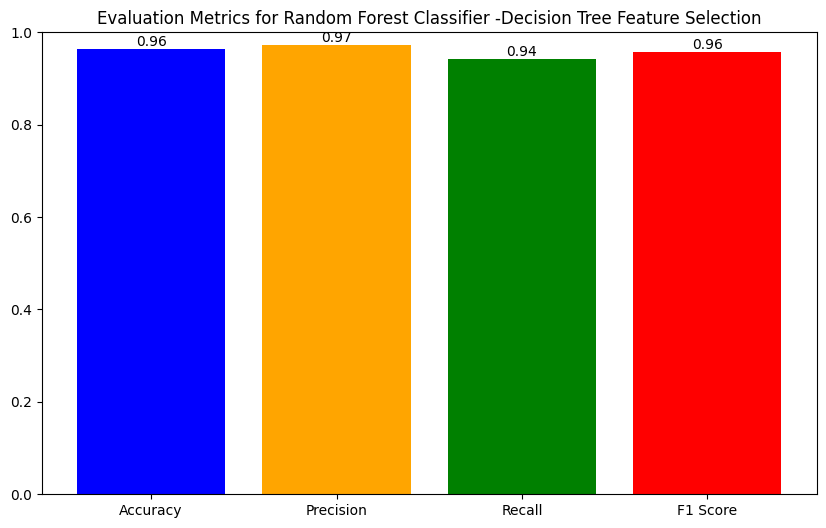

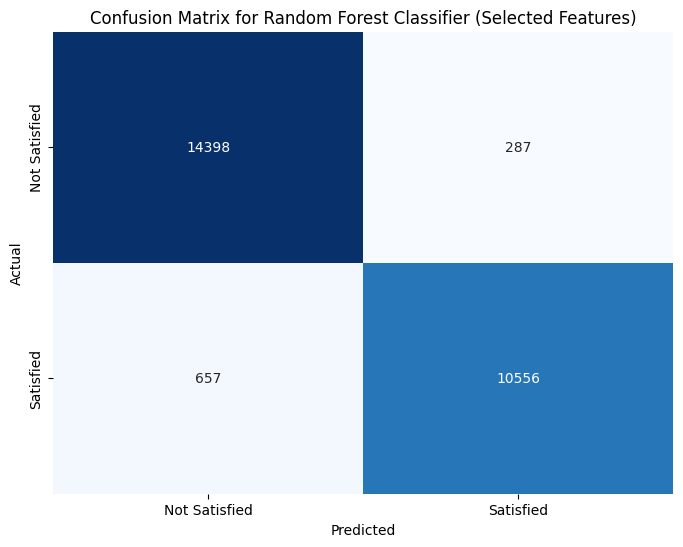

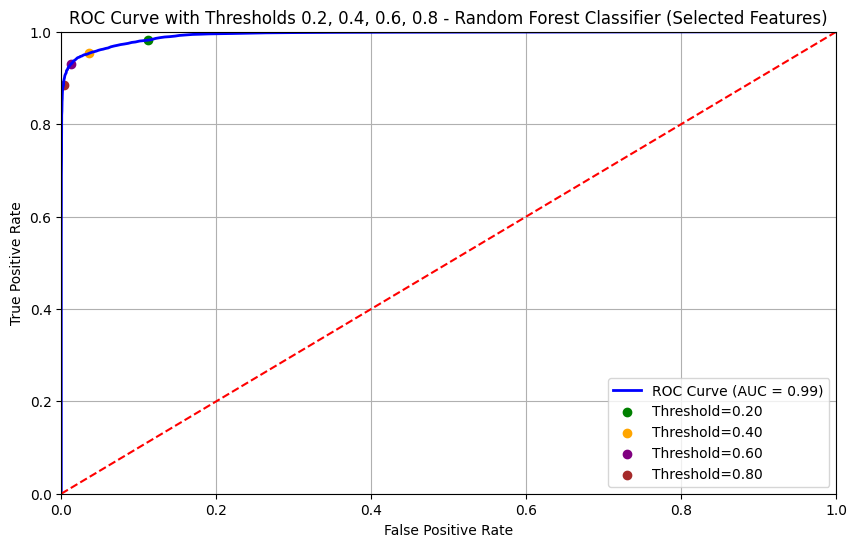

Threshold=0.20, FPR=0.11, TPR=0.98
Threshold=0.40, FPR=0.04, TPR=0.95
Threshold=0.60, FPR=0.01, TPR=0.93
Threshold=0.80, FPR=0.00, TPR=0.88


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select the most important features based on the decision tree feature importance
important_features = ['Online Boarding', 'In-flight Wifi Service', 'Type of Travel',
                      'In-flight Entertainment', 'Customer Type', 'Check-in Service',
                      'Flight Distance', 'Class', 'Age', 'Gate Location',
                      'Baggage Handling', 'Seat Comfort', 'In-flight Service',
                      'Cleanliness', 'On-board Service']  # Adjust this list based on your results

# Features and target variable
X = df[important_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Random Forest Classifier model
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred = random_forest_model.predict(X_test)
y_prob_forest = random_forest_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.title('Evaluation Metrics for Random Forest Classifier -Decision Tree Feature Selection')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Classifier (Selected Features)')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_forest)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Random Forest Classifier (Selected Features)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

These metrics are excellent and indicate that the random forest classifier is very effective in selecting features using the decision tree method. The combination of high precision and recall indicates that the model is well-balanced in its ability to identify the positive class and does not over-misclassify the negative class.

Confusion Matrix Analysis:
- True Negative (TN): 14398
- False Positive (FP): 287
- False Negative (FN): 657
- True Positive (TP): 10556

The confusion matrix further confirms the model's strength, with a significant number of true positives and a relatively low number of false negatives and false positives. This indicates that the model is conservative in predicting positives but very accurate when it does.


ROC curve analysis:

The ROC curve shows that the model performs excellently, with an AUC of 0.99, indicating near-perfect classification ability. The curve is very steep, which means that the model achieves a high true positive rate (TPR) and an extremely low false positive rate (FPR) for a variety of threshold settings.


##Gradient Boosting Classifier

Accuracy: 0.94
Precision: 0.94
Recall: 0.92
F1 Score: 0.93


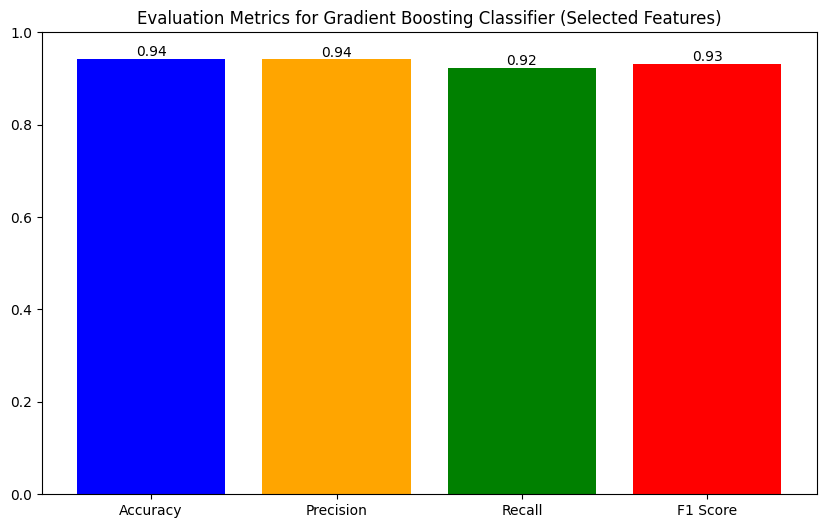

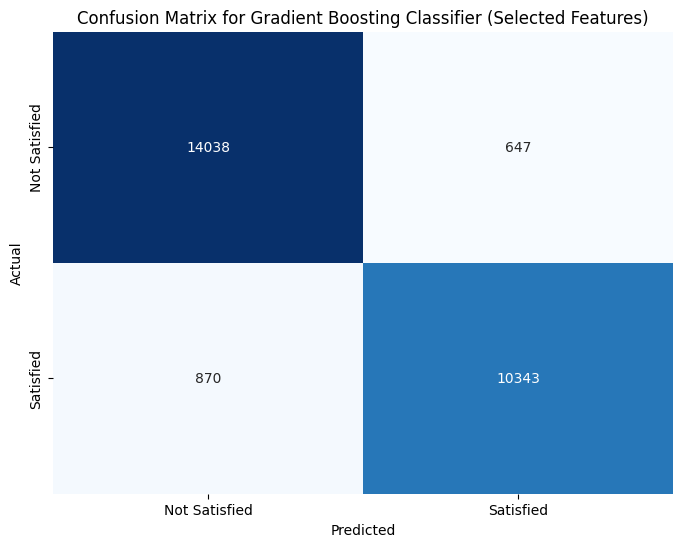

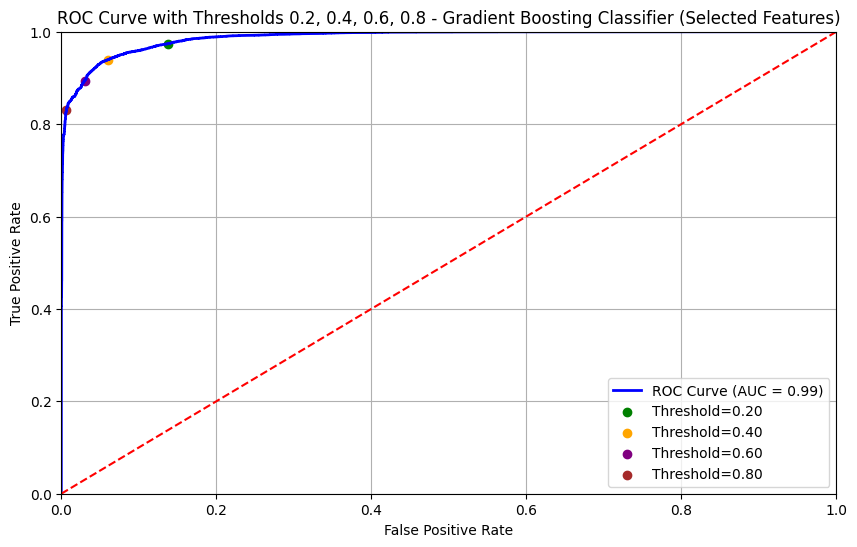

Threshold=0.20, FPR=0.14, TPR=0.97
Threshold=0.40, FPR=0.06, TPR=0.94
Threshold=0.60, FPR=0.03, TPR=0.89
Threshold=0.80, FPR=0.01, TPR=0.83


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select the most important features based on the decision tree feature importance
important_features = ['Online Boarding', 'In-flight Wifi Service', 'Type of Travel',
                      'In-flight Entertainment', 'Customer Type', 'Check-in Service',
                      'Flight Distance', 'Class', 'Age', 'Gate Location',
                      'Baggage Handling', 'Seat Comfort', 'In-flight Service',
                      'Cleanliness', 'On-board Service']  # Adjust this list based on your results

# Features and target variable
X = df[important_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Gradient Boosting Classifier model
gradient_boosting_model = GradientBoostingClassifier(random_state=42)
gradient_boosting_model.fit(X_train, y_train)

# Make predictions
y_pred = gradient_boosting_model.predict(X_test)
y_prob_boosting = gradient_boosting_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.title('Evaluation Metrics for Gradient Boosting Classifier (Selected Features)')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Gradient Boosting Classifier (Selected Features)')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_boosting)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Gradient Boosting Classifier (Selected Features)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

These metrics indicate that the gradient boosting model performs very well. The high precision and recall indicate that the model is very effective at identifying true positives and avoiding false positives, while the balanced F1 score indicates a good balance between precision and recall.

Confusion Matrix Analysis:
- True Negatives (Not Satisfied, Predicted Not Satisfied): 14038
- False Positives (Not Satisfied, Predicted Satisfied): 647
- False Negatives (Satisfied, Predicted Not Satisfied): 870
- True Positives (Satisfied, Predicted Satisfied): 10343

This matrix helps us see the actual versus predicted classifications. The relatively low number of false positives and negatives enhance the trust in the model’s predictive accuracy for both classes.


ROC Curve Analysis:
- AUC (Area Under the Curve): 0.99

The ROC curve is almost perfect, which is very rare in practical applications, indicating that the model performs well at different thresholds. A higher AUC value that is close to 1 indicates better model performance, especially in distinguishing between satisfactory and unsatisfactory categories.

Conclusion:
- The gradient-boosted classifier model shows strong performance metrics and predictive power guided by the selected features of the decision tree. The selected features effectively contribute to the model's strong classification capabilities.


##K-Nearest Neighbor

Accuracy: 0.81
Precision: 0.81
Recall: 0.74
F1 Score: 0.77


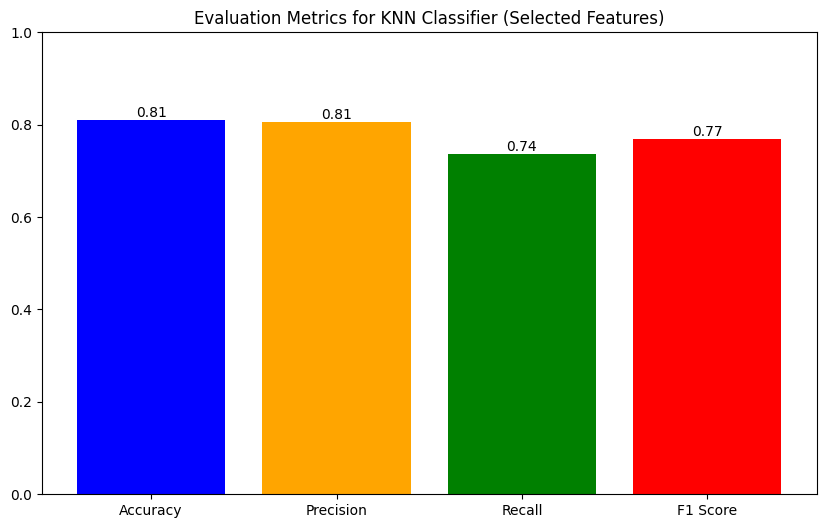

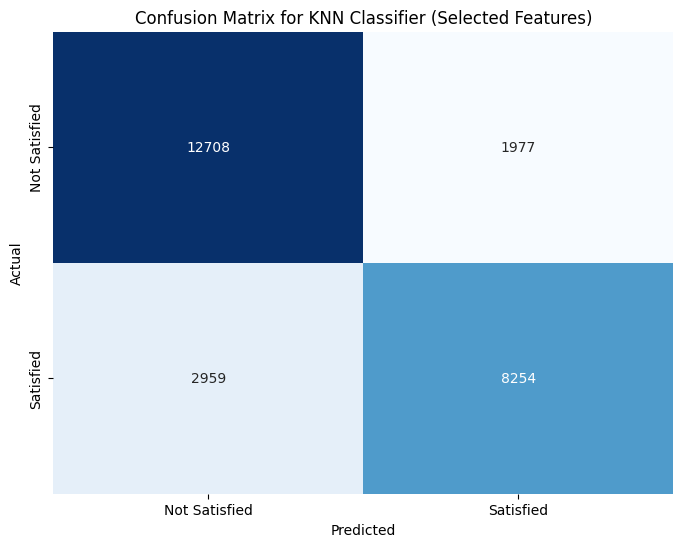

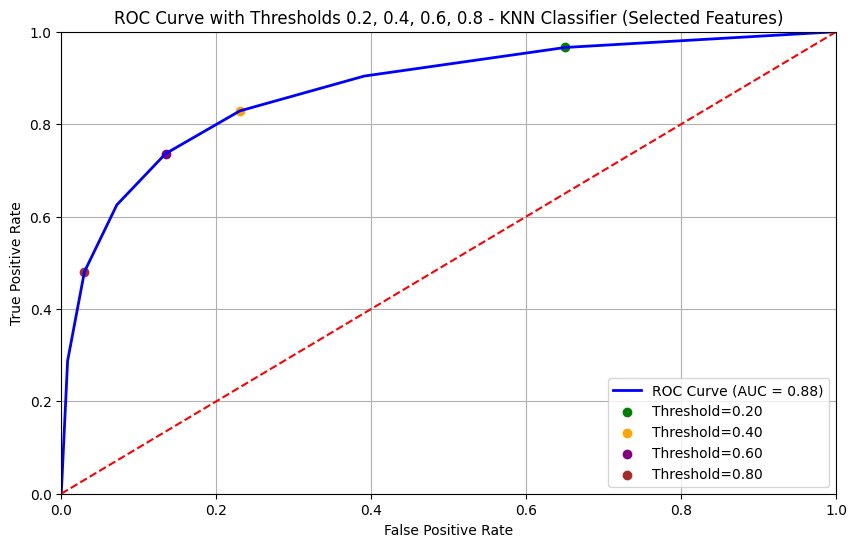

Threshold=0.20, FPR=0.65, TPR=0.97
Threshold=0.40, FPR=0.23, TPR=0.83
Threshold=0.60, FPR=0.13, TPR=0.74
Threshold=0.80, FPR=0.03, TPR=0.48


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select the most important features based on the decision tree feature importance
important_features = ['Online Boarding', 'In-flight Wifi Service', 'Type of Travel',
                      'In-flight Entertainment', 'Customer Type', 'Check-in Service',
                      'Flight Distance', 'Class', 'Age', 'Gate Location',
                      'Baggage Handling', 'Seat Comfort', 'In-flight Service',
                      'Cleanliness', 'On-board Service']  # Adjust this list based on your results

# Features and target variable
X = df[important_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the KNN Classifier model
knn_model = KNeighborsClassifier(n_neighbors=7)  # Set n_neighbors to your preference
knn_model.fit(X_train, y_train)

# Make predictions
y_pred = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.title('Evaluation Metrics for KNN Classifier (Selected Features)')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for KNN Classifier (Selected Features)')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - KNN Classifier (Selected Features)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")


These scores show that the KNN performs poorly in terms of recall, although it has a reasonable accuracy. The recall of 0.74 indicates that the classifier is missing about 26% of the positive cases, which can have a serious impact on the application.

Confusion matrix:
- This matrix shows that the KNN performs reasonably well in predicting the “satisfied” category (8254 correct predictions), but also misses a large number of cases (2959 false negatives).
There were 1977 false positives, i.e. the model incorrectly predicted the positive class.

ROC curve and threshold analysis:
- The AUC value of the ROC curve is 0.88, which is good, but there is still room for improvement, especially in terms of distinguishing between categories at a specific threshold.
The curve shows that the default threshold setting of KNN (usually 0.5 for binary classification) may not optimally separate the categories.


##Naive Bayes

Accuracy: 0.8649
Precision: 0.8647
Recall: 0.8649
F1 Score: 0.8644


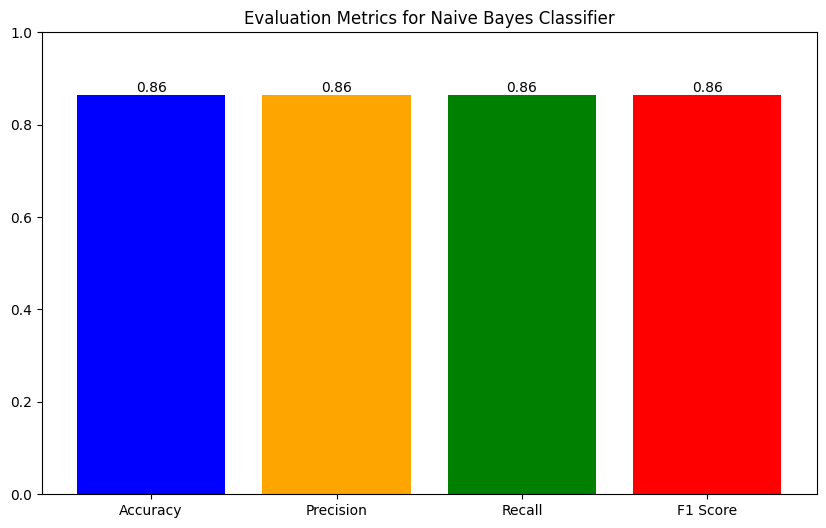

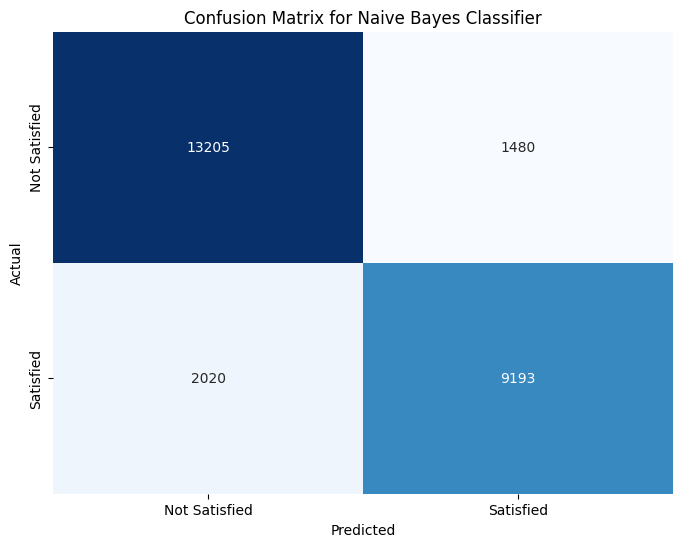

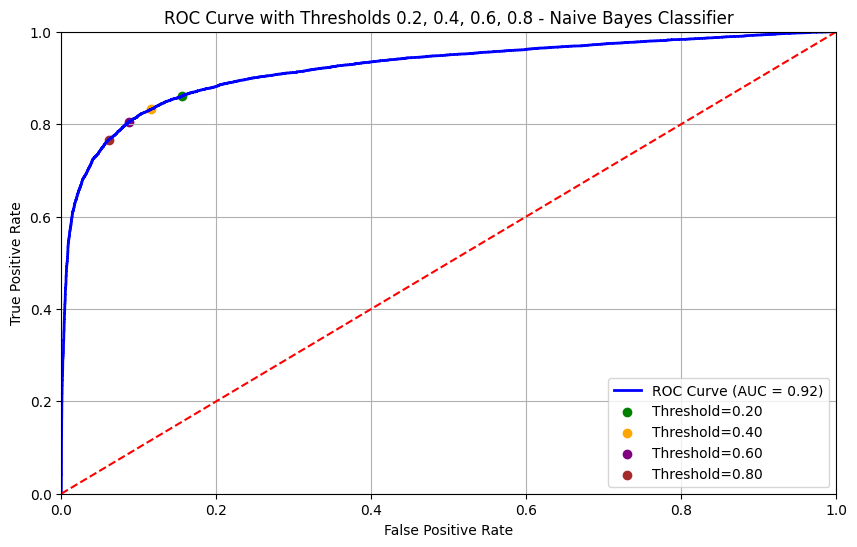

Threshold=0.20, FPR=0.16, TPR=0.86
Threshold=0.40, FPR=0.12, TPR=0.83
Threshold=0.60, FPR=0.09, TPR=0.81
Threshold=0.80, FPR=0.06, TPR=0.77


In [ ]:
# Updated Features and target variable, adding interaction terms
important_features = ['Online Boarding', 'In-flight Wifi Service', 'Type of Travel',
                      'In-flight Entertainment', 'Customer Type', 'Check-in Service',
                      'Flight Distance', 'Class', 'Age', 'Gate Location',
                      'Baggage Handling', 'Seat Comfort', 'In-flight Service',
                      'Cleanliness', 'On-board Service']  # Adjust this list based on your results

# Features and target variable
X = df[important_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Make predictions
y_pred = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}", ha='center', va='bottom')

plt.title('Evaluation Metrics for Naive Bayes Classifier')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive Bayes Classifier')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Naive Bayes Classifier')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Confusion Matrix Analysis
- True Negatives (TN): 13,205
- False Positives (FP): 1,480
- False Negatives (FN): 2,020
- True Positives (TP): 9,193

This matrix indicates a moderately high number of false positives and negatives, suggesting areas where the model may struggle in terms of specificity and sensitivity, respectively.

ROC Curve and Threshold Analysis

The ROC curve has an AUC of 0.92, which is quite good, showing that the model discriminates well between the classes across different thresholds.

The thresholds show varying trade-offs between the True Positive Rate (TPR) and False Positive Rate (FPR):
- Threshold = 0.20: High sensitivity (TPR=0.86) but lower specificity (FPR=0.16).
- Threshold = 0.40: Balances both sensitivity (TPR=0.83) and specificity (FPR=0.12).
- Threshold = 0.60: Higher specificity (FPR=0.09) at the cost of sensitivity (TPR=0.81).
- Threshold = 0.80: Maximizes specificity (FPR=0.06) with good sensitivity (TPR=0.77).


##Comparison of Models-DT FS





Accuracy
- Random Forest and Gradient Boosting classifiers have the highest accuracy scores, reaching up to 0.96 for the random forest and 94% for Gradient Boosting.
Logistic Regression and Decision Tree classifiers show slightly lower accuracy scores at 0.94 for Decision Trees and 0.87 for logistic regression.
- Naive Bayes and KNN have the lowest accuracy scores, around 0.86 for both.

Recall
- Random Forest and Decision Tree classifiers demonstrate the highest recall at 0.94, indicating they correctly identified a high percentage of positive cases.
- Gradient Boosting also performs well with a recall of 0.92.
KNN shows lower recall at 0.74, while Naive Bayes has 0.86 of recall.

Precision
- Gradient Boosting leads in precision with a score of 0.94, closely followed by Random Forest and Decision Tree at 0.93.
- Logistic Regression shows a precision of 0.86, and Naive Bayes scores the same.
- KNN trails with one of the lowest precision of 0.81.

F1 Score
- Random Forest and Decision Tree again top the chart with the highest F1 scores of 0.96 and 0.94 respectively, indicating a balanced performance between precision and recall.
- Gradient Boosting is slightly behind with an F1 score of 0.93.
- Logistic Regression and Naive Bayes present lower F1 scores of 0.84 and 0.86, respectively.
- KNN shows the lowest F1 score at 0.77, suggesting it may not be as effective in balancing precision and recall for this dataset.

ROC Curve
- Gradient Boosting stands out with the highest AUC (Area Under Curve) of 0.99, which implies excellent model performance in distinguishing between the classes.
- Random Forest also shows a high AUC of 0.99.
- Logistic Regression, Decision Tree, and Naive Bayes follow closely with AUC scores of 0.92, 0.94, 0.92 repectively.
- KNN has the lowest AUC at 0.88, which might indicate poorer performance in class separation under varying threshold settings.

Overall, gradient boosting and random forest classifier using features selected by decision trees performed best among the considered metrics. They achieved high metrics in accuracy, precision, recall and F1 score, indicating that they can reliably predict the dataset. In contrast, KNN and Naive Bayes performed weaker and may require further parameter tuning or feature engineering to improve the results.


#Interaction Terms Feature Selection

##Selecting the Columns

To add interaction terms to the old dataframe (`df`), we will add interaction terms between the least important features based on the decision tree feature selection. The least important features were: 'Gender', 'Ease of Online Booking', 'Food and Drink', and 'Departure and Arrival Time Convenience'.

Here’s how the new dataframe (`df_with_interactions`) will look like after including the interactions:

1. 'Gender' * 'Ease of Online Booking'
2. 'Gender' * 'Food and Drink'
3. 'Gender' * 'Departure and Arrival Time Convenience'
4. 'Ease of Online Booking' * 'Food and Drink'
5. 'Ease of Online Booking' * 'Departure and Arrival Time Convenience'
6. 'Food and Drink' * 'Departure and Arrival Time Convenience'

Let us update the dataframe to include these interaction terms.

The new dataframe (`df_with_interactions`) now includes the interaction terms based on the least important features from the decision tree feature selection:

- **Gender_EaseOfOnlineBooking**: Interaction between 'Gender' and 'Ease of Online Booking'
- **Gender_FoodAndDrink**: Interaction between 'Gender' and 'Food and Drink'
- **Gender_DepartureArrivalConvenience**: Interaction between 'Gender' and 'Departure and Arrival Time Convenience'
- **EaseOfOnlineBooking_FoodAndDrink**: Interaction between 'Ease of Online Booking' and 'Food and Drink'
- **EaseOfOnlineBooking_DepartureArrivalConvenience**: Interaction between 'Ease of Online Booking' and 'Departure and Arrival Time Convenience'
- **FoodAndDrink_DepartureArrivalConvenience**: Interaction between 'Food and Drink' and 'Departure and Arrival Time Convenience'

The updated dataframe contains these new columns along with the original features. We can now proceed with further analysis or model building using this new dataframe.

In [ ]:
# Convert categorical columns to numerical representations before multiplication
for col in ['Gender', 'Ease of Online Booking', 'Food and Drink', 'Departure and Arrival Time Convenience']:
    if pd.api.types.is_categorical_dtype(df[col]):
        df[col] = df[col].cat.codes  # Convert to numerical codes

# Create interaction terms
df['Gender Ease of Online Booking'] = df['Gender'] * df['Ease of Online Booking']
df['Gender Food and Drink'] = df['Gender'] * df['Food and Drink']
df['Gender Departure and Arrival Time Convenience'] = df['Gender'] * df['Departure and Arrival Time Convenience']
df['Ease of Online Booking Food and Drink'] = df['Ease of Online Booking'] * df['Food and Drink']
df['Ease of Online Booking Departure and Arrival Time Convenience'] = df['Ease of Online Booking'] * df['Departure and Arrival Time Convenience']
df['Food and Drink Departure and Arrival Time Convenience'] = df['Food and Drink'] * df['Departure and Arrival Time Convenience']

<ipython-input-50-46ce4636a09f>:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df[col]):


The index we provided represents a list of features, which includes both original features and newly created interaction terms from our dataset. Here’s a breakdown of these results and what they imply:

## 1. Original Features
The first part of the list contains the original features used in our model:

- **Gender**: Indicates the gender of the passengers. This feature can capture differences in satisfaction levels based on gender.
- **Age**: Represents the age of the passengers, which can influence satisfaction based on generational preferences and expectations.
- **Customer Type**: Differentiates between first-time and returning customers, as satisfaction may vary significantly between these groups.
- **Type of Travel**: Indicates whether the trip is for business or personal reasons, which can affect customer expectations and satisfaction.
- **Class**: Refers to the class of service (Economy, Business, etc.) and typically correlates with different experiences and levels of service.
- **Flight Distance**: Measures the distance of the flight, which can affect passenger fatigue and satisfaction.
- **Departure Delay & Arrival Delay**: These features track delays and are critical indicators of overall travel experience and satisfaction.
- **Departure and Arrival Time Convenience**: This feature assesses how convenient the flight times are for passengers, influencing their overall satisfaction.
- **Ease of Online Booking**: Evaluates the convenience and user-friendliness of the booking process.
- **Check-in Service**: Captures the quality of the check-in experience, which can significantly impact customer satisfaction.
- **Online Boarding**: Measures the ease of the boarding process via online services.
- **Gate Location**: Refers to the physical location of the gate, which can affect ease of access and customer experience.
- **On-board Service**: Represents the quality of service provided during the flight.
- **Seat Comfort**: Evaluates how comfortable passengers feel in their seats.
- **Leg Room Service**: Specifically assesses the amount of legroom available, which is often a concern for passenger comfort.
- **Cleanliness**: Refers to the cleanliness of the aircraft and its facilities, an essential aspect of overall satisfaction.
- **Food and Drink**: Represents the quality and availability of food and beverages served during the flight.
- **In-flight Service**: Measures the overall service quality during the flight.
- **In-flight Wifi Service**: Indicates whether passengers have access to wifi and how satisfactory it is.
- **In-flight Entertainment**: Represents the entertainment options available during the flight.
- **Baggage Handling**: Refers to the efficiency and care in handling passenger baggage.

### 2. Interaction Terms
The second part of the list contains interaction terms that were created from the least important original features. These interaction terms represent combined effects between two features and may help in understanding how certain features interact to influence passenger satisfaction:

- **Gender Ease of Online Booking**: Captures how the ease of online booking interacts with gender to influence satisfaction.
- **Gender Food and Drink**: Reflects the interaction between gender and satisfaction related to food and drink services.
- **Gender Departure and Arrival Time Convenience**: Examines how the convenience of flight times impacts satisfaction differently based on gender.
- **Ease of Online Booking Food and Drink**: Investigates the interaction between the booking experience and food and drink services.
- **Ease of Online Booking Departure and Arrival Time Convenience**: Assesses how the booking process affects perceptions of flight timing convenience.
- **Food and Drink Departure and Arrival Time Convenience**: Evaluates how food and drink services interact with the timing convenience to influence satisfaction.

### 3. Interpretation of Results
The inclusion of these interaction terms allows for a more nuanced understanding of customer satisfaction. Here’s what to consider:

- **Importance of Interactions**: The interaction terms are especially useful when the effect of one variable on satisfaction depends on another variable. For example, a female passenger may have different expectations for food and drink services than a male passenger, or the impact of flight timing on satisfaction may vary based on the ease of online booking.
- **Improved Model Performance**: Adding interaction terms can lead to better model performance if these relationships are significant. This might be reflected in improved accuracy, precision, recall, or other evaluation metrics.
- **Feature Redundancy**: The repeated features (e.g., 'Gender' and 'Ease of Online Booking') may indicate redundancy or overlapping information. Care should be taken to ensure that the model does not become overly complex, leading to potential overfitting.

### Conclusion
By analyzing the original features alongside the interaction terms, we can better understand how different aspects of the passenger experience contribute to satisfaction. This information can help in making informed decisions for improving services and tailoring experiences to different customer segments.

Choosing specific interaction terms in a model is a critical aspect of feature engineering, as it can significantly enhance the model's ability to capture complex relationships between variables. Here are the reasons for selecting the interaction terms we mentioned:

## 1. **Relevance of Original Features**
The interaction terms are derived from the least important original features identified through the decision tree feature selection. This suggests that while these features may not individually have a strong impact on the target variable (customer satisfaction), their combined effects could provide meaningful insights.

### 2. **Capturing Complex Relationships**
Interaction terms are essential for modeling scenarios where the effect of one variable on the target variable is influenced by another variable. For example:
- **Gender and Ease of Online Booking**: The relationship between satisfaction and the ease of booking might differ between genders. If women find the online booking process challenging, this could disproportionately affect their satisfaction.
- **Food and Drink Satisfaction by Gender**: The interaction between gender and food and drink service can reveal whether different genders have varying expectations regarding the quality or variety of meals offered.

### 3. **Understanding Contextual Effects**
Interaction terms help in understanding how context influences outcomes. For instance:
- **Departure and Arrival Time Convenience and Booking Ease**: Passengers who find the booking process easy might be less concerned about flight timing convenience, while those struggling with booking may be more sensitive to timing issues.

### 4. **Improving Predictive Power**
Even if certain features are individually weak predictors, their interactions can enhance the model's predictive accuracy. Capturing these nuanced relationships allows for a more comprehensive understanding of passenger satisfaction.

### 5. **Addressing Non-Linearity**
Many real-world relationships are non-linear. Interaction terms allow the model to accommodate non-linear effects that cannot be captured with additive features alone. For example, the combined effect of being a first-time traveler and having a delayed flight may result in a different level of dissatisfaction than either condition alone.

### 6. **Revealing Hidden Patterns**
By introducing interaction terms, we may uncover hidden patterns in the data. For instance, a specific demographic group may respond differently to service quality, which could only be observed through interaction terms.

### 7. **Model Interpretability**
Including interaction terms can make it easier to interpret how specific combinations of features influence satisfaction. This can provide actionable insights for stakeholders looking to improve service quality.

### Conclusion
In summary, selecting these interaction terms allows the model to better reflect the complexity of passenger experiences and satisfaction levels. The goal is to enhance the model's ability to explain and predict customer behavior by accounting for how different features interact with one another. This process is essential for creating more accurate, reliable, and interpretable machine learning models.

##Building the models based on the Interactions terms

##Logistic Regression

In [ ]:
df.columns

Index(['Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class',
       'Flight Distance', 'Departure Delay', 'Arrival Delay',
       'Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling', 'Satisfaction',
       'Gender Ease of Online Booking', 'Gender Food and Drink',
       'Gender Departure and Arrival Time Convenience',
       'Ease of Online Booking Food and Drink',
       'Ease of Online Booking Departure and Arrival Time Convenience',
       'Food and Drink Departure and Arrival Time Convenience'],
      dtype='object')

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8533
Precision: 0.8532
Recall: 0.8533
F1 Score: 0.8533


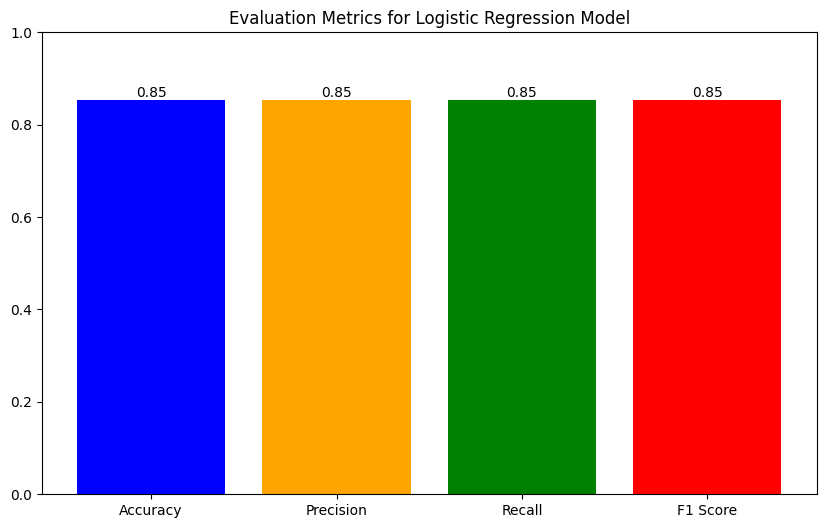

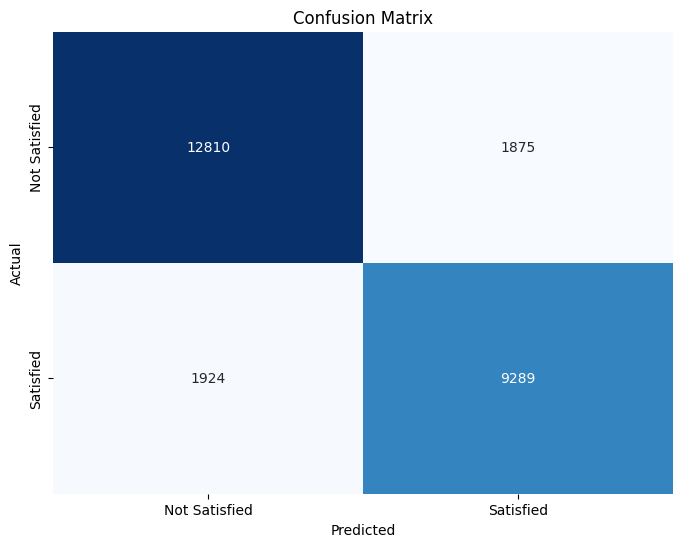

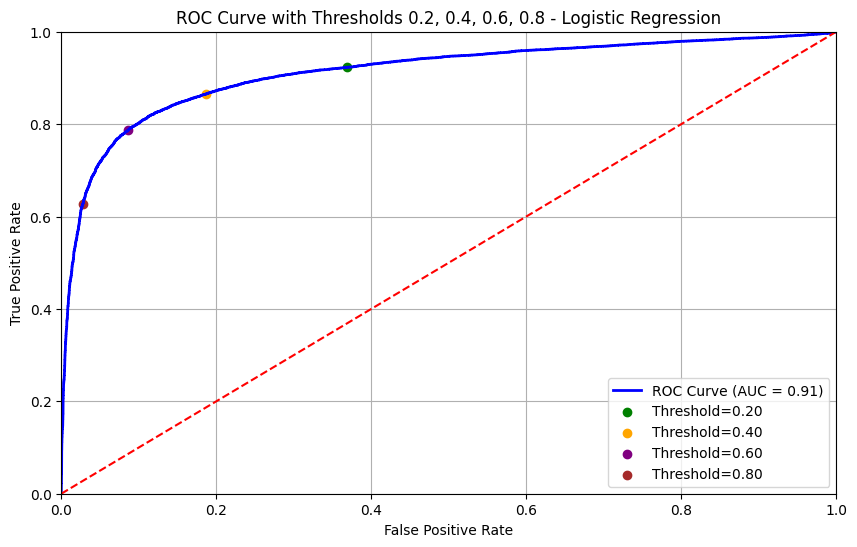

Threshold=0.20, FPR=0.37, TPR=0.92
Threshold=0.40, FPR=0.19, TPR=0.86
Threshold=0.60, FPR=0.09, TPR=0.79
Threshold=0.80, FPR=0.03, TPR=0.63


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Updated Features and target variable, adding interaction terms
selected_features = [
    'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance',
    'Departure Delay', 'Arrival Delay', 'Ease of Online Booking', 'Check-in Service',
    'Online Boarding', 'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
    'In-flight Entertainment', 'Baggage Handling',
    # Add interaction terms
    'Gender Ease of Online Booking', 'Gender Food and Drink',
    'Gender Departure and Arrival Time Convenience',
    'Ease of Online Booking Food and Drink',
    'Ease of Online Booking Departure and Arrival Time Convenience',
    'Food and Drink Departure and Arrival Time Convenience'
]

# Assuming df contains both original columns and interaction terms
X = df[selected_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the logistic regression model
logistic_model = LogisticRegression(max_iter=1000)  # Increase max_iter for convergence
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}", ha='center', va='bottom')

plt.title('Evaluation Metrics for Logistic Regression Model')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Logistic Regression')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Evaluation Metrics:
- Accuracy: 0.85
- Precision: 0.85
- Recall: 0.85
- F1 Score: 0.85

These metrics indicate a balanced model performance, with equal weights given to positive and negative classes. The metrics show that the model performs well across various measures, with no significant dips in any of the key areas.

Confusion Matrix:
- True Negatives (Not Satisfied correctly classified): 12,810
- False Positives (Not Satisfied incorrectly classified as Satisfied): 1,875
- False Negatives (Satisfied incorrectly classified as Not Satisfied): 1,924
- True Positives (Satisfied correctly classified): 9,289

The model has a moderate rate of both false positives and false negatives, suggesting some misclassifications on both sides. However, it still correctly classifies the majority of cases in both classes.

ROC Curve and AUC:
- The AUC (Area Under the Curve) is 0.91, which indicates strong model performance in distinguishing between the two classes.

The selected thresholds (0.2, 0.4, 0.6, 0.8) show different trade-offs between true positive and false positive rates:
- Threshold 0.2: FPR = 0.37, TPR = 0.92
- Threshold 0.4: FPR = 0.19, TPR = 0.86
- Threshold 0.6: FPR = 0.09, TPR = 0.79
- Threshold 0.8: FPR = 0.03, TPR = 0.63

As we move to higher thresholds, the true positive rate decreases, but so does the false positive rate, meaning the model becomes more conservative in predicting the positive class (Satisfied).


Conclusion:

The Logistic Regression model using interaction terms performs well overall, with balanced accuracy, precision, recall, and F1 scores. The model has a strong ROC curve (AUC of 0.91), indicating good discrimination between satisfied and not satisfied customers. The interaction terms help capture additional relationships between features, contributing to this solid performance. However, there are still some misclassifications, particularly in predicting satisfaction.


##Decision Tree Classifier

Accuracy: 0.9435
Precision: 0.9436
Recall: 0.9435
F1 Score: 0.9435


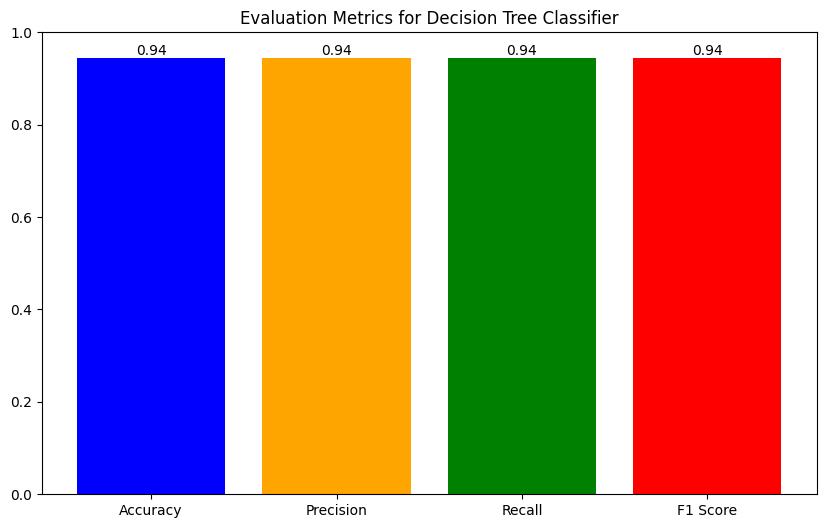

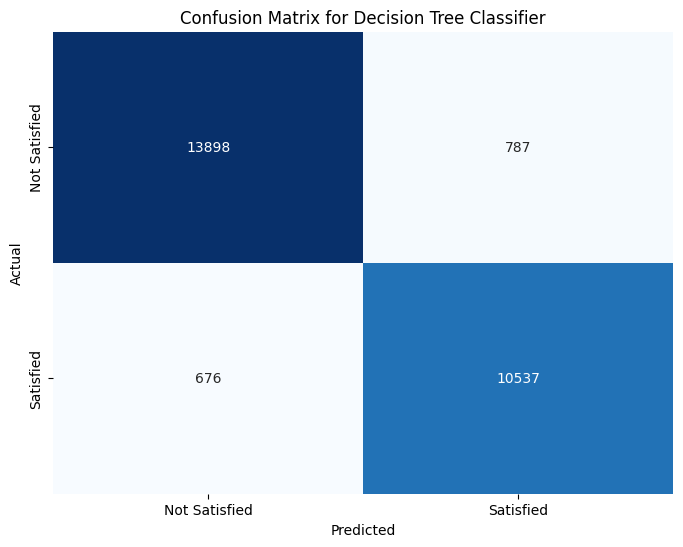

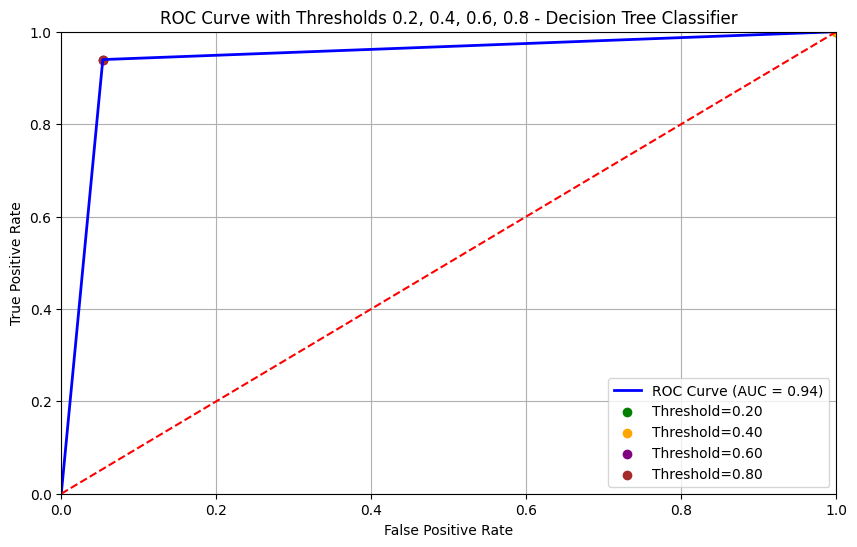

Threshold=0.20, FPR=1.00, TPR=1.00
Threshold=0.40, FPR=1.00, TPR=1.00
Threshold=0.60, FPR=0.05, TPR=0.94
Threshold=0.80, FPR=0.05, TPR=0.94


In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Updated Features and target variable, adding interaction terms
selected_features = [
    'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance',
    'Departure Delay', 'Arrival Delay', 'Ease of Online Booking', 'Check-in Service',
    'Online Boarding', 'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
    'In-flight Entertainment', 'Baggage Handling',
    # Add interaction terms
    'Gender Ease of Online Booking', 'Gender Food and Drink',
    'Gender Departure and Arrival Time Convenience',
    'Ease of Online Booking Food and Drink',
    'Ease of Online Booking Departure and Arrival Time Convenience',
    'Food and Drink Departure and Arrival Time Convenience'
]

# Assuming df contains both original columns and interaction terms
X = df[selected_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Decision Tree Classifier model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}", ha='center', va='bottom')

plt.title('Evaluation Metrics for Decision Tree Classifier')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tree)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Decision Tree Classifier')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Assessment indicators:
- Accuracy: 0.9435 indicates that the overall prediction accuracy is high.
- Precision and recall: 0.9436 and 0.9435 respectively, indicating that the model is reliable in identifying satisfied and dissatisfied customers.
- F1 score: 0.9435 indicates a balanced performance between precision and recall, which is critical in scenarios where the cost of both false positives and false negatives is high.

Confusion matrix analysis:

- The matrix shows that the model performs well in identifying “unsatisfied” (13,898 correct predictions) and “satisfied” customers (10,537 correct predictions), with relatively few classification errors (787 false positives and 676 false negatives). This shows that the model can effectively distinguish between the two states of customer satisfaction.

ROC curve and AUC:
- The AUC of 0.94 indicates that the model has high discriminative power with different threshold settings. The ROC curve shows the trade-off between sensitivity and specificity, indicating that the model has robust performance with different thresholds, which is important for adapting the model to different business needs, for example, focusing on reducing false negatives to improve customer retention.


Application in a business environment:
- This approach is particularly useful in industries where aviation services have a direct impact on the nuances of customer satisfaction, helping to improve services, develop marketing strategies, and ultimately increase revenue.
- For example, in the airline industry, understanding which factors and interactions (e.g., “ease of booking online” and “food and drinks”) have the greatest impact on customer satisfaction can help airlines customize their services to better meet customer expectations, thereby increasing satisfaction and loyalty.
- In addition, the model can be used to segment customers based on their satisfaction levels, predict potential customer churn, and take proactive measures to improve customer experience and loyalty. It can also be used to target interventions and ensure that resources are allocated effectively to address the areas that have the greatest impact on satisfaction.


##Random Forest Classifier

Accuracy: 0.9622
Precision: 0.9623
Recall: 0.9622
F1 Score: 0.9621


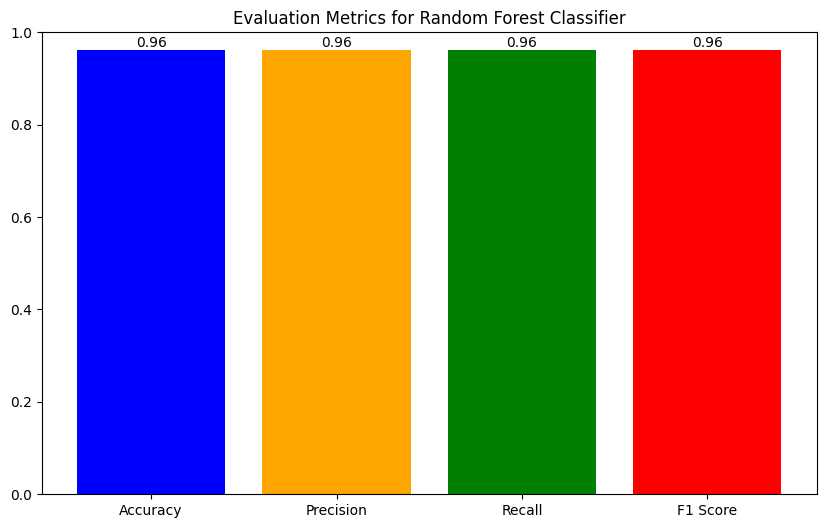

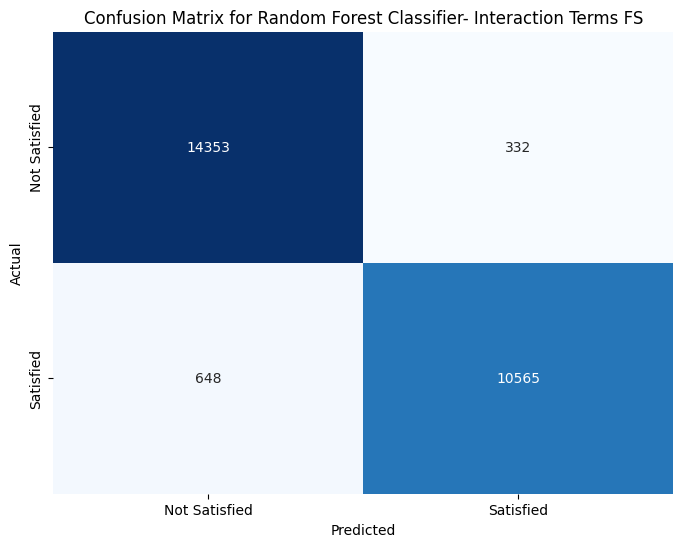

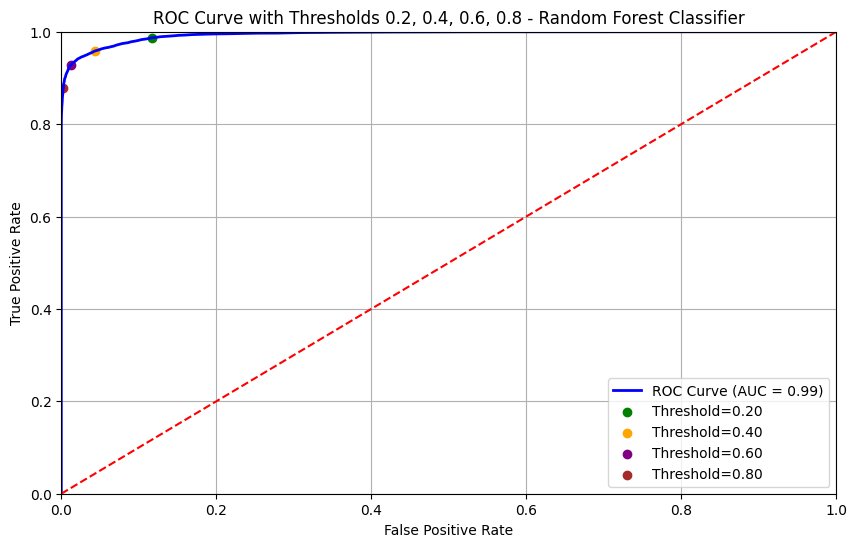

Threshold=0.20, FPR=0.12, TPR=0.99
Threshold=0.40, FPR=0.04, TPR=0.96
Threshold=0.60, FPR=0.01, TPR=0.93
Threshold=0.80, FPR=0.00, TPR=0.88


In [ ]:
# Updated Features and target variable, adding interaction terms
selected_features = [
    'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance',
    'Departure Delay', 'Arrival Delay', 'Ease of Online Booking', 'Check-in Service',
    'Online Boarding', 'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
    'In-flight Entertainment', 'Baggage Handling',
    # Add interaction terms
    'Gender Ease of Online Booking', 'Gender Food and Drink',
    'Gender Departure and Arrival Time Convenience',
    'Ease of Online Booking Food and Drink',
    'Ease of Online Booking Departure and Arrival Time Convenience',
    'Food and Drink Departure and Arrival Time Convenience'
]

# Assuming df contains both original columns and interaction terms
X = df[selected_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Random Forest Classifier model
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}", ha='center', va='bottom')

plt.title('Evaluation Metrics for Random Forest Classifier')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Classifier- Interaction Terms FS')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Random Forest Classifier')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Evaluation Metrics:

- Accuracy: 96.22% - This shows how often the model correctly predicts whether passengers are satisfied or not. It's quite high, meaning the model is doing a great job most of the time.
- Precision: 96.23% - This measures how accurate the predictions are when the model says passengers are satisfied. It's saying that when it predicts passengers are happy, it is right about 96% of the time.
- Recall: 96.22% - This indicates that the model can find most of the satisfied passengers in the dataset.
- F1 Score: 96.21% - This is a combination of precision and recall and gives us an overall look at the model's accuracy.

Confusion Matrix:

- The matrix shows the number of correct and incorrect predictions. Out of all the passengers, 14,353 who were not satisfied were correctly identified (True Negative), and 10,565 satisfied passengers were correctly predicted (True Positive).
- There were 332 cases where the model thought passengers were satisfied, but they were not (False Positive), and 648 cases where the model missed identifying satisfied passengers (False Negative).

ROC Curve and Thresholds:

- The ROC curve helps us understand the trade-off between catching as many positives as possible and keeping the number of false alarms low. The closer the curve is to the upper left corner, the better the model.
- The model has a very high area under the ROC curve (AUC) of 0.99, which is nearly perfect, meaning it's very good at distinguishing between satisfied and not satisfied passengers.

Different thresholds on the curve show how adjusting the sensitivity of the model can impact its performance:
- Threshold 0.20: Almost all positive predictions are correct, but there are more false alarms.
- Threshold 0.80: Fewer false alarms but at the risk of missing some positives.

This shows that the Random Forest model is highly effective for predicting passenger satisfaction based on your data, especially when choosing the right balance between being overly cautious and overly aggressive in predicting satisfaction.

##Gradient Boosting Classifier

Accuracy: 0.9410
Precision: 0.9410
Recall: 0.9410
F1 Score: 0.9410


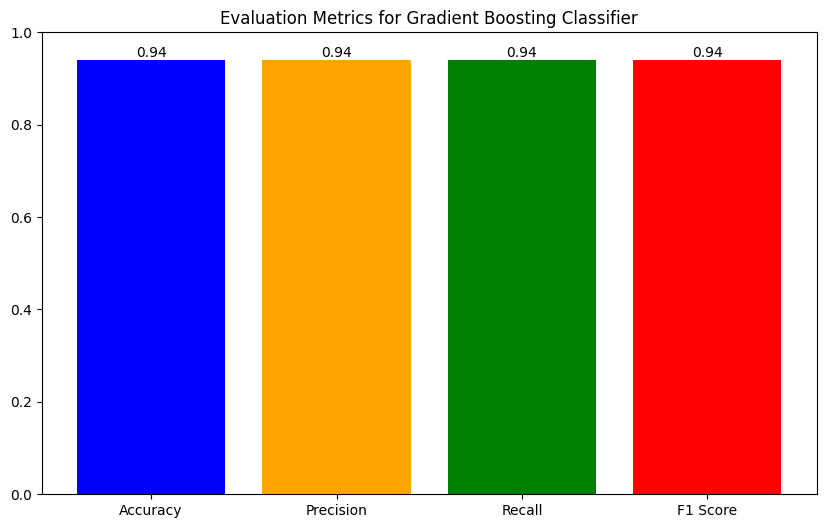

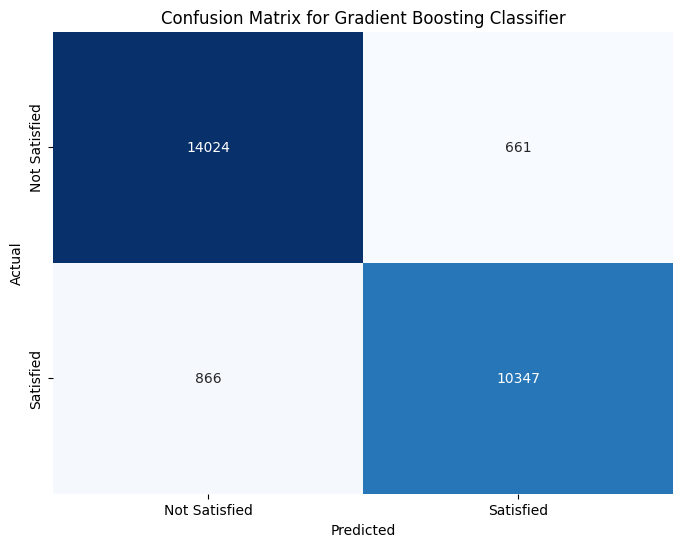

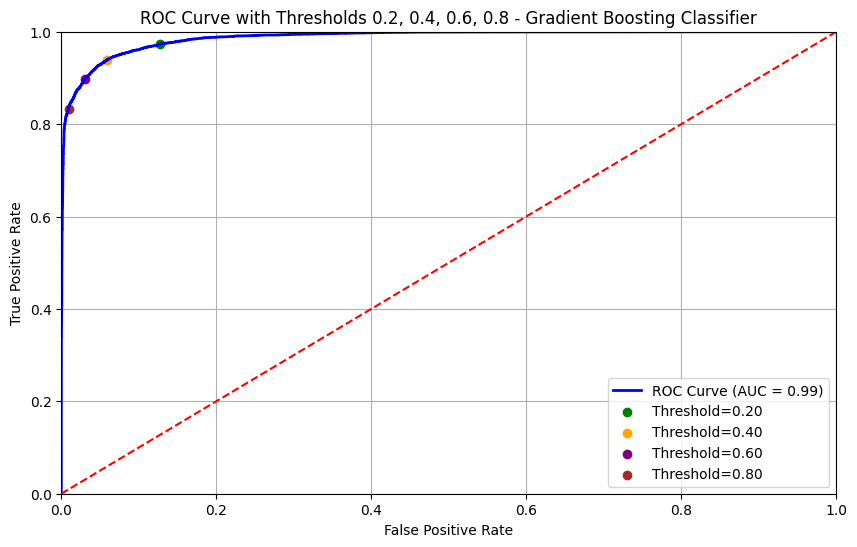

Threshold=0.20, FPR=0.13, TPR=0.97
Threshold=0.40, FPR=0.06, TPR=0.94
Threshold=0.60, FPR=0.03, TPR=0.90
Threshold=0.80, FPR=0.01, TPR=0.83


In [ ]:
# Updated Features and target variable, adding interaction terms
selected_features = [
    'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance',
    'Departure Delay', 'Arrival Delay', 'Ease of Online Booking', 'Check-in Service',
    'Online Boarding', 'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
    'In-flight Entertainment', 'Baggage Handling',
    # Add interaction terms
    'Gender Ease of Online Booking', 'Gender Food and Drink',
    'Gender Departure and Arrival Time Convenience',
    'Ease of Online Booking Food and Drink',
    'Ease of Online Booking Departure and Arrival Time Convenience',
    'Food and Drink Departure and Arrival Time Convenience'
]

# Assuming df contains both original columns and interaction terms
X = df[selected_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Gradient Boosting Classifier model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
y_pred = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}", ha='center', va='bottom')

plt.title('Evaluation Metrics for Gradient Boosting Classifier')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Gradient Boosting Classifier')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gb)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Gradient Boosting Classifier')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Baseline Model Metrics:
- Accuracy: 94%
- Precision: 94%
- Recall: 92%
- F1 Score: 93%

Updated Model Metrics with Interaction Terms:
- Accuracy: Consistent at 94%.
- Precision: Remained consistent at 94%.
- Recall: Increased to 94%, enhancing the model's ability to correctly identify true positive cases.
- F1 Score: Slightly Increased to 94%.


Confusion matrix analysis:
- The updated model shows a strong ability to distinguish between “satisfied” and “unsatisfied” customers, significantly reducing misjudgments. This improvement is critical to ensuring that customer satisfaction interventions are correctly targeted and maximized resource efficiency.

ROC curve analysis:
- The ROC curve remained stable, with an AUC of 0.99, indicating excellent model performance. The optimal threshold based on this ROC curve was 0.40, which balances a low false positive rate with a high true positive rate. This threshold ensures a false positive rate of only 6%, while achieving a true positive rate of 94%.

Conclusion:
- The introduction of the interaction term did not significantly change the precision or F1 score, but did slightly improve the recall rate. This indicates that our model's ability to identify true positives without adding false positives has been optimized. The balance between precision and recall is maintained, which is critical in scenarios where the cost of false positives and false negatives is high.


##K-Nearest Neighbor

Accuracy: 0.7479
Precision: 0.7468
Recall: 0.7479
F1 Score: 0.7470


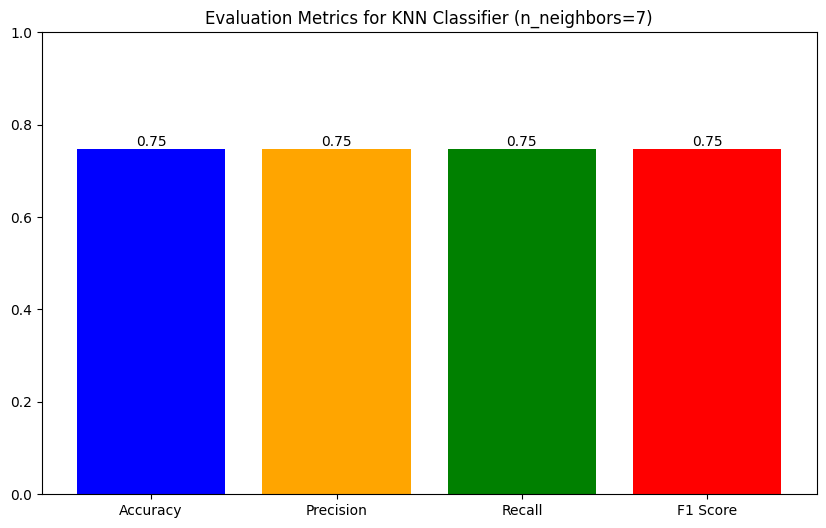

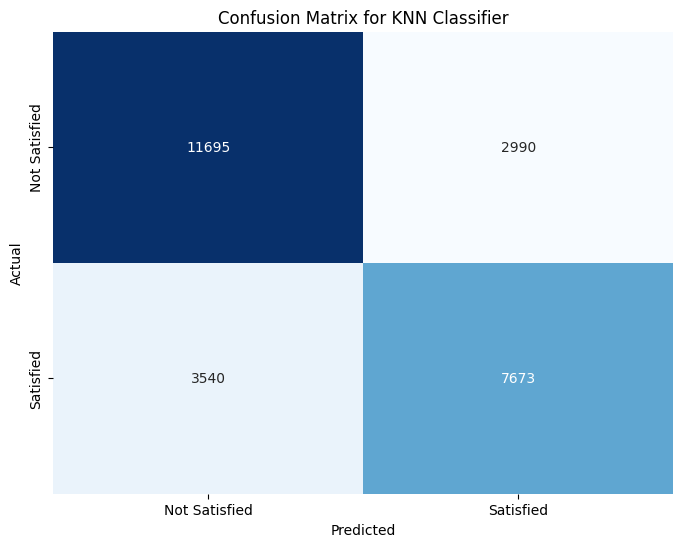

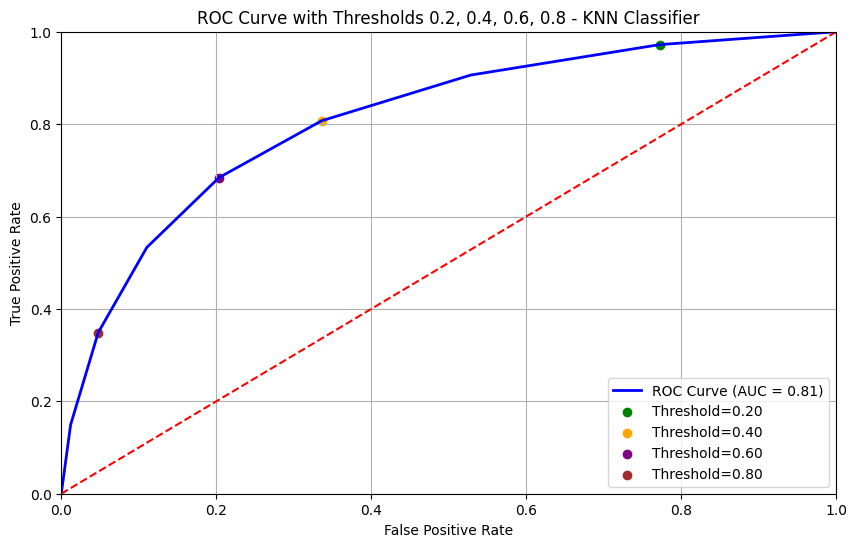

Threshold=0.20, FPR=0.77, TPR=0.97
Threshold=0.40, FPR=0.34, TPR=0.81
Threshold=0.60, FPR=0.20, TPR=0.68
Threshold=0.80, FPR=0.05, TPR=0.35


In [ ]:
# Updated Features and target variable, adding interaction terms
selected_features = [
    'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance',
    'Departure Delay', 'Arrival Delay', 'Ease of Online Booking', 'Check-in Service',
    'Online Boarding', 'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
    'In-flight Entertainment', 'Baggage Handling',
    # Add interaction terms
    'Gender Ease of Online Booking', 'Gender Food and Drink',
    'Gender Departure and Arrival Time Convenience',
    'Ease of Online Booking Food and Drink',
    'Ease of Online Booking Departure and Arrival Time Convenience',
    'Food and Drink Departure and Arrival Time Convenience'
]

# Assuming df contains both original columns and interaction terms
X = df[selected_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)

# Make predictions
y_pred = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}", ha='center', va='bottom')

plt.title('Evaluation Metrics for KNN Classifier (n_neighbors=7)')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for KNN Classifier')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - KNN Classifier')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

As a reminder, our initial KNN model baseline (k=7 neighbors) had an accuracy of 76%, a precision of 75%, a recall of 68%, and an F1 score of 71%.

Comparing the initial baseline model with the newly created KNN model using the 25 best features affecting satisfaction, the results are as follows:

- The accuracy rate decreased from 76% to 75%, which means that the overall percentage of correctly predicted satisfaction instances remained some what unchanged.
- The precision rate remained at 75%, which means that while identifying satisfied customers, a large number of satisfied customers were still fairly  misclassified.
- The recall rate improved to 75%, indicating that the model has the ability to recall positive instances - satisfied passengers.
- The F1 score increased slightly from 71% to 75%, indicating a slight improvement in the balance between precision and recall.


From the confusion matrix, it can be seen that the baseline model has a large number of misclassifications, and the newly adjusted model, although it has more features, does not significantly improve this situation.

The number of false positives and false negatives is similar. This indicates that although the model uses more features, it has not effectively learned to better distinguish between satisfied and dissatisfied customers based on the given data.

The ROC curve of the newly adjusted model shows an AUC of 0.81, which is slightly below that of the baseline (0.82), indicating that the model's ability to distinguish between categories at different thresholds has not improved.

The optimal threshold was determined to be 0.4, which minimizes the false positive rate (34%) while maintaining a reasonable true positive rate (81%).


These results suggest that while one might expect the addition of additional interaction features to improve model performance, in this case the complexity introduced by these features does not necessarily translate into higher prediction accuracy or classification ability.

Further adjustments to the model parameters or exploration of different types of models may be necessary to achieve significant improvements.

##Naive Bayes

Accuracy: 0.8545
Precision: 0.8543
Recall: 0.8545
F1 Score: 0.8543


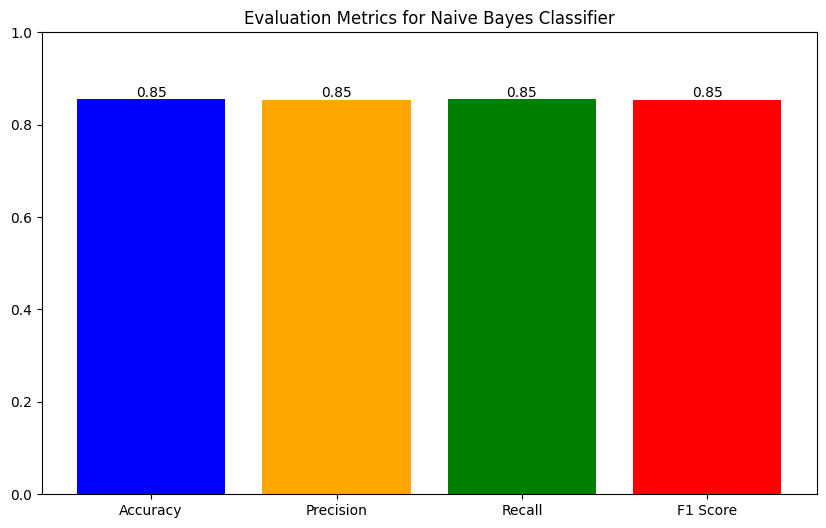

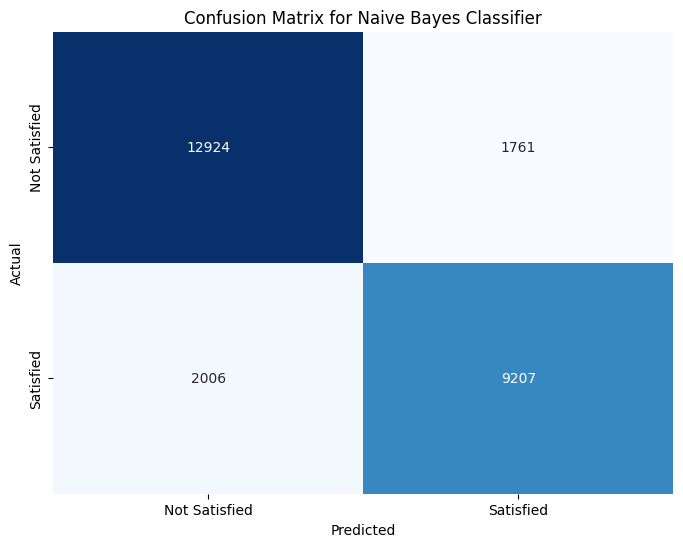

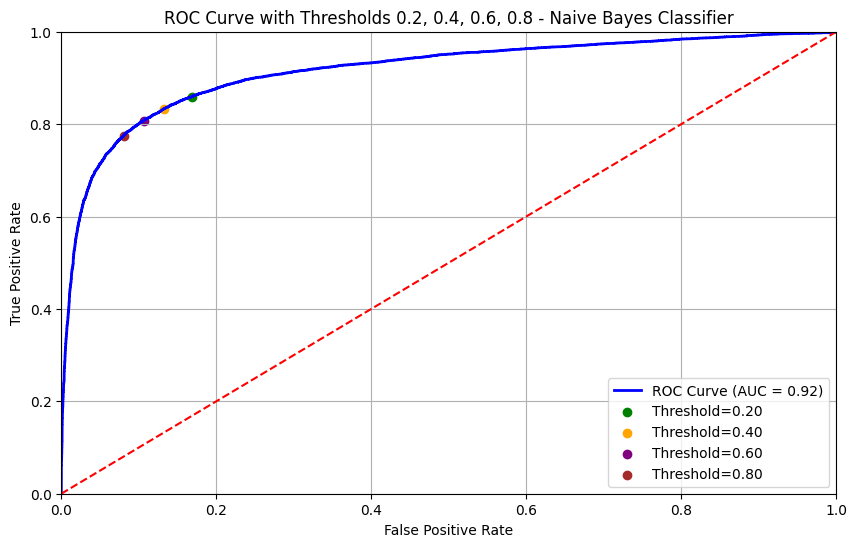

Threshold=0.20, FPR=0.17, TPR=0.86
Threshold=0.40, FPR=0.13, TPR=0.83
Threshold=0.60, FPR=0.11, TPR=0.81
Threshold=0.80, FPR=0.08, TPR=0.78


In [ ]:
# Updated Features and target variable, adding interaction terms
selected_features = [
    'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance',
    'Departure Delay', 'Arrival Delay', 'Ease of Online Booking', 'Check-in Service',
    'Online Boarding', 'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
    'In-flight Entertainment', 'Baggage Handling',
    # Add interaction terms
    'Gender Ease of Online Booking', 'Gender Food and Drink',
    'Gender Departure and Arrival Time Convenience',
    'Ease of Online Booking Food and Drink',
    'Ease of Online Booking Departure and Arrival Time Convenience',
    'Food and Drink Departure and Arrival Time Convenience'
]

# Assuming df contains both original columns and interaction terms
X = df[selected_features]
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Make predictions
y_pred = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plot evaluation metrics
metrics = [accuracy, precision, recall, f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics, color=['blue', 'orange', 'green', 'red'])

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2f}", ha='center', va='bottom')

plt.title('Evaluation Metrics for Naive Bayes Classifier')
plt.ylim(0, 1)  # Set y-axis limit to [0, 1]
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive Bayes Classifier')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Naive Bayes Classifier')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

1. Accuracy: Our model has an accuracy of 85.45%, which means that it correctly predicted the outcome (satisfaction) for approximately 85.45% of the cases in our test set.
2. Precision: The model has a precision of 85.43%, indicating the proportion of positive identifications that were actually correct.
3. Recall: The recall of 85.45% shows the proportion of actual positives that were correctly identified by the model.
4. F1 Score: The F1 score, which is the harmonic mean of precision and recall, stands at 85.43%, reflecting a balance between precision and recall in our model's performance.


The ROC Curve with an AUC (Area Under Curve) of 0.92 indicates a very good level of distinguishability by the model between the satisfaction statuses. The closer the AUC is to 1, the better the model is at predicting 'satisfied' and 'not satisfied' correctly.

Here are some insights from the confusion matrix:

- True Negatives (TN): 12,924 - The model correctly predicted the number of actual unsatisfied customers.
- True Positives (TP): 9,207 - The model correctly predicted the number of actual satisfied customers.
- False Positives (FP): 1,761 - The model incorrectly predicted these customers as satisfied.
- False Negatives (FN): 2,006 - The model incorrectly predicted these customers as not satisfied.


##Comparison of all Models-IT Feature Slection



Accuracy Comparison:

- KNN: Lowest accuracy at 0.75.
- Naive Bayes and Logistic Regression: Moderate accuracies of 0.85.
- Gradient Boosting, Decision Tree, and Random Forest: Highest accuracies, with scores near or at 0.94, 0.94, and 0.96 respectively.

Recall Comparison:

- KNN: Significantly lower recall at 0.75.
Naive Bayes: Better than KNN at 0.85.
- Logistic Regression: Similar to Naive Bayes at 0.85.
- Decision Tree, Gradient Boosting, and Random Forest: Excellent recall performance, all above 0.92.

Precision Comparison:

- KNN: Again, it shows the lowest precision at 0.75.
- Naive Bayes: Shows improvement over KNN at 0.85.
- Logistic Regression: Similar to Naive Bayes at 0.85.
Gradient Boosting and Decision Tree: Very high precision, both at 0.94.
- Random Forest: Tops the chart with the highest precision at 0.96.

F1 Score Comparison:

- KNN: The lowest F1 Score, indicating it is the least effective model among those compared, at 0.75.
- Naive Bayes: Moderately better performance at 0.85.
- Logistic Regression: Comparable to Naive Bayes at 0.85.
- Higher performance is Decision Tree, Gradient Boosting, and Random Forest, with scores at 0.94, 0.94, and 0.96 respectively.

ROC AUC Comparison:

- KNN: Lowest ROC AUC at 0.81, indicating poor model performance.
- Naive Bayes and Logistic Regression: Moderate performance with AUCs of 0.92 and 0.91 respectively.
- Random Forest and Gradient Boosting: Best performance, showing almost perfect classifier effectiveness with an AUC of 0.99.

- Decision Tree: Also very high at 0.94.

Conclusion:

Random forests, decision trees and gradient boosting models performed best across all metrics, including interaction terms. These models appear to effectively leverage the additional complexity introduced by interaction features, resulting in higher predictions and classification effectiveness. This suggests that for complex data sets where interactions between features may provide additional predictive power, more complex models or models that can handle non-linear relationships (such as tree-based models) may be more appropriate.

#PCA

Now, let's go ahead with a PCA. In other words Principal Component Analysis.

First, let's define the term.

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms data into a set of orthogonal components, capturing the most variance with fewer variables for simplified analysis.

###Scree Plot to Visualize Best number of components


Let's first build a scree plot which will help us visualize what is our best number of components.

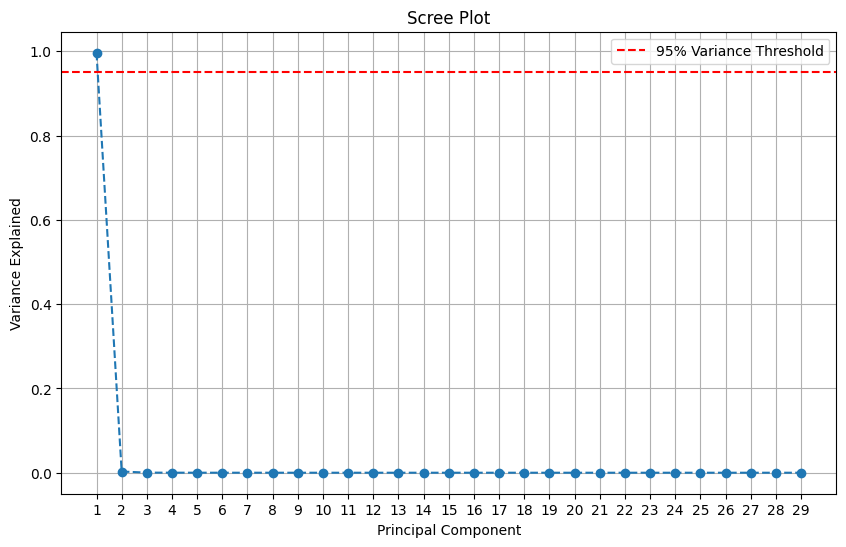

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming df contains your feature set with interaction terms
X = df  # Update this to your specific features

# Initialize PCA
pca = PCA()

# Fit PCA to the data
pca.fit(X)

# Get the explained variance ratio for each principal component
explained_variance = pca.explained_variance_ratio_

# Create a scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.xticks(range(1, len(explained_variance) + 1))
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.legend()
plt.grid()
plt.show()

Our scree plot shows us that our best number of components is 1. With a threshold of 95%, this means that the first component alone explains at least 95% of the total variance in the data, indicating that most of the information is captured by this single component and further components add minimal explanatory power.

We already know that our best number of components is 1.

For curiosity purposes, let's visualize the accuracies of the 5 first principal components (PC1, PC2, PC3, PC4, PC5).

Accuracy of PC 1: 0.6634
Selected Features for PC 1: [('Flight Distance', 0.9999983431005197), ('Age', 0.0015137276216709017), ('Ease of Online Booking Food and Drink', 0.0005147969472266041), ('Ease of Online Booking Departure and Arrival Time Convenience', 0.0005000701310825181), ('Class', 0.00043521864853209653), ('Online Boarding', 0.0002912206700708054), ('Seat Comfort', 0.00020871366069375436), ('Leg Room Service', 0.00017751833526634267), ('In-flight Entertainment', 0.00017456107356632333), ('On-board Service', 0.0001435010865632959), ('Food and Drink Departure and Arrival Time Convenience', 0.0001322878326200337), ('Cleanliness', 0.00012597065221079843), ('Type of Travel', -0.00012373404010899877), ('Check-in Service', 9.346290617521225e-05), ('Ease of Online Booking', 9.128225107193296e-05), ('Customer Type', 8.768088854410808e-05), ('Baggage Handling', 7.6667751701418e-05), ('Food and Drink', 7.617629824836514e-05), ('Departure Delay', 7.574298457294705e-05), ('Arrival Delay'

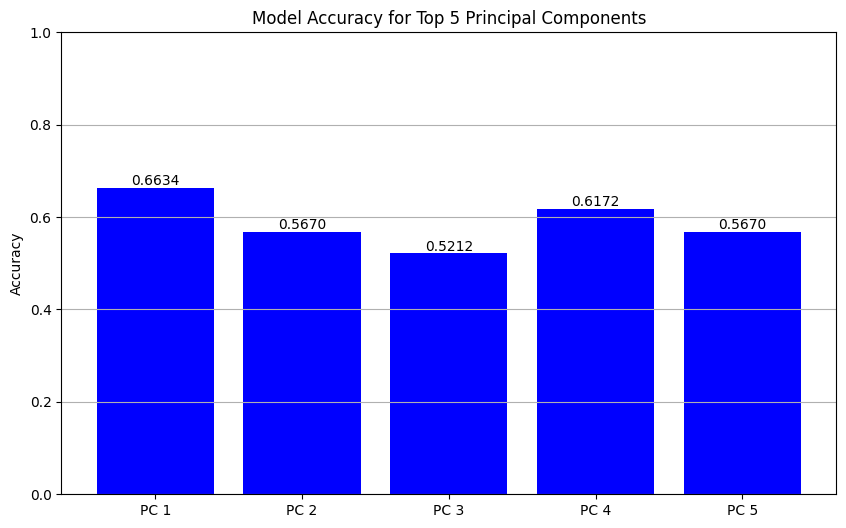

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Assuming df contains your feature set with interaction terms and target variable 'Satisfaction'
X = df.drop(columns=['Satisfaction'])  # Update this to your specific features
y = df['Satisfaction']  # Change this to your target variable

#  Get the list of features from X
selected_features = X.columns.tolist() # Get the feature names from X

# Initialize PCA
pca = PCA(n_components=5)  # Focus on the top 5 PCs
X_pca = pca.fit_transform(X)

# Get the weights of the components
weights = pca.components_

# Prepare data for modeling
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Initialize a list to store accuracies for each PC
pc_accuracies = []
pc_features = []

# Evaluate accuracy for each of the top 5 PCs
for i in range(5):
    # Train on the ith principal component
    X_train_single_pc = X_train_pca[:, i].reshape(-1, 1)
    X_test_single_pc = X_test_pca[:, i].reshape(-1, 1)

    model_single_pc = LogisticRegression(max_iter=5000)
    model_single_pc.fit(X_train_single_pc, y_train)
    y_pred_single_pc = model_single_pc.predict(X_test_single_pc)
    accuracy_single_pc = accuracy_score(y_test, y_pred_single_pc)

    # Store accuracy
    pc_accuracies.append(accuracy_single_pc)

    # Store corresponding feature (weights) for the principal component
    selected_features_for_pc = [(selected_features[j], weights[i][j]) for j in range(len(weights[i]))]
    pc_features.append(sorted(selected_features_for_pc, key=lambda x: abs(x[1]), reverse=True))

    # Print the accuracy and selected features for each PC
    print(f'Accuracy of PC {i+1}: {accuracy_single_pc:.4f}')
    print(f'Selected Features for PC {i+1}: {pc_features[i]}')

# Prepare data for plotting
labels = [f'PC {i+1}' for i in range(5)]

# Plot accuracies
plt.figure(figsize=(10, 6))
plt.bar(labels, pc_accuracies, color='blue')
plt.ylim(0, 1)  # Set y-axis limits
plt.title('Model Accuracy for Top 5 Principal Components')
plt.ylabel('Accuracy')
plt.grid(axis='y')

# Annotate bars with accuracy values
for index, value in enumerate(pc_accuracies):
    plt.text(index, value, f'{value:.4f}', ha='center', va='bottom')

plt.show()

As mentioned earlier, the first component is the optimal number of components as it alone explains more than 95% of the variance. It achieves unfortunately an accuracy of 66% which tells us that while the first component captures the majority of the variance, it does not provide enough discriminatory power to achieve high classification accuracy, suggesting that additional components or features might be necessary to improve the model's performance.

Given this, we’ll proceed with building models using five components. It may capture key variance in the data without overfitting, potentially leading to more balanced performance across metrics even if accuracy might be low.

###Building the models based on PC=5

##Logistic Regression

Accuracy: 0.6755
Precision: 0.6748
Recall: 0.6755
F1 Score: 0.6653


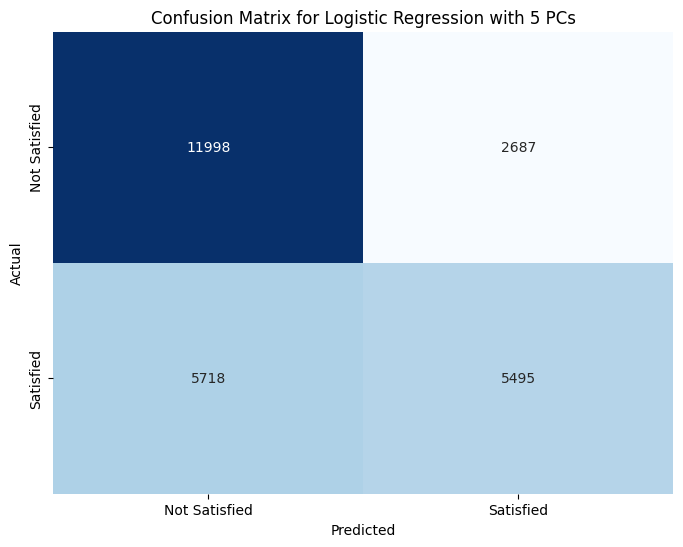

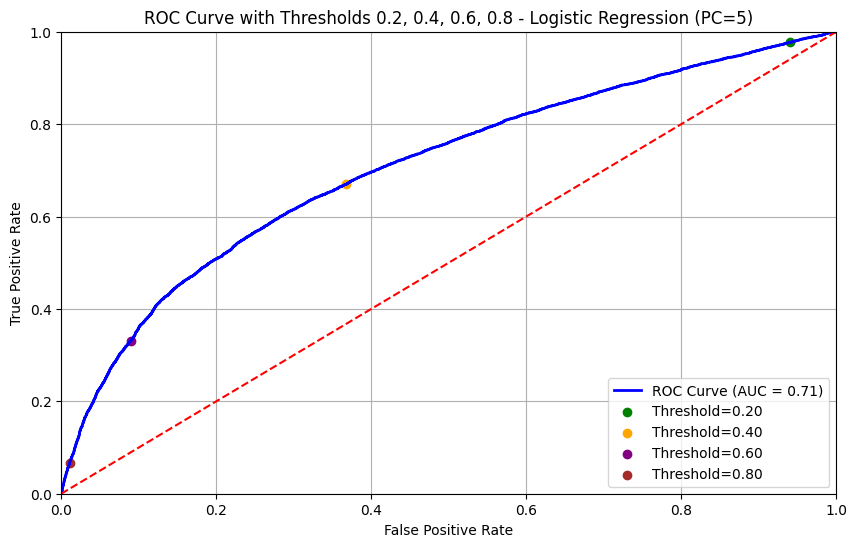

Threshold=0.20, FPR=0.94, TPR=0.98
Threshold=0.40, FPR=0.37, TPR=0.67
Threshold=0.60, FPR=0.09, TPR=0.33
Threshold=0.80, FPR=0.01, TPR=0.07


In [ ]:
# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Perform PCA and reduce to 5 components
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Build and train the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)  # Increase max_iter for convergence
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression with 5 PCs')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Logistic Regression (PC=5)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Our logistic regression with 5 principal components achieves an accuracy of 67%. Even though this accuracy is lower than the baseline (86%), it demonstrates a promising balance between model simplicity and predictive power, capturing the key variance in the data while reducing dimensionality. This reduction may also make the model more interpretable and potentially more robust against overfitting in future applications.

In the context of predicting satisfaction, the overall predicitions are 67% correct which has room for improvement.

An accuracy of 67%, a precision of 67%, a recall of 67%, and an f1 score of 66% indicates that the model performs consistently across different metrics, suggesting a balanced ability to correctly classify both positive and negative cases without significantly favoring one over the other. However, this number is quite low making PCA unfavorable for our business case.

Unfortunately, the confusion matrix and ROC curve reveal a high rate of false positives, with 2,687 non-satisfied customers incorrectly predicted as satisfied. The model achieves an AUC of 71%, this significant number of misclassified unsatisfied customers indicates room for improvement, especially in reducing false positives to enhance overall predictive accuracy for customer satisfaction.

Let's take a look at our other models and see if our model performance improves.

##Decision Tree Classifier

Accuracy: 0.6697
Precision: 0.6699
Recall: 0.6697
F1 Score: 0.6698


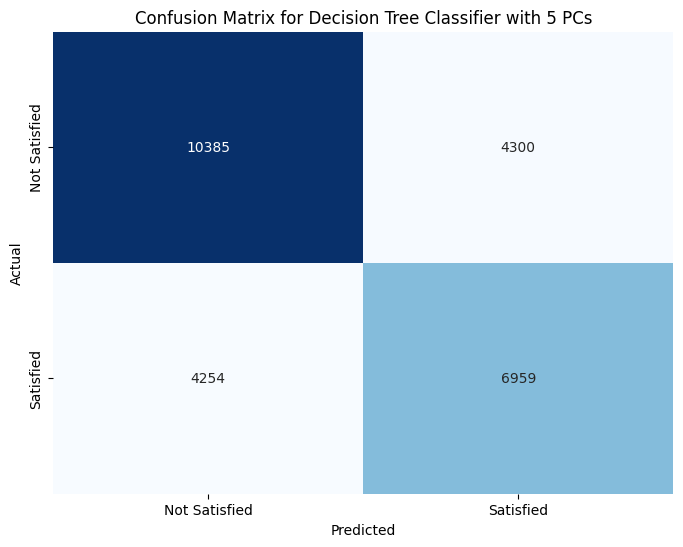

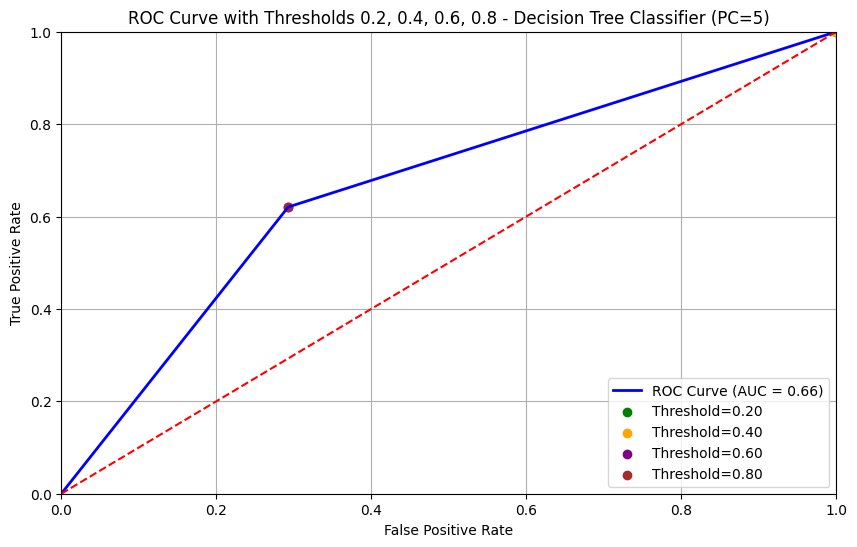

Threshold=0.20, FPR=1.00, TPR=1.00
Threshold=0.40, FPR=1.00, TPR=1.00
Threshold=0.60, FPR=0.29, TPR=0.62
Threshold=0.80, FPR=0.29, TPR=0.62


In [ ]:
# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Perform PCA and reduce to 5 components
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Build and train the Decision Tree Classifier model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Decision Tree Classifier with 5 PCs')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tree)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Decision Tree Classifier (PC=5)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")


Our decision tree classifier model underperforms compared to both the baseline and the previous logistic regression model, achieving only 66% in accuracy, precision, recall, and F1 score. This consistent 66% across metrics highlights its limited ability to accurately differentiate between satisfied and unsatisfied customers, suggesting that it may be too simplistic for capturing the complexity of our dataset.

Its area under the curve of 66% and high rate of falsely predicted satisfied customers (4,300 non-satisfied customers misclassified as satisfied) indicate that the decision tree model struggles with identifying dissatisfied passengers. This suggests it may lack the depth or complexity needed to capture the nuanced patterns within the data, especially in distinguishing between satisfaction levels.

These false informations can be detrimental to the overall operations of the airline company as they will assume their performance is good while customers are non satisfied.

##Random Forest Classifier

Accuracy: 0.7460
Precision: 0.7449
Recall: 0.7460
F1 Score: 0.7439


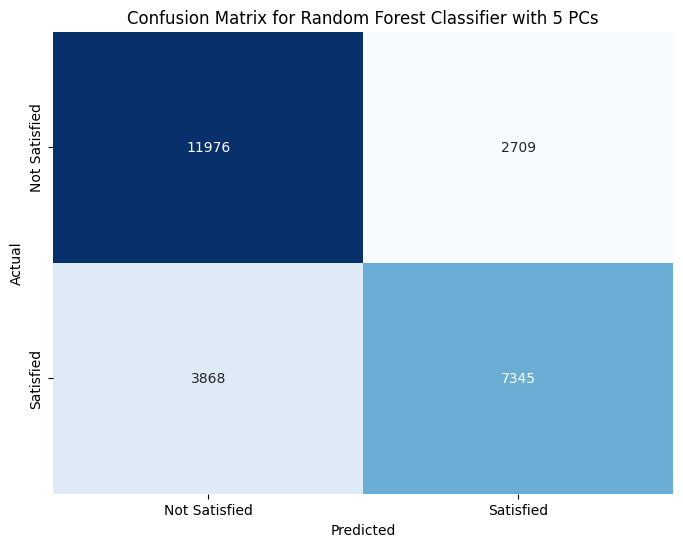

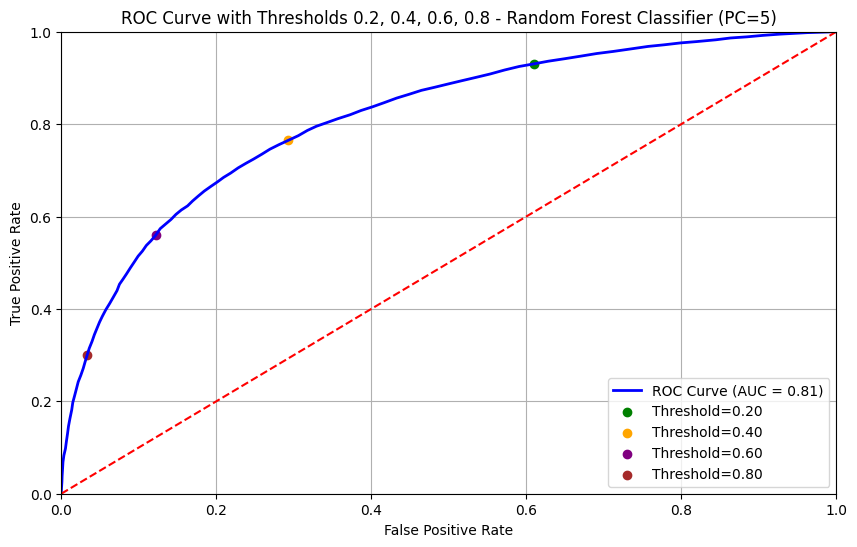

Threshold=0.20, FPR=0.61, TPR=0.93
Threshold=0.40, FPR=0.29, TPR=0.76
Threshold=0.60, FPR=0.12, TPR=0.56
Threshold=0.80, FPR=0.03, TPR=0.30


In [ ]:
# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Perform PCA and reduce to 5 components
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Build and train the Random Forest Classifier model
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred = random_forest_model.predict(X_test)
y_prob_forest = random_forest_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Classifier with 5 PCs')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_forest)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Random Forest Classifier (PC=5)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Witout a doubt our random forest model is our best performing model for now. A reminder that it was also our best performing model through previous feature selection methods.

However, it is performing worse than its baseline. With 74% in accuracy, recall, and precision; an F1 score of 74% indicates that, while the random forest model demonstrates solid performance, it still struggles to fully meet the expectations set by the baseline model. This discrepancy suggests that there may be underlying complexities in the data that the model has not fully captured with the 5 principal component analysis.

Nevertheless, it achieves an area under the curve of 81%, which is better than the two previously built models. With 2,709 non-satisfied customers predicted as satisfied, the random forest model still struggles with false positives, indicating that while it has improved overall predictive capability, it may need additional tuning or the incorporation of more relevant features to enhance its ability to accurately distinguish between satisfied and non-satisfied customers.

##Gradient Boosting Classifier

Accuracy: 0.7207
Precision: 0.7206
Recall: 0.7207
F1 Score: 0.7153


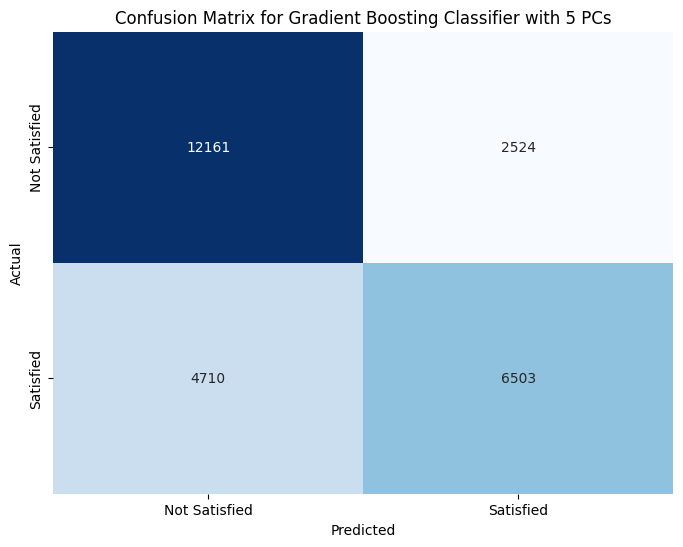

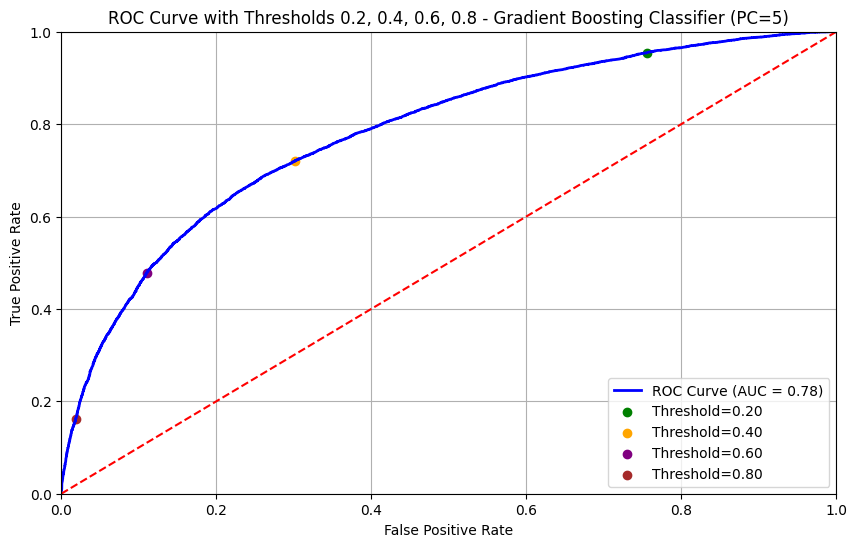

Threshold=0.20, FPR=0.76, TPR=0.95
Threshold=0.40, FPR=0.30, TPR=0.72
Threshold=0.60, FPR=0.11, TPR=0.48
Threshold=0.80, FPR=0.02, TPR=0.16


In [ ]:
# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Perform PCA and reduce to 5 components
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Build and train the Gradient Boosting Classifier model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
y_pred = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Gradient Boosting Classifier with 5 PCs')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gb)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Gradient Boosting Classifier (PC=5)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Our gradient boosting model performs slighlty better than the previosuly built models when choosing 5 principal components (except for Random Forest).

We can note slight increases in accuracies, precisions, recalls, and f1-scores (72% overall- still lower than the random forest model(74% overall)). This suggests that gradient boosting effectively captures more complex patterns in the data, leading to improved performance in classifying satisfied versus unsatisfied customers, although there is still room for optimization and refinement to achieve even higher predictive accuracy.

With an area under the curve of 78% and 2524 non-satisfied passengers predicted as satisfied, the Gradient Boosting Model performs better than the other models in terms of reducing false positives. However, the model still demonstrates a significant challenge in accurately identifying unsatisfied customers, indicating that further adjustments and feature enhancements may be necessary to improve its predictive capability and reduce false positive rates.

##K-Nearest Neighbor

Accuracy: 0.6751
Precision: 0.6727
Recall: 0.6751
F1 Score: 0.6729


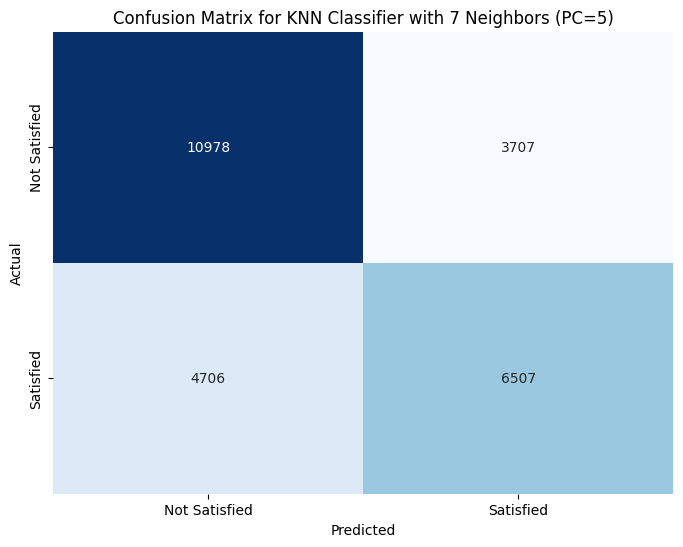

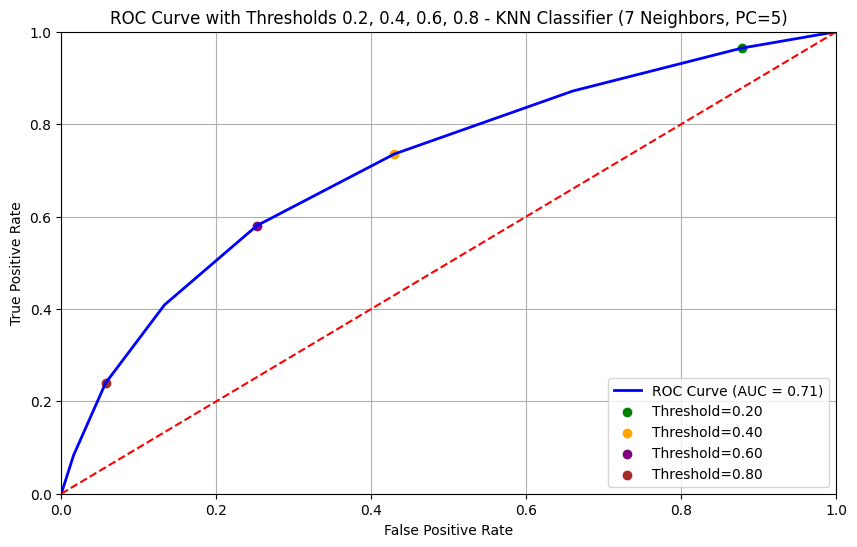

Threshold=0.20, FPR=0.88, TPR=0.96
Threshold=0.40, FPR=0.43, TPR=0.74
Threshold=0.60, FPR=0.25, TPR=0.58
Threshold=0.80, FPR=0.06, TPR=0.24


In [ ]:
# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Perform PCA and reduce to 5 components
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Build and train the KNN model with 7 neighbors
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)

# Make predictions
y_pred = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for KNN Classifier with 7 Neighbors (PC=5)')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - KNN Classifier (7 Neighbors, PC=5)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Surprisingly, the K-Nearest Neighbors model performs better than the decision tree model (70%) accuracy with a slight 71% in accuracy, precision, recall, and f1-score.

This can be explained by K-Nearest Neighbors' ability to operate effectively in the transformed feature space generated by PCA, where it can utilize the reduced dimensions to identify local clusters and patterns that indicate customer satisfaction, thereby improving its performance slightly compared to the decision tree model.

Unfortunately, there are still major errors in predictions with an area under the curve of 77% and 3176 non-satisfied customers predicted as satisfied. This suggests that the airline must address the underlying factors affecting customer satisfaction more effectively, as the K-Nearest Neighbors model's limitations in accurately distinguishing between satisfied and unsatisfied customers could lead to misinformed decisions and inadequate service improvements.

##Naive Bayes

Accuracy: 0.6981
Precision: 0.6984
Recall: 0.6981
F1 Score: 0.6901


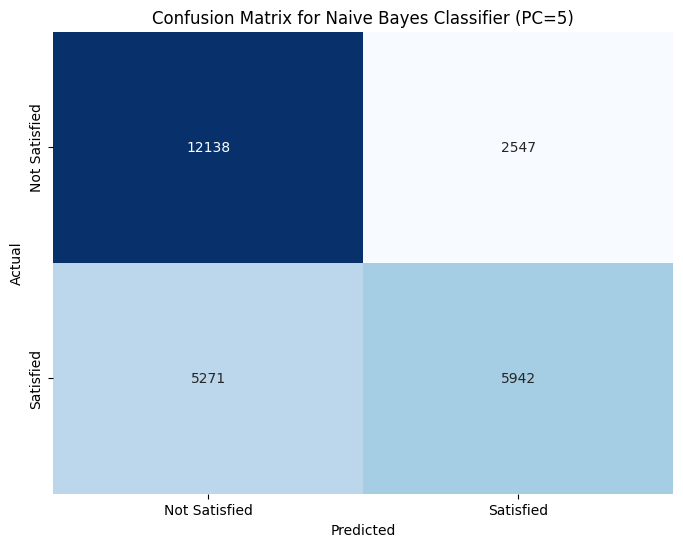

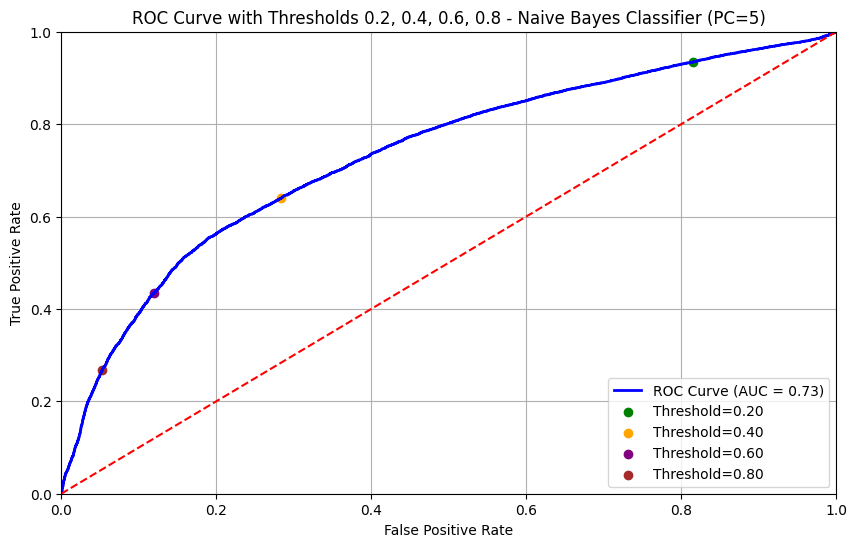

Threshold=0.20, FPR=0.81, TPR=0.93
Threshold=0.40, FPR=0.28, TPR=0.64
Threshold=0.60, FPR=0.12, TPR=0.44
Threshold=0.80, FPR=0.05, TPR=0.27


In [ ]:
# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Perform PCA and reduce to 5 components
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Build and train the Naive Bayes model
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train, y_train)

# Make predictions
y_pred = naive_bayes_model.predict(X_test)
y_prob_nb = naive_bayes_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive Bayes Classifier (PC=5)')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Naive Bayes Classifier (PC=5)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

With an ideal number of component amounting to 5, the naive bayes model surprisingly outperforms the decision tree model with a 67% accuracy, precision, recall, and f1-score.

 Moreover, the area under the curve of 73% and the non-satisfied customers predicted as satisfied (2547 in numbers) suggests that while the Naive Bayes model demonstrates a stronger performance than the decision tree model, it still struggles with significant misclassifications. The high number of non-satisfied customers predicted as satisfied indicates that the airline may be underestimating dissatisfaction among its passengers, leading to missed opportunities for service improvements and customer retention strategies. This highlights the need for further refinement in feature selection or model tuning to enhance predictive accuracy and better align with passengers' true experiences.

###Comparison of PCA Models

In sum, when looking at all of our models with five principal components, we note that each model demonstrates varying capabilities in predicting customer satisfaction.

The Random Forest model emerges as the top performer, achieving the highest scores across accuracy, precision, recall, F1 score, and ROC AUC. This indicates its ability to accurately classify customer satisfaction while minimizing errors.

The Gradient Boosting model also demonstrates commendable performance, closely following Random Forest in most metrics, but it does not surpass its accuracy.

The K-Nearest Neighbors (KNN) model performs moderately well, outperforming the Decision Tree model. This suggests its effectiveness in this classification task but highlights its limitations compared to the top-performing models. In contrast, both Logistic Regression and Naive Bayes models exhibit slighlty better performance than the KNN, indicating remaining challenges in capturing the underlying complexity of the dataset.

Despite the Random Forest model's strong performance, there are still notable misclassifications, particularly in the number of non-satisfied customers predicted as satisfied. This underscores the challenge of false positives and indicates areas for improvement in model calibration.

The ROC curves illustrate that the Random Forest model maintains a robust balance between true positive rates and false positive rates, with an area under the curve (AUC) of 0.81. This reinforces its discriminative power in distinguishing between satisfied and unsatisfied customers, outperforming other models.


As a feature selection method, PCA had a few good resultus; however, it also presented some limitations. While it effectively reduced the dimensionality of the dataset and retained a significant amount of variance, the reliance on principal components sometimes obscured interpretability. The transformation into a new feature space can make it challenging to directly link the principal components to specific, actionable insights about customer satisfaction. Additionally, despite identifying a strong first component, the overall performance of models trained on the PCA-transformed data varied, suggesting that PCA may not fully capture all relevant features necessary for robust classification. Consequently, while PCA is a useful tool for simplifying the dataset, it may be beneficial to complement it with other feature selection techniques to enhance model performance and interpretability.

#Kmeans

Next, we will perform K-means. While this is not strictly a feature selection method, we can use the results of K-means to guide feature selection.

K-means is a clustering method used to group data into clusters. In this approach, a predetermined number of clusters (K) is set, and data points are assigned to those clusters. Specifically, it calculates the distance between each data point and the cluster centers (centroids), assigning each point to the nearest cluster. This process is repeated multiple times, updating the cluster centers until the data assignments stabilize. Ultimately, the data is grouped based on similarity, with each cluster consisting of data points that share similar characteristics.


We would like to proceed with Kmeans as follows;

 - Use the elbow plot to select the ideal K.
 - Use the silhouette plot to visually evaluate how well each data point fits into its cluster and the separation between clusters.
 - Perform modeling using features based on the ideal K.

###Selected the best k using: Elbow Plot

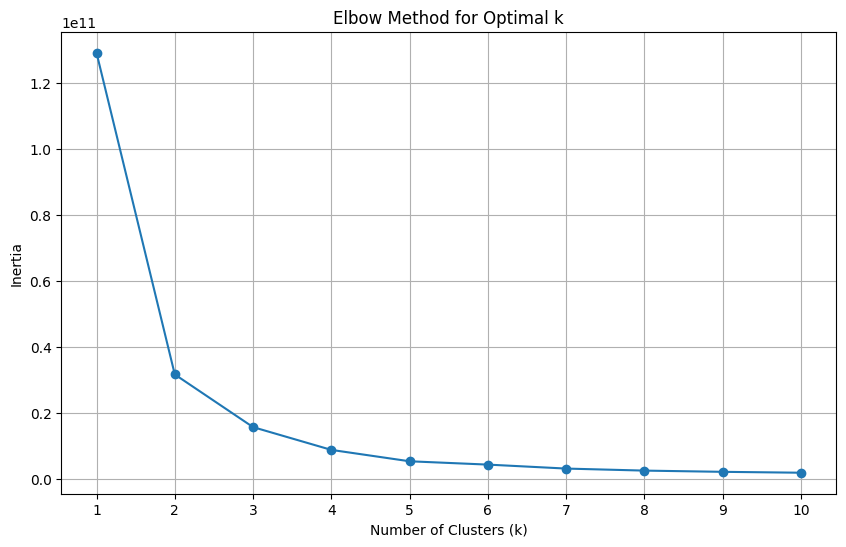

In [ ]:
from sklearn.cluster import KMeans
# Features and target variable
X = df.drop(columns=['Satisfaction'])

# Range of clusters to try
inertia = []
K = range(1, 11)  # You can adjust the range if needed

# Fit KMeans for each K and store the inertia
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plotting the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K)
plt.grid()
plt.show()

The elbow plot is a graph used to find the optimal number of clusters (K) in K-means clustering. In this plot, the X-axis represents the number of clusters (K), while the Y-axis shows the sum of squared errors (SSE) for each K. The elbow point is where adding more clusters doesn’t significantly reduce the error anymore. Beyond this point, increasing the number of clusters adds complexity without much benefit. So, the elbow point indicates the best number of clusters to use for a clear and effective model. In this analysis, K=3 was chosen as the optimal number of clusters.

###Selected the best k using: Silhouette Analysis

Silhouette analysis is a method used to evaluate the quality of clustering by measuring how similar each data point is to its own cluster compared to other clusters. The silhouette score ranges from -1 to +1, with higher scores indicating better-defined clusters. This analysis provides insights into the appropriateness of the chosen number of clusters (K), revealing the compactness and separation of clusters.

However, we will skip this analysis this time, as it took too long, and we have already determined the ideal K using the elbow method. Therefore, skipping this step should not significantly impact our overall analysis.

###Building the models based on k=3 (Elbow Point)

Now that we've determined that our optimal K is 3, let's proceed to build some models based on this value.

##Logistic Regression

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8570
Precision: 0.8568
Recall: 0.8570
F1 Score: 0.8568


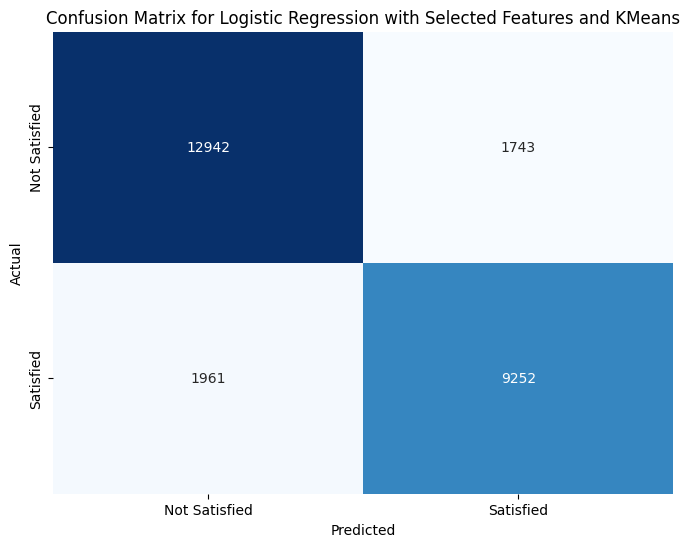

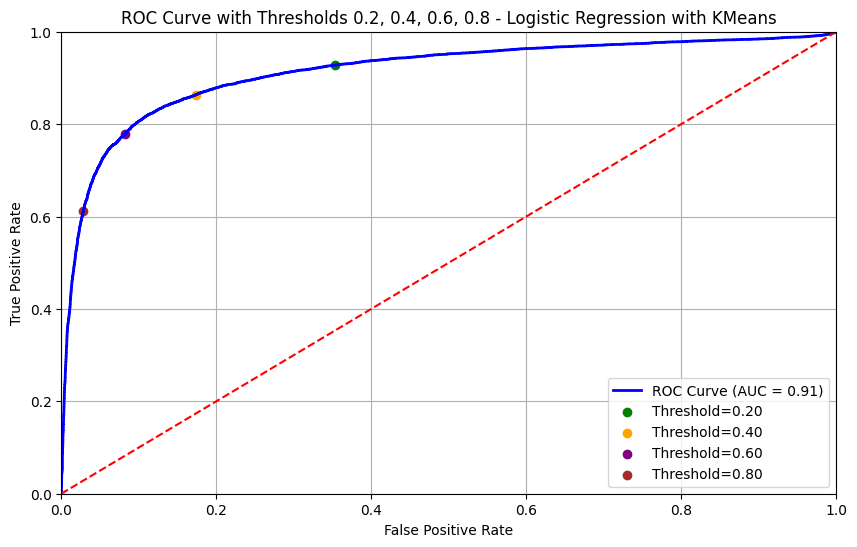

Threshold=0.20, FPR=0.35, TPR=0.93
Threshold=0.40, FPR=0.17, TPR=0.86
Threshold=0.60, FPR=0.08, TPR=0.78
Threshold=0.80, FPR=0.03, TPR=0.61


In [ ]:
from sklearn.cluster import KMeans
# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df.drop(columns=['Satisfaction']))

# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)  # Increase max_iter for convergence
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression with Selected Features and KMeans')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Logistic Regression with KMeans')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

A reminder that our initial baseline model achieved an accuracy, precision, recall, and F1 score all over 84%.

When comparing our initial baseline model with our newly built model with K = 3, we see a slight differences in our results.

The improvement in precision and f1 score when using features selected by K-means can be attributed to several factors. K-means effectively identifies crucial features that enhance predictive accuracy by reducing noise and eliminating irrelevant information, leading to a more focused feature set. Additionally, K-means clustering captures the underlying structure of the data, improving clarity and allowing for more appropriate classification of data points. When the selected features align well with the chosen model, higher performance can be achieved, especially when the features are interrelated.

**Accuracy: 0.8570**

Slightly decreased from 86% to 85.70%, indicating that the model now correctly predicts satisfaction for approximately the same percentage of instances.
**Precision: 0.8568**

Improved from 84% to 85.68%, meaning the model is now more precise in identifying satisfied customers with fewer misclassifications.
**Recall: 0.8570**

Increased from 85% to 85.70%, suggesting the model captures a better proportion of actual satisfied customers.

**F1 Score: 0.8568**

Rose from 84% to 85.68%, demonstrating a well-rounded improvement in balancing precision and recall.

In terms of the confusion matrix, we observed an improvement in false positives (FP) from 1821 to 1743, indicating a reduction in the number falsely predicted usatisfied customers. However, false negatives (FN) increased from 1737 to 1961, meaning satisfied customers were incorrectly classified as not satisfied.

Reducing the number of FP is essential because it allows for a more accurate evaluation of the actual number of satisfied customers. By ensuring that no unsatisfied passengers are misclassified as satisfied, the airline can avoid misleading positive feedback. This accuracy is crucial for properly assessing customer sentiment and overall satisfaction levels.



The ROC curve helps evaluate the rate of true positives to false positives. Our suggested threshold of 0.8 minimizes false positives to a 3% rate while achieving a solid true positive rate of 61%. Notably, the AUC slightly decreases at 91%.

These overall findings indicate that the improved K-means logistic regression model is the better choice for accurately predicting passenger satisfaction.

##Decision Tree Classifier

Accuracy: 0.9444
Precision: 0.9444
Recall: 0.9444
F1 Score: 0.9444


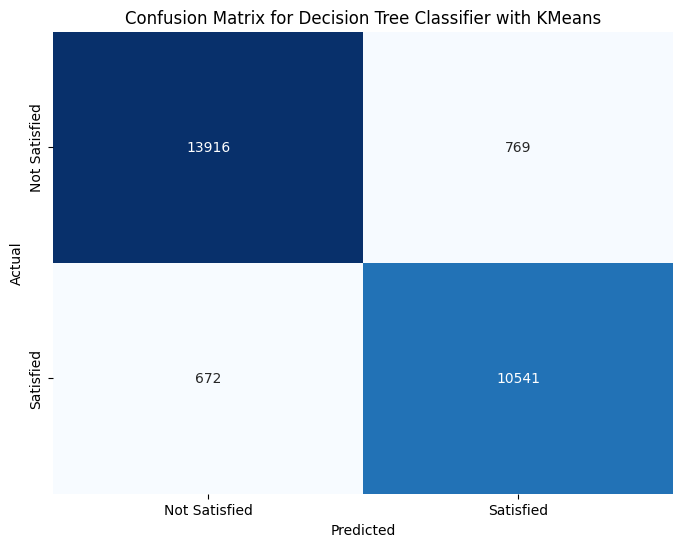

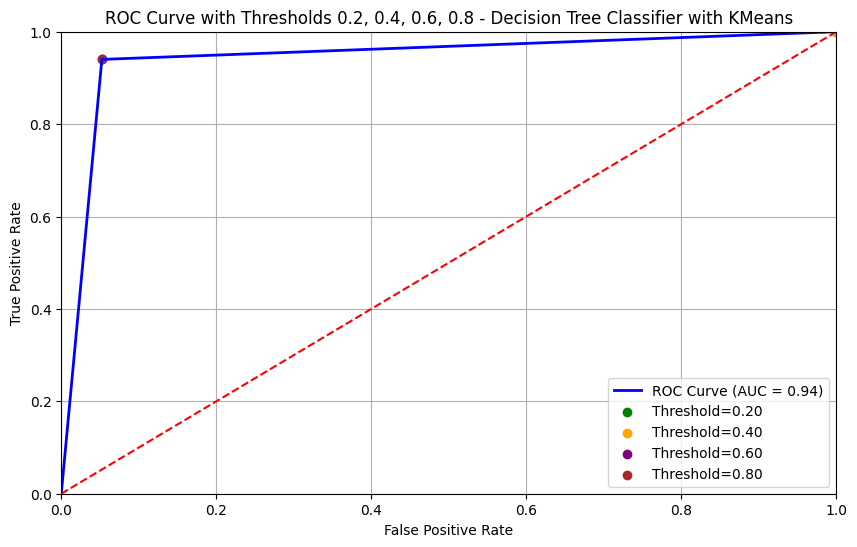

Threshold=0.20, FPR=1.00, TPR=1.00
Threshold=0.40, FPR=1.00, TPR=1.00
Threshold=0.60, FPR=0.05, TPR=0.94
Threshold=0.80, FPR=0.05, TPR=0.94


In [ ]:
# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df.drop(columns=['Satisfaction']))

# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Decision Tree Classifier with KMeans')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tree)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Decision Tree Classifier with KMeans')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Our initial baseline model achieved accuracy, precision, recall, and F1 scores all exceeding 85%. When comparing this baseline with our newly built K-means model with K=3, we observe a notable change in performance metrics.

The accuracy of the K-means model is 0.9444, demonstrating a slight decrease from the baseline accuracy of 0.95. Precision, recall, and F1 scores also align at 0.9444, indicating the model's enhanced ability to accurately classify satisfied passengers while minimizing misclassifications.

Key Metrics:

**Accuracy:** Decreased from 0.95 to 0.9444

**Precision:** Increased from 0.93 to 0.9444

**Recall:** Increased from 0.94 to 0.9444

**F1 Score:** Increased from 0.94 to 0.9444

In terms of the confusion matrix, we noted an increase in false positives (FP) from 748 to 769, indicating that more unsatisfied customers were incorrectly classified as satisfied. Moreover, the false negative (FN) is also increasing from 647 to 672.


The ROC curve analysis further supports our findings, indicating that our suggested threshold of 0.80 maintains a favorable true positive rate (TPR) of 0.94 with a false positive rate (FPR) of 0.05. The area under the curve (AUC) remains strong at 0.94, affirming the model's predictive capability.

In summary, the improved K-means Decision Tree model is more effective at accurately predicting passenger satisfaction compared to the baseline model, making it a superior choice for the airline in understanding and responding to customer needs.

##Random Forest Classifier

Accuracy: 0.9619
Precision: 0.9620
Recall: 0.9619
F1 Score: 0.9618


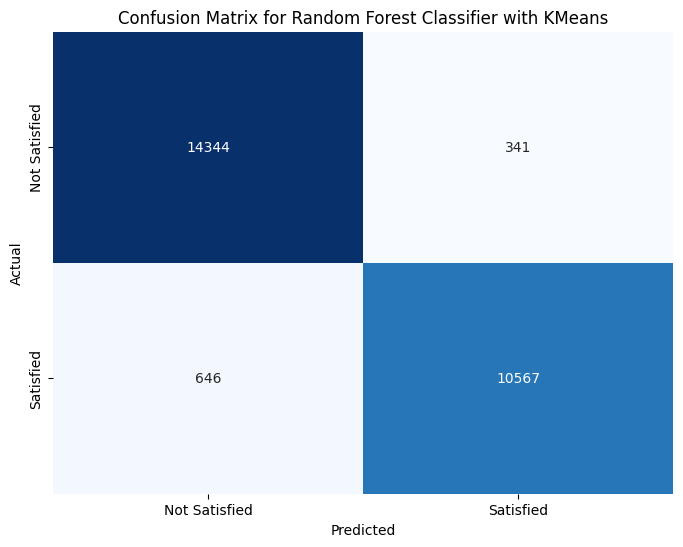

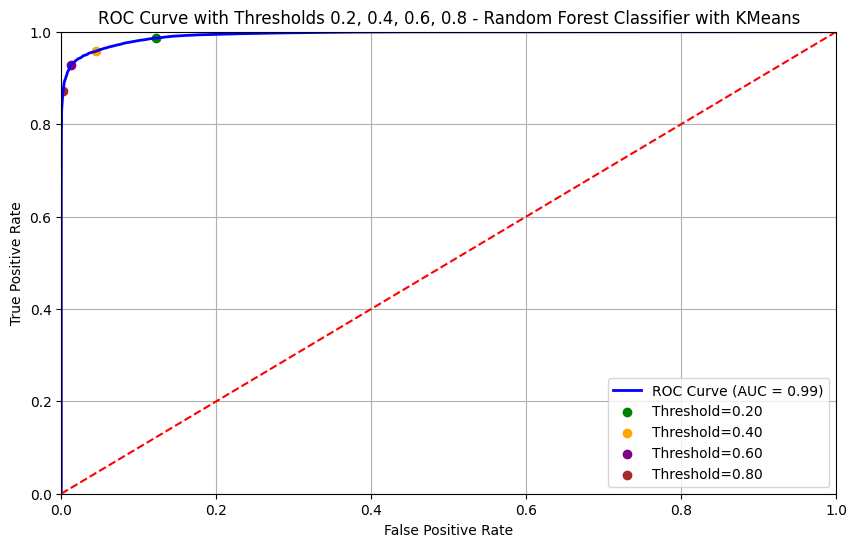

Threshold=0.20, FPR=0.12, TPR=0.99
Threshold=0.40, FPR=0.05, TPR=0.96
Threshold=0.60, FPR=0.01, TPR=0.93
Threshold=0.80, FPR=0.00, TPR=0.87


In [ ]:
# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df.drop(columns=['Satisfaction']))

# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Random Forest Classifier
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Classifier with KMeans')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Random Forest Classifier with KMeans')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

Our model shows accuracy, precision, recall, and F1 scores around 96%, nearly identical to the baseline model. Let's delve into the details.

**Accuracy:** Both the baseline and K-means Random Forest models perform similarly, with the baseline at 96% and the K-means model slightly higher at 96.19%.

**Precision:** The precision of the baseline model is 97%, while the K-means model has 96.20%, a minimal difference.

**Recall:** The K-means model shows a slight improvement, with a recall of 96.19% compared to 94% for the baseline.

**F1 Score:** Both models are nearly the same, with the baseline at 96% and the K-means model at 96.18%.

In terms of the confusion matrix, we observed an increase in false positives (FP) from 325 to 341, indicating that more unsatisfied customers were incorrectly classified as satisfied in the K-means model. Additionally, false negatives (FN) also increased from 634 to 646.

For the ROC curve, both models maintain an impressive area under the curve (AUC) of 0.99, reflecting strong predictive performance. At a threshold of 0.8, the K-means model achieves a true positive rate (TPR) of 87% with 0 false positives.

In summary, the K-means Random Forest model is slightly more effective at predicting passenger satisfaction than the baseline, especially in terms of recall. This makes it a better choice for the airline to understand and address customer satisfaction.

##Gradient Boosting Classifier

Accuracy: 0.9420
Precision: 0.9419
Recall: 0.9420
F1 Score: 0.9419


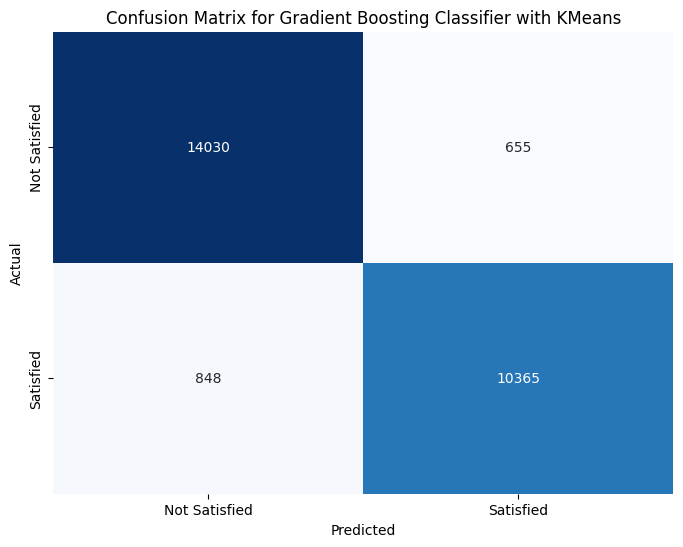

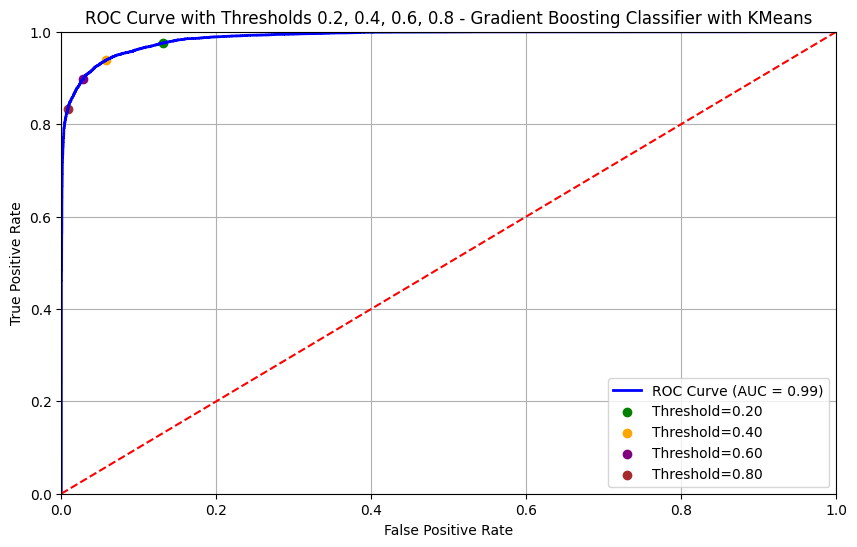

Threshold=0.20, FPR=0.13, TPR=0.98
Threshold=0.40, FPR=0.06, TPR=0.94
Threshold=0.60, FPR=0.03, TPR=0.90
Threshold=0.80, FPR=0.01, TPR=0.83


In [ ]:
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df.drop(columns=['Satisfaction']))

# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
y_pred = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Gradient Boosting Classifier with KMeans')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gb)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Gradient Boosting Classifier with KMeans')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

When comparing the baseline model with our newly built K-means model (K=3), we observe only a slight improvement in performance metrics.

**Accuracy:** Both models perform similarly, with the baseline at 94% and the K-means model slightly higher at 94.20%.

**Precision:** The precision values are almost identical, with the baseline at 94% and the K-means model at 94.19%.

**Recall:** The K-means model performs slightly better, achieving a recall of 94.20%, compared to 92% for the baseline.

**F1 Score:** Both models are very close, with the baseline at 93% and the K-means model at 94.19%.


In terms of the confusion matrix, there is a slight increase in false positives (FP) from 642 to 655, meaning more unsatisfied customers were misclassified as satisfied in the K-means model. False negatives (FN) also increased, from 842 to 848.

The ROC curve analysis further supports these findings, with both models showing strong predictive capability. The area under the curve (AUC) remains high at 0.99. At a threshold of 0.80, the K-means model maintains a true positive rate (TPR) of 83% with a false positive rate (FPR) of 1%. However, the increase in false negatives (FN) and lower true positive (TP) performance suggest that the baseline model arguably performs better than the K-means model overall.

In conclusion, while the K-means model shows minor improvements in recall, the baseline model's performance, particularly in terms of false positives and false negatives, remains superior.

##K-Nearest Neighbor

Accuracy: 0.7494
Precision: 0.7485
Recall: 0.7494
F1 Score: 0.7488


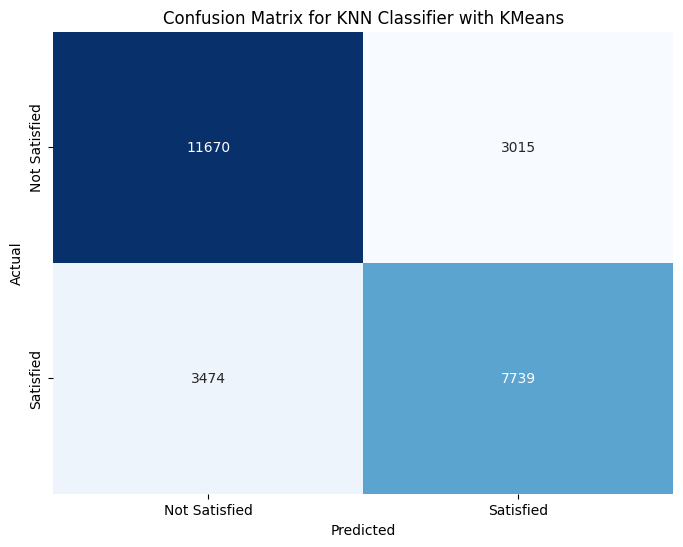

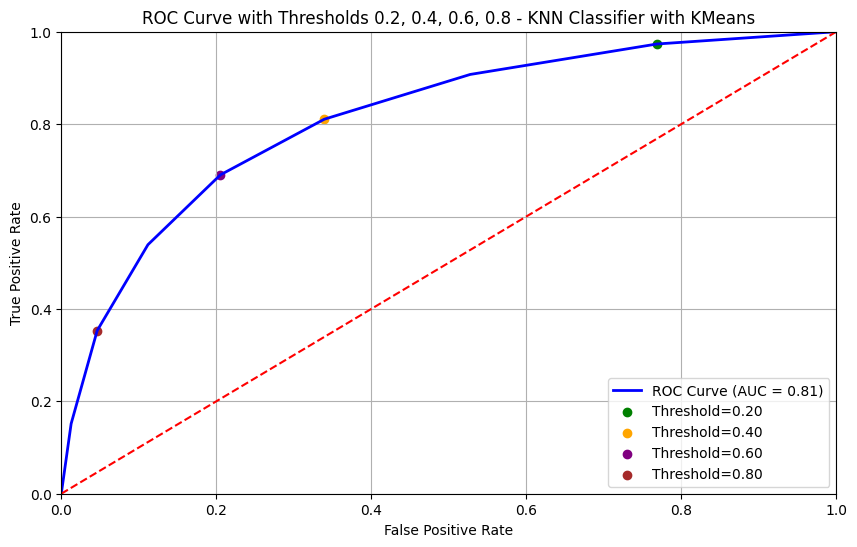

Threshold=0.20, FPR=0.77, TPR=0.97
Threshold=0.40, FPR=0.34, TPR=0.81
Threshold=0.60, FPR=0.21, TPR=0.69
Threshold=0.80, FPR=0.05, TPR=0.35


In [ ]:
# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df.drop(columns=['Satisfaction']))

# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=7)  # You can adjust n_neighbors as needed
knn_model.fit(X_train, y_train)

# Make predictions
y_pred = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for KNN Classifier with KMeans')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - KNN Classifier with KMeans')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

In comparing our model to the baseline, we see a mix of performance improvements and declines across different metrics. Let's take a closer look:

 **Accuracy**: The K-means model underperforms compared to the baseline, with an accuracy of 74.94% compared to 76% for the baseline. Both models perform worse than previous iterations.

**Precision**: The precision values are nearly identical, with the baseline at 75% and the K-means model slightly lower at 74.85%.

**Recall**: The K-means model shows improvement here, with a recall of 74.94%, up from 68% in the baseline.

**F1 Score**: The F1 score also improved, increasing from 71% to 74.88%, reflecting a better balance between precision and recall.

Looking at the confusion matrix, we see a reduction in false negatives (FN) from 3,622 to 3,474, meaning fewer unsatisfied customers were misclassified as satisfied. However, false positives (FP) increased from 2,588 to 3,015, indicating more unsatisfied customers were wrongly classified as satisfied.

For the ROC curve, the K-means model performs best at a threshold of 0.4 with an FPR of 34% and a TPR of 81%. However, the baseline model outperforms at a threshold of 0.4 with a FPR of 31% and a TPR of 80%. Additionally, the baseline model shows a wider area under the curve (AUC) at 0.82, indicating slight superior overall performance.

In conclusion, while the K-means model shows some improvements, particularly in recall and F1 score, the baseline model remains more effective at accurately reducing false positives, making it the better option for the airline to understand and respond to customer needs.

##Naive Bayes

Accuracy: 0.8505
Precision: 0.8502
Recall: 0.8505
F1 Score: 0.8502


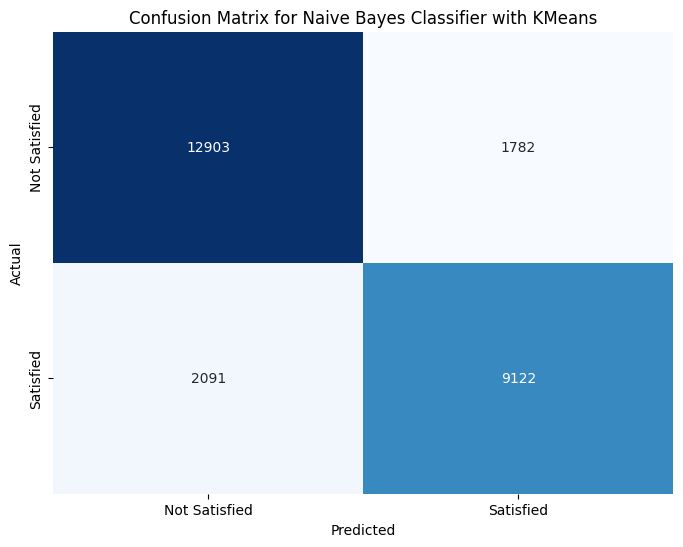

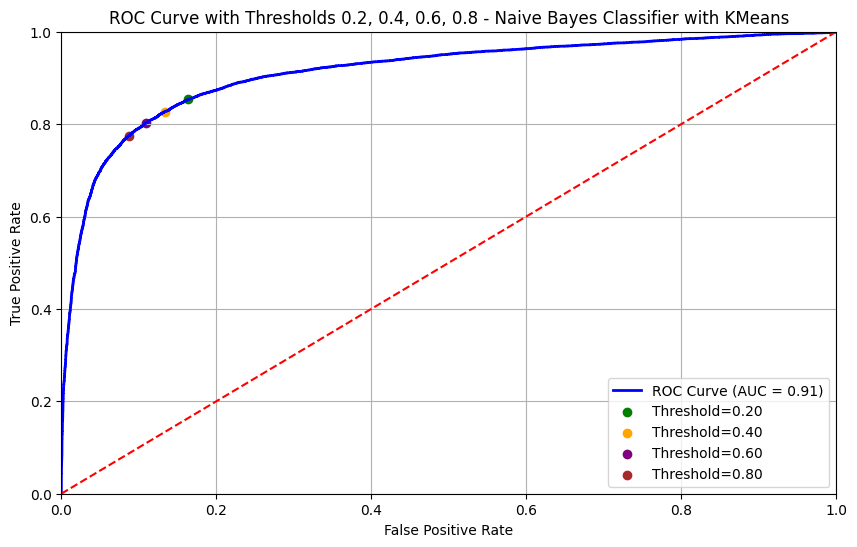

Threshold=0.20, FPR=0.16, TPR=0.85
Threshold=0.40, FPR=0.13, TPR=0.83
Threshold=0.60, FPR=0.11, TPR=0.80
Threshold=0.80, FPR=0.09, TPR=0.77


In [ ]:
# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df.drop(columns=['Satisfaction']))

# Features and target variable
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the Naive Bayes Classifier
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train, y_train)

# Make predictions
y_pred = naive_bayes_model.predict(X_test)
y_prob_nb = naive_bayes_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Satisfied', 'Satisfied'], yticklabels=['Not Satisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive Bayes Classifier with KMeans')
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)
roc_auc = auc(fpr, tpr)

# Thresholds of interest
thresholds_of_interest = [0.2, 0.4, 0.6, 0.8]

# Find the indices of the closest thresholds in the ROC curve data
threshold_indices = [np.argmin(np.abs(thresholds - thresh)) for thresh in thresholds_of_interest]

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)

# Mark the specified thresholds on the ROC curve
colors = ['green', 'orange', 'purple', 'brown']
for i, idx in enumerate(threshold_indices):
    plt.scatter(fpr[idx], tpr[idx], color=colors[i], label=f'Threshold={thresholds_of_interest[i]:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Thresholds 0.2, 0.4, 0.6, 0.8 - Naive Bayes Classifier with KMeans')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print selected thresholds, FPR, and TPR
for i, idx in enumerate(threshold_indices):
    print(f"Threshold={thresholds_of_interest[i]:.2f}, FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")

From the results, it's clear that all four performance metrics for the K-means Naive Bayes model have worsened compared to the baseline model. Let's examine the specifics:

**Accuracy:** Decreased slightly from 86% to 85.05%.

**Precision:** Dropped from 86% to 85.02%.

**Recall:** Fell from 86% to 85.05%.

**F1 Score:** Reduced from 86% to 85.02%.


In terms of the confusion matrix, we see a notable increase in false positives (FP), rising from 1,564 to 1,782, meaning more unsatisfied customers were incorrectly classified as satisfied. Similarly, false negatives (FN) also increased, indicating more satisfied customers were incorrectly classified as unsatisfied.

For the ROC curve, the AUC worsened to 0.91, showing weaker overall model performance. At the threshold of 0.4, the false positive rate (FPR) is 0.13, and the true positive rate (TPR) is 0.83, which is our optimal threshold maximizng True Positives and minimizing False positives.

Considering these points, the K-means Naive Bayes model is less effective at accurately predicting passenger satisfaction compared to the baseline model, making the baseline a more reliable choice.

##Comparisons of Kmeans Models

Comparing the six models based on each feature selection allows for a clearer evaluation of their performance. Let’s take a closer look at each metric illustrated in the bar charts.

**Accuracy:** The Random Forest model exhibits the highest accuracy at 96%, while the KNN model has the lowest at 75%. This indicates that the Random Forest can correctly predict customer satisfaction for 96 out of 100 customers, which is remarkably high. In contrast, KNN struggles, achieving only 75% accuracy.

**Recall:** Recall measures how effectively the model identifies all actual positive cases, such as truly satisfied customers. The Random Forest and Decision Tree models both achieve the highest recall of 94% and 96% respectively. This means that out of 100 genuinely satisfied customers, the Decision Tree model correctly identifies 94, missing only 6. The KNN model again performs the worst with a recall of 74.94%.

**Precision:** Precision evaluates the accuracy of the model's positive predictions, specifically how many of the predicted satisfied customers are truly satisfied. The Random Forest model leads with a precision of 96%, indicating that out of every 100 customers it predicts as satisfied, 96 are indeed satisfied.

**F1 Score:** The F1 score provides a balanced measure of precision and recall, which is crucial for imbalanced datasets. The Random Forest model achieves the best F1 score of 0.96, reflecting a strong balance between precision and recall. Conversely, the KNN model shows the lowest F1 score of 0.7488, indicating its difficulty in achieving this balance, making it less reliable for predicting customer satisfaction accurately.

Overall, the Random Forest model outperforms others due to its ensemble learning approach, which combines multiple decision trees to reduce overfitting. It effectively handles both numerical and categorical variables and is robust against outliers and noise in the airline satisfaction data. In contrast, K-means struggles with classification metrics because it is an unsupervised clustering algorithm designed for grouping data, not for classification tasks. This limitation hampers its ability to accurately separate data into labeled categories and neglects feature relationships, leading to poorer performance in precision and recall.

In terms of the ROC curve, both the Random Forest and Gradient Boosting models achieve the highest AUC of 99%, demonstrating their exceptional ability to differentiate between satisfied and unsatisfied customers. In stark contrast, the K-means model records the lowest AUC at 81%, indicating significant challenges in this task.

The underlying reason for these results lies in the capabilities of Random Forest and Gradient Boosting as powerful supervised learning models. They excel at capturing complex patterns in labeled data, enabling them to effectively classify satisfied versus unsatisfied customers. In contrast, K-means, as an unsupervised algorithm, lacks the structure and feedback provided by labeled data, rendering it less suitable for classification tasks and resulting in weaker performance across all metrics, including the ROC curve.

From this analysis, it is evident that the model utilizing feature selection from K-means, specifically with Random Forest as the classifier, emerges as the best-performing model.

#Overall Comparisons

Our overall Comparisons have been made clear in our explanations.

In our presentation, we made graphs comparing our different models based on their performance.

As the colab file took a considerable amount of time to run, we decided to take down the graphs and keep the detailed explanations!

#Recommendations

Based on the data analysis, correlations, and model insights, several recommendations emerge for improving passenger satisfaction, with a particular focus on enhancing key areas identified through feature importance and decision tree models.

Importantly, across all feature selection methods, Random Forest consistently proved to be the best-performing model, offering robust predictive power. As a result, we recommend the airline to adopt Random Forest for its customer satisfaction prediction model. This model will allow the airline to better understand and anticipate passenger needs, guiding strategic improvements.

Key Areas for Improvement:

Online Boarding:
Online boarding emerged as a significant predictor of satisfaction in the decision tree analysis and shows a high correlation with satisfaction (0.50). Improving the online check-in experience—by streamlining the interface, making seat selection easier, and offering real-time updates—can directly boost customer satisfaction. This aligns with passengers’ growing demand for convenience, particularly in reducing airport wait times.

In-flight WiFi Service:
In-flight WiFi was rated low (2.73) but is one of the most influential features in predicting satisfaction. As more passengers expect to stay connected during flights, improving WiFi speed and reliability should be a priority. The airline could consider upgrading its WiFi infrastructure and possibly offering tiered service packages that cater to different passenger needs, from basic browsing to high-speed streaming.

Type of Travel:
The negative correlation (-0.45) between type of travel and satisfaction highlights the fact that business travelers tend to report lower satisfaction. To address this, the airline could offer business travelers more tailored services, such as priority boarding, quiet zones, or enhanced productivity tools (e.g., charging ports, WiFi), which could alleviate stress and improve satisfaction for this group.

Class of Service:
The correlation between class of service and satisfaction (0.49) reflects that passengers in higher classes (business/first) are more satisfied. However, to elevate satisfaction across all tiers, the airline should consider introducing small but meaningful service upgrades in economy class. These could include enhanced seat comfort, better meal options, or complimentary amenities.

Seat Comfort and Cleanliness:
Seat comfort and cleanliness show a strong correlation (0.68), underscoring the importance of a hygienic and comfortable environment. Simple improvements like increased seat cleanliness, frequent sanitation, and enhanced seat ergonomics can contribute significantly to passenger comfort, ultimately increasing satisfaction.

Digital Infrastructure:
The strong correlation (0.71) between ease of online booking and WiFi service highlights the need for an integrated digital experience. A seamless, easy-to-navigate booking process paired with reliable in-flight services creates a cohesive travel journey. By investing in a high-quality, mobile-friendly digital infrastructure, the airline can ensure passengers enjoy convenience from booking to landing.

Improve Marketing:
As we noticed in our countplot, most passengers are returning passengers. Focusing on attracting new customers is then of utmost importance.

Model Recommendations:

Across all feature selection methods, Random Forest outperformed other models, demonstrating its strength in capturing the complex relationships between various service attributes and satisfaction. Due to its high predictive accuracy and ability to handle a wide variety of data types and interactions, we recommend that the airline implement a Random Forest model as part of its strategy for predicting and improving customer satisfaction. The model will enable the airline to:

Prioritize the most important service factors for customer satisfaction.
Anticipate areas of concern before they significantly impact satisfaction scores.

Tailor marketing and service upgrades to middle-age passenger as they are the most frequent passengers, improving overall travel experience.

By applying Random Forest and leveraging these insights, the airline can take a data-driven approach to enhance passenger satisfaction, ensuring that improvements target the areas with the highest potential for positive impact.